In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import time
import os
from scipy.optimize import curve_fit
import B00_codes.dataReader as dr
import pickle
from mpl_toolkits.axes_grid1 import make_axes_locatable


NO_MS_EQUALS_1 = 0
Q_FINAL = 1
THREE_PI_HALF_FINAL = 2
REF_MINUS_SIG  =3

def smooth(x, n=3):
    K = int((n-1)/2)
    smoothed_x = np.zeros(len(x))
    for i in range(K):
        smoothed_x[i] = x[i]
        smoothed_x[-i-1] = x[-i-1]
    for i in range(0, len(x)-(n-1)):
        for j in range(n):
            smoothed_x[i+K] += x[i+j]/n
    return smoothed_x

def find_peaks(data, threshold=0):
    peaks = []
    for i in range(1, len(data) - 1):
        if data[i] > data[i - 1] and data[i] > data[i + 1] and data[i] > threshold:
            peaks.append(i)
    return peaks

def average(y, n):
    # Initialize an empty list to store the averages
    averages = []

    # Iterate through the array in steps of 3
    for i in range(0, len(y), n):
        group = y[i:i + n]  # Get a group of three points
        average = np.mean(group)  # Calculate the average of the group
        averages.append(average)  # Add the average to the list

    # Convert the list of averages back to a NumPy array
    return np.array(averages)
pi = np.pi
def chi_squared(y, y_fit, sigma):
    residuals = y - y_fit
    return np.sum((residuals / sigma)**2)

def reduced_chi_squared(y, y_fit, sigma, popt, pcov):
    n = len(y)  # Number of data points
    p = len(popt)  # Number of fitting parameters
    dof = n - p  # Degrees of freedom
    chisq = chi_squared(y, y_fit, sigma)  # Chi-squared value
    reduced_chisq = chisq / dof
    return reduced_chisq
def linear_map(arr, a, b, c, d): # map a to c, b to d
    return (arr - a) * (d - c) / (b - a) + c

# Rabi

(1, 40)


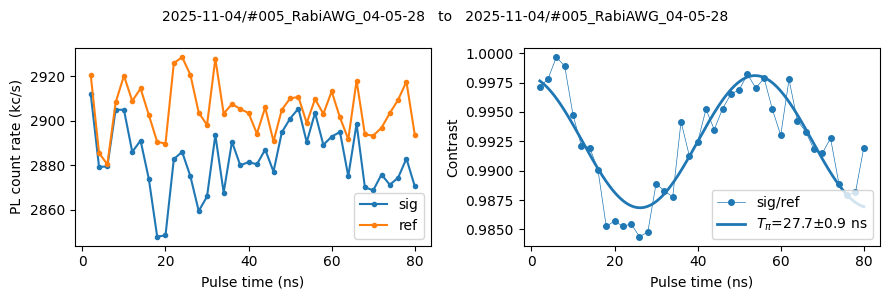

In [134]:
# Multiple
days = np.linspace(1,31,31); count=0; ifFit=1
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-11-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'RabiAWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = (day==4 and idx==5)
                if batch1:
                    datafile = mainFolder + dataFolder +'/RabiAWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = sig/ref
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = xPlot

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('Pulse time (ns)')

    axs[1].plot(x,ys/yr, 'o-',markersize=4, linewidth=0.5, label='sig/ref',)
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('Pulse time (ns)')
    
    s = firstdatafile[31:63] + '   to   ' + datafile[31:63]
    fig.suptitle(s,fontsize=10)

    if ifFit:
        guess = (0.015,30,0,0.985)
        xfit, yfit, popt, perr = dr.fitSinusoid(x, ys/yr, guess=guess)
        s = '$T_{\pi}$=%.1f$\pm$%.1f ns' % (popt[1], perr[1])
        axs[1].plot(xfit, yfit, '-', linewidth=2,color='C0',label=s)

    axs[1].legend(loc='lower right')
    plt.tight_layout()

# Pulsed ODMR

## Standard

(1, 30)


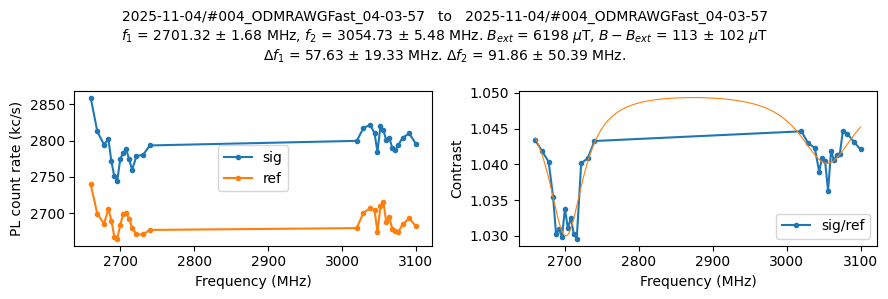

In [119]:
# Fast
days = np.linspace(1,31,31); count=0; ifFit=2; fm=2690e6; fp=3060e6; Bext=6198
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-11-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'ODMRAWGFast' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = (day==8 and idx>=117) or (day==9 and idx<=4)
                batch2 = (day==4 and idx==4)
                if batch2:
                    datafile = mainFolder + dataFolder +'/ODMRAWGFastObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    y = ys/yr
    x = xPlot/1e6

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('Frequency (MHz)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='sig/ref',)
    # axs[1].hlines(y=1, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].legend()
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('Frequency (MHz)')
    # axs[1].vlines(x=2870,ymin=min(y), ymax=max(y), linestyle='--', linewidth = 0.7, color='k')
    # axs[1].vlines(x=2789,ymin=min(y), ymax=max(y), linestyle='-', linewidth = 1, color='k')
    # axs[1].vlines(x=2951,ymin=min(y), ymax=max(y), linestyle='--', linewidth = 0.7, color='k')
    # axs[1].vlines(x=2983,ymin=min(y), ymax=max(y), linestyle='-', linewidth = 1, color='k')
    
    s = firstdatafile[31:67] + '   to   ' + datafile[31:67]
    fig.suptitle(s,fontsize=10)
    # axs[1].set_xlim((2630,2700))
    if ifFit==1:
        convfactor=(2*28)/1e3
        lowerBounds = (-np.inf,-np.inf,4.99,-np.inf)
        guess = (-1e-1, fm/1e6, 25, 1)
        xfit, yfit, popt, perr = dr.fitLor(x,y, guess=guess, lowerBounds=lowerBounds, upperBounds=None)
        s1 = '$f_1$ = %.2f $\pm$ %.2f MHz.    $\Delta f$ = %.2f $\pm$ %.2f MHz' % (popt[1], perr[1],popt[2], perr[2])
        axs[1].plot(xfit, yfit, linewidth=0.8)
        fig.suptitle(s + '\n' + s1, fontsize=10)
    elif ifFit==2:
        convfactor=(2*28)/1e3
        lowerBounds = (-np.inf,-np.inf,4.99,-np.inf,-np.inf,4.99,-np.inf)
        guess = (-1e-1, fm/1e6, 25, -1e-1, fp/1e6, 25, 1)
        xfit, yfit, popt, perr = dr.fitLorTwo(x,y, guess=guess, lowerBounds=lowerBounds, upperBounds=None)
        s1 = '$f_1$ = %.2f $\pm$ %.2f MHz, $f_2$ = %.2f $\pm$ %.2f MHz.' % (popt[1], perr[1], popt[4], perr[4])
        s2 = ' $B_{ext}$ = %.0f $\mu$T, $B - B_{ext}$ = %.0f $\pm$ %.0f $\mu$T' % (Bext, np.abs(popt[4]-popt[1])/convfactor-Bext, np.sqrt(perr[1]**2 + perr[4]**2)/convfactor)
        s3 = '$\Delta f_1$ = %.2f $\pm$ %.2f MHz. $\Delta f_2$ = %.2f $\pm$ %.2f MHz.' % (popt[2], perr[2], popt[5], perr[5])
        axs[1].plot(xfit, yfit, linewidth=0.8)
        fig.suptitle(s + '\n' + s1 + s2 + '\n' + s3, fontsize=10)

    plt.tight_layout()

In [ ]:
print(np.abs(popt[4]-popt[1])/convfactor)
print(np.abs(popt[4]+popt[1])/2)

2880+2880-2684-32

6411.978607758304
2877.454076957507


164

In [ ]:
# Slow
days = np.linspace(1,31,31); count=0
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-08-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'ODMRAWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = (day==7 and idx>=10 and idx<=11)
                if batch1:
                    datafile = mainFolder + dataFolder +'/ODMRAWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    y = ys/yr
    x = xPlot/1e6

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('Frequency (MHz)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='sig/ref',)
    axs[1].hlines(y=1, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].legend()
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('Frequency (MHz)')
    # axs[1].vlines(x=2870,ymin=min(y), ymax=max(y), linestyle='--', linewidth = 0.7, color='k')
    # axs[1].vlines(x=2789,ymin=min(y), ymax=max(y), linestyle='-', linewidth = 1, color='k')
    # axs[1].vlines(x=2951,ymin=min(y), ymax=max(y), linestyle='--', linewidth = 0.7, color='k')
    # axs[1].vlines(x=2983,ymin=min(y), ymax=max(y), linestyle='-', linewidth = 1, color='k')
    
    s = firstdatafile[31:63] + '   to   ' + datafile[31:63]
    fig.suptitle(s,fontsize=10)
    # axs[1].set_xlim((2910,2940))

    plt.tight_layout()

(1, 301)


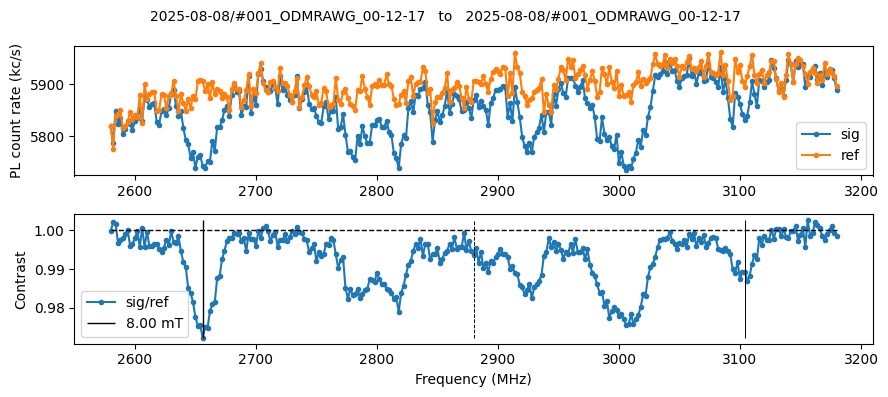

In [166]:
#Large field range
# Multiple
days = np.linspace(1,31,31); count=0
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-08-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'ODMRAWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = day==8 and idx==1
                if batch1:
                    datafile = mainFolder + dataFolder +'/ODMRAWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

f0 = 2880; a=224
if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    y = ys/yr
    x = xPlot/1e6

    fig,axs=plt.subplots(2,1,figsize=(9, 4))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='sig/ref',)
    axs[1].hlines(y=1, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('Frequency (MHz)')

    axs[1].vlines(x=f0,ymin=min(y), ymax=max(y), linestyle='--', linewidth = 0.7, color='k')
    s='%.2f mT' % (a/28)
    axs[1].vlines(x=f0-a,ymin=min(y), ymax=max(y), linestyle='-', linewidth = 1, color='k',label=s)
    axs[1].vlines(x=f0+a,ymin=min(y), ymax=max(y), linestyle='-', linewidth = 0.7, color='k')
    # axs[1].vlines(x=2983,ymin=min(y), ymax=max(y), linestyle='-', linewidth = 1, color='k')
    
    s = firstdatafile[31:63] + '   to   ' + datafile[31:63]
    fig.suptitle(s,fontsize=10)
    # axs[1].set_xlim((1800,2000))
    axs[1].legend()

    plt.tight_layout()

## Sweeping green delays

(13, 30)
ZFS [2874.05534471 2877.36348766 2876.28981505 2872.65378861 2877.87343994
 2882.20874735 2871.08881769 2864.19246208 2875.23731482 2876.00868846
 2876.91360718 2876.7061147  2873.87433148]


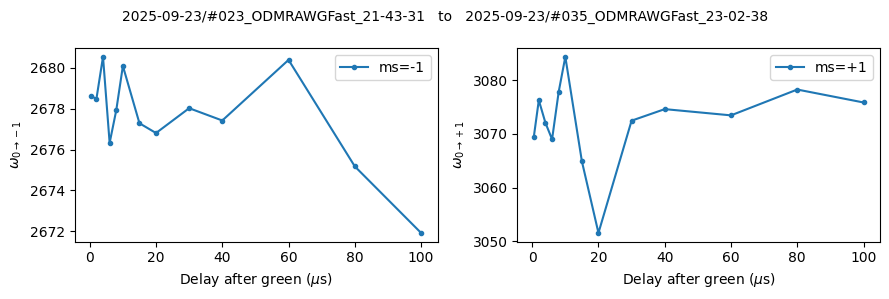

In [1922]:
# Fast
days = np.linspace(1,31,31); count=0; ifFit=1; fm=2676e6; fp=3069e6; Bext=7312
dataArr = []; sigArr = []; refArr = []; f1s = []; f2s=[]
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-09-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'ODMRAWGFast' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = (day==23 and idx>=23 and idx<=35)
                if batch1:
                    datafile = mainFolder + dataFolder +'/ODMRAWGFastObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
print(np.shape(dataArr))
for i, data in enumerate(dataArr):
    xPlot = np.array(xPlot); start=0; end=None
    ys = sigArr[i]
    yr = refArr[i]
    y = ys/yr
    x = xPlot/1e6

    if ifFit:
        convfactor=(2*28)/1e3
        lowerBounds = (-np.inf,-np.inf,4.99,-np.inf,-np.inf,4.99,-np.inf)
        guess = (-1e-1, fm/1e6, 25, -1e-1, fp/1e6, 25, 1)
        xfit, yfit, popt, perr = dr.fitLorTwo(x,y, guess=guess, lowerBounds=lowerBounds, upperBounds=None)
        s1 = '$f_1$ = %.2f $\pm$ %.2f MHz, $f_2$ = %.2f $\pm$ %.2f MHz.' % (popt[1], perr[1], popt[4], perr[4])
        s2 = ' $B_{ext}$ = %.0f $\mu$T, $B - B_{ext}$ = %.0f $\pm$ %.0f $\mu$T' % (Bext, np.abs(popt[4]-popt[1])/convfactor-Bext, np.sqrt(perr[1]**2 + perr[4]**2)/convfactor)
    f1s.append(popt[1]); f2s.append(popt[4])

if True:
    f1s = np.array(f1s); f2s = np.array(f2s)
    green_delays = np.array((5e2,2e3,4e3,6e3,8e3,10e3,15e3,20e3,30e3,40e3,60e3,80e3,100e3))
    x = green_delays[0:len(f1s)]/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,f1s, 'o-', markersize=3, label="ms=-1")
    axs[0].legend()
    axs[0].set_ylabel(r'$\omega_{0 \rightarrow -1}$')
    axs[0].set_xlabel('Delay after green ($\mu$s)')

    axs[1].plot(x,f2s, 'o-', markersize=3, label="ms=+1")
    axs[1].legend()
    axs[1].set_ylabel(r'$\omega_{0 \rightarrow +1}$')
    axs[1].set_xlabel('Delay after green ($\mu$s)')

    s = firstdatafile[31:67] + '   to   ' + datafile[31:67]
    fig.suptitle(s,fontsize=10)

    plt.tight_layout()
    print('ZFS', (f1s+f2s)/2)

# Confocal PL map

In [2317]:
datafile = 'C:/Users/lukin2dmaterials/data/2025-08-17/cfc_003_x-0.340.66_y-1.16-0.16_9.5K.npy'
cfc = np.load(datafile)
x_array = np.linspace(-0.2,0.8,101)
y_array = np.linspace(-0.9,0.1,101)

C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_11156\4235426014.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


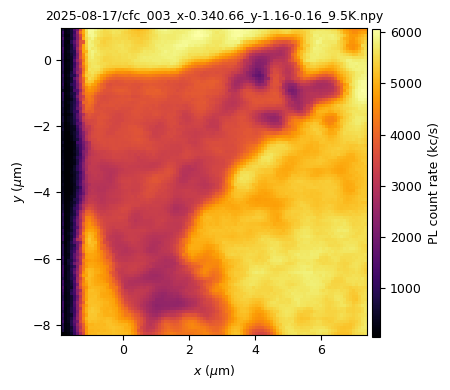

In [2318]:
fig, ax = plt.subplots(figsize=(4,4))
fontsize = 9; convfactor = 1e3/109
start = 0; end = None
X,Y = np.meshgrid(x_array[start:end]*convfactor, y_array[start:end]*convfactor)
im = ax.pcolormesh(X, Y, cfc[start:end,start:end], cmap='inferno')
# ax.vlines(x=-1.2,ymin=-2, ymax=2,linewidth=.3)
# ax.hlines(y=0,xmin=-2.5*10, xmax=2.5*10,linewidth=1,color='red')
ax.set_aspect(1)
# im.set_clim([0,4000])

# plt.xlabel('$V_{x}$, Volts', fontsize=fontsize)
# plt.ylabel('$V_{y}$, Volts', fontsize=fontsize)
plt.xlabel('$x$ ($\mu$m)', fontsize=fontsize)
plt.ylabel('$y$ ($\mu$m)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)

cax = fig.add_axes([ax.get_position().x1+0.06, ax.get_position().y0+0.036, 0.02,ax.get_position().height])
cbar = fig.colorbar(im, cax = cax)
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label('PL count rate (kc/s)', fontsize=fontsize)

s = datafile[31:]
ax.set_title(s,fontsize=fontsize);
plt.tight_layout()


# Confocal ODMR

## Each temperature

### Standard

In [135]:
dataArr = []; ifSingleGreenRead=1
month = 11; days = np.linspace(1,31,31); count=0
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-'+str(int(month)).zfill(2)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalODMRAWGFast'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = (day==13 and idx>=41)
                batch2 = (day==17 and idx>=15 and idx<=16)
                batch3 = (day==19 and idx==1)
                batch4 = (day==21 and idx>=13)
                batch5 = (day==5 and idx>=10)
                batch6 = (day==4 and idx==6)
                if batch6:  
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,freq,sig,ref = dr.readDataConfocalODMR(datafile, freqSplitFactor=1)
                    sig = np.array(sig); ref = np.array(ref); contrast = sig/ref
                    x = np.array(x); y = np.array(y)
                    (ny,nx,nfreq) = np.shape(sig)
                    dataArr.append(contrast)
                
                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
print(np.shape(dataArr))
dataArr = np.array(dataArr); dataArr = np.average(dataArr, axis=0)
Bext = 6413.08; ifMask=0
fm = (2880 - Bext/1000*28)*1e6; fp = (2880 + Bext/1000*28)*1e6
if False:
    print(np.shape(dataArr))
    dataArr[9,4,:]=(dataArr[9,3,:]+dataArr[9,5,:])/2
    dataArr[10,5,:]=(dataArr[10,4,:]+dataArr[10,6,:])/2
    # dataArr[2,0,:]=(dataArr[1,0,:]+dataArr[3,0,:])/2

(1, 5, 4, 30)


In [136]:
freqmins = -1e11*np.ones((ny,nx)); freqerrs = np.zeros((ny,nx))
fmArray = -1e11*np.ones((ny,nx)); fpArray = -1e11*np.ones((ny,nx))
convfactor = 2*0.028*1e6; conv_voltage=10; ifDifferential=1; errTolerance = np.inf
centers = -1e11*np.ones((ny,nx))

lowerBounds = (-np.inf,-np.inf,4.99e6,-np.inf,-np.inf,4.99e6,-np.inf)
lowerBounds2 = (-np.inf,-np.inf,4.99e6,-np.inf,2.91e9,4.99e6,-np.inf)
upperBounds2 = (0,2.84e9,np.inf,0,np.inf,np.inf,np.inf)

def doException():
    xfit = freq[j,i]; yfit = dataArr[j,i]
    popt = np.array((-1, -1,-1,-1,  1,-1,-1))*1e9
    perr = np.array((1e9,1e9,1e9,1e9,1e9,1e9,1e9))*1e3
    print("Cannot fit " + label)
    return xfit, yfit, popt, perr

In [137]:
# imarker = 200
# for j in range(ny):
#     for i in range(nx):
#         label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
#         # freqmin = freq[j,i,np.argmin(dataArr[j,i])]
#         # freqmins[j,i] = freqmin
#         if ifDifferential==0:
#             guess = (-1e5, freq[j,i,np.argmin(dataArr[j,i])], 10e6, 1); lowerBounds=None; upperBounds=None
#             xfit, yfit, popt, perr = dr.fitLor(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds)
#             freqmins[j,i] = popt[1]; freqerrs[j,i] = perr[1]
#         else:
#             if np.abs(freq[j,i][np.argmin(dataArr[j,i])]-2.88e9) < 30e6:
#                 try:
#                     guess = (-1e5, 2870e6, 15e6, -1e5, 2890e6, 15e6, 1)
#                     # if i==64: guess = (-1e5, 2810e6, 15e6, -1e5, 2950e6, 15e6, 1)
#                     xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=None)
#                 except Exception as e:
#                     try:
#                         guess = (-1e5, 2780e6, 25e6, -1e5, 2980e6, 25e6, 1)
#                         xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds2, upperBounds=upperBounds2)
#                     except Exception as e:
#                         xfit, yfit, popt, perr = doException()
#             else:
#                 try:
#                     guess = (-1e5, fm, 5e6, -1e5, fp, 5e6, 1)
#                     xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=None)
#                     if np.max((np.abs(popt[1]-2.88e9),np.abs(popt[4]-2.88e9))) > 60e6:
#                         try:
#                             guess = (-1e5, fm, 25e6, -1e5, fp, 25e6, 1)
#                             xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds2, upperBounds=upperBounds2)
#                         except Exception as e:
#                             xfit, yfit, popt, perr = doException()
#                 except Exception as e:
#                     xfit, yfit, popt, perr = doException()

#             err = np.abs(np.sum(perr/popt))
#             if err <= errTolerance:
#                 freqmins[j,i] = np.abs(popt[4]-popt[1]); freqerrs[j,i] = np.sqrt(perr[4]**2 + perr[1]**2)
#                 fmArray[j,i] = popt[1]
#                 fpArray[j,i] = popt[4]

In [138]:
# New fit
imarker = 200
for j in range(ny):
    for i in range(nx):
        label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
        # freqmin = freq[j,i,np.argmin(dataArr[j,i])]
        # freqmins[j,i] = freqmin
        if ifDifferential==0:
            guess = (-1e5, freq[j,i,np.argmin(dataArr[j,i])], 10e6, 1); lowerBounds=None; upperBounds=None
            xfit, yfit, popt, perr = dr.fitLor(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds)
            freqmins[j,i] = popt[1]; freqerrs[j,i] = perr[1]
        else:
            guesses = [
                # np.array((-1e5, 2870e6, 15e6, -1e5, 2890e6, 15e6, 1)),
                # np.array((-1e5, 2780e6, 25e6, -1e5, 2980e6, 25e6, 1)),
                np.array((-1e5, fm, 5e6, -1e5, fp, 5e6, 1)),
                np.array((-1e5, fm, 25e6, -1e5, fp, 25e6, 1))
            ]

            for guess in guesses:
                try:
                    xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds2)
                    break  # Stop if successful
                except Exception as e:
                    continue  # Try next guess
                xfit, yfit, popt, perr = doException()    

            err = np.abs(np.sum(perr/popt))
            if err <= errTolerance:
                freqmins[j,i] = np.abs(popt[4]-popt[1]); freqerrs[j,i] = np.sqrt(perr[4]**2 + perr[1]**2)
                centers[j,i] = np.abs(popt[4]+popt[1])/2
                fmArray[j,i] = popt[1]
                fpArray[j,i] = popt[4]

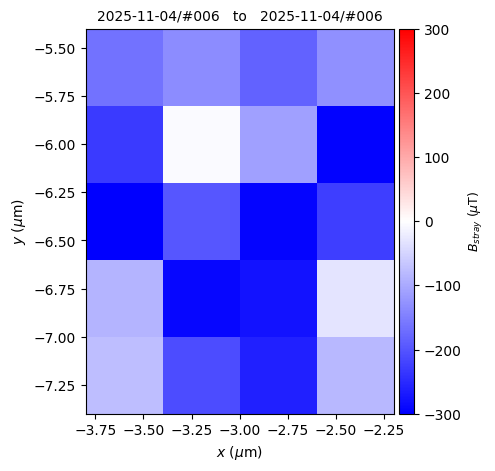

In [139]:
# 2D       
X = x[:,:,0]*conv_voltage; Y = y[:,:,0]*conv_voltage
fig, ax = plt.subplots(figsize=(5,5))
if ifDifferential==0:
    #####   Single resonance, f- or f+   #########
    plot = ax.pcolormesh(X,Y, (freqmins- np.average(freqmins))/convfactor, cmap='bwr') #
else:
    #####   Differential, single scan that has both f- and f+   #########
    meanDeltaf = Bext*convfactor #1431 #81948173.46995163#np.average(freqmins[rowidx])
    dataPlot = (freqmins - meanDeltaf)/convfactor
    dataErrPlot = freqerrs/convfactor
    plot = ax.pcolormesh(X,Y, dataPlot, cmap='bwr');
    
ax.set_aspect(1)
divider = make_axes_locatable(ax)
cbar_ax = divider.append_axes("right", size="5%", pad=0.05)
cb1 = fig.colorbar(plot, orientation='vertical', ax=ax,cax=cbar_ax)
cb1.set_label('$B_{stray}$ ($\mu$T)', fontsize=9)

a = 300
plot.set_clim(-a,a)

ax.set_xlabel('$V_x$ (V)')
ax.set_ylabel('$V_y$ (V)')

ax.set_xlabel('$x$ ($\mu$m)')
ax.set_ylabel('$y$ ($\mu$m)')

######################### Mask ######################################
# mask0 = dataPlot<-50
# mask1 = Y>-4; mask2 = X<3; mask3 = Y>-2
# mask4 = X>=0.4; mask5 = X<=2.4
# mask6 = X==-0.4; mask7 = Y>=-4.4; mask8 = X>2.7; mask9=X<3
# mask = mask0 | (mask1 & mask2) | mask3 | (mask4 & mask5) | (mask6 & mask7) | (mask8 & mask9 & mask7)
# shifted = mask

if False:
    zero_col = np.ones((shifted.shape[0], 1), dtype=shifted.dtype)
    diff_num_x = dataPlot.shape[1]-shifted.shape[1]
    for iii in range(diff_num_x):
        shifted = np.hstack((shifted, zero_col)) # Add it to the right

    zero_row = np.ones((dataPlot.shape[1], 1), dtype=shifted.dtype)
    zero_row = zero_row.T
    diff_num_y = dataPlot.shape[0]-shifted.shape[0]
    for iii in range(diff_num_y):
        shifted = np.vstack((shifted, zero_row)) # Add it to the top

    shifted = shifted | ~(dataPlot<-50)

if False:
    shifted = np.zeros_like(mask)          # or np.full_like(arr, np.nan)
    shifted[:, 1:] = mask[:, :-1]
    shifted[:,0] = np.array([True, True, True, True, True, True, True, True, False,
           False, False, False, False, False, False, False, False, False,
           True, True, True])
    shifted[0,3]=shifted[1,3]=shifted[0,9]= shifted[6,1]=False

    zero_col = np.ones((shifted.shape[0], 1), dtype=shifted.dtype)
    shifted = np.hstack((zero_col, shifted)) # Add it to the left

    diff_num_x = dataPlot.shape[1]-shifted.shape[1]
    for iii in range(diff_num_x):
        shifted = np.hstack((shifted, zero_col)) # Add it to the right

    # shifted[-1] = True; shifted[3,10] = shifted[4,10] = shifted[2,11]=shifted[1,11]=True
    shifted[:,-3] = np.array([True, True, True, True, True, True, True, True, True,
           True, True, True, True, False, False, False, False, False,
           False, False, True])
    shifted[:,0] = np.array([True, True, True, True, True, True, True, True, True,
           True, False, False, False, False, False, False, True, True,
           True, True, True])
    shifted[:,-3] = True
    shifted[0:5,3] = False

# shifted_100_14K = dataPlot<-100
# shifted = ~shifted_100_14K
##############################################################################

sp = 0.005*conv_voltage
if ifMask==1:
    for (j,i), val in np.ndenumerate(~shifted):
        if val: 
            ax.add_patch(plt.Rectangle((X[0][i]-sp/2, Y[j][0]-sp/2), sp, sp, color='black'))

s = firstdatafile[31:46] + '   to   ' + datafile[31:46]
ax.set_title(s,fontsize=10)

# ax.set_xlim(-0.2,4.2)
# ax.set_ylim(-6.2,-1.8)

plt.tight_layout;

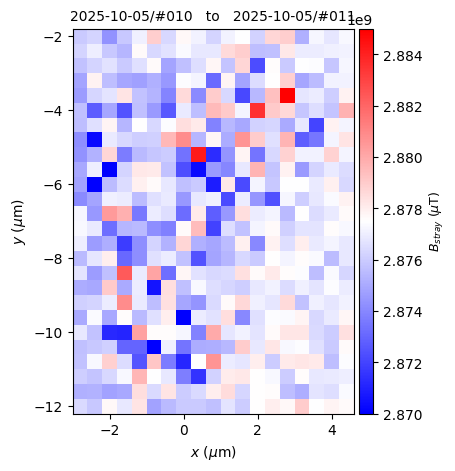

In [594]:
# 2D       
X = x[:,:,0]*conv_voltage; Y = y[:,:,0]*conv_voltage
fig, ax = plt.subplots(figsize=(5,5))
if ifDifferential==0:
    #####   Single resonance, f- or f+   #########
    plot = ax.pcolormesh(X,Y, (freqmins- np.average(freqmins))/convfactor, cmap='bwr') #
else:
    #####   Differential, single scan that has both f- and f+   #########
    meanDeltaf = Bext*convfactor #1431 #81948173.46995163#np.average(freqmins[rowidx])
    dataPlot = (freqmins - meanDeltaf)/convfactor
    dataErrPlot = freqerrs/convfactor
    plot = ax.pcolormesh(X,Y, centers, cmap='bwr');
    
ax.set_aspect(1)
divider = make_axes_locatable(ax)
cbar_ax = divider.append_axes("right", size="5%", pad=0.05)
cb1 = fig.colorbar(plot, orientation='vertical', ax=ax,cax=cbar_ax)
cb1.set_label('$B_{stray}$ ($\mu$T)', fontsize=9)

a = 300
plot.set_clim(2870e6,2885e6)

ax.set_xlabel('$V_x$ (V)')
ax.set_ylabel('$V_y$ (V)')

ax.set_xlabel('$x$ ($\mu$m)')
ax.set_ylabel('$y$ ($\mu$m)')

######################### Mask ######################################
# mask0 = dataPlot<-50
# mask1 = Y>-4; mask2 = X<3; mask3 = Y>-2
# mask4 = X>=0.4; mask5 = X<=2.4
# mask6 = X==-0.4; mask7 = Y>=-4.4; mask8 = X>2.7; mask9=X<3
# mask = mask0 | (mask1 & mask2) | mask3 | (mask4 & mask5) | (mask6 & mask7) | (mask8 & mask9 & mask7)
# shifted = mask

if False:
    zero_col = np.ones((shifted.shape[0], 1), dtype=shifted.dtype)
    diff_num_x = dataPlot.shape[1]-shifted.shape[1]
    for iii in range(diff_num_x):
        shifted = np.hstack((shifted, zero_col)) # Add it to the right

    zero_row = np.ones((dataPlot.shape[1], 1), dtype=shifted.dtype)
    zero_row = zero_row.T
    diff_num_y = dataPlot.shape[0]-shifted.shape[0]
    for iii in range(diff_num_y):
        shifted = np.vstack((shifted, zero_row)) # Add it to the top

    shifted = shifted | ~(dataPlot<-50)

if True:
    shifted = np.zeros_like(mask)          # or np.full_like(arr, np.nan)
    shifted[:, 1:] = mask[:, :-1]
    shifted[:,0] = np.array([True, True, True, True, True, True, True, True, False,
           False, False, False, False, False, False, False, False, False,
           True, True, True])
    shifted[0,3]=shifted[1,3]=shifted[0,9]= shifted[6,1]=False

    zero_col = np.ones((shifted.shape[0], 1), dtype=shifted.dtype)
    shifted = np.hstack((zero_col, shifted)) # Add it to the left

    diff_num_x = dataPlot.shape[1]-shifted.shape[1]
    for iii in range(diff_num_x):
        shifted = np.hstack((shifted, zero_col)) # Add it to the right

    # shifted[-1] = True; shifted[3,10] = shifted[4,10] = shifted[2,11]=shifted[1,11]=True
    shifted[:,-3] = np.array([True, True, True, True, True, True, True, True, True,
           True, True, True, True, False, False, False, False, False,
           False, False, True])
    shifted[:,0] = np.array([True, True, True, True, True, True, True, True, True,
           True, False, False, False, False, False, False, True, True,
           True, True, True])
    shifted[:,-3] = True
    shifted[0:5,3] = False

# shifted_100_14K = dataPlot<-100
# shifted = ~shifted_100_14K
##############################################################################

sp = 0.005*conv_voltage
if ifMask==1:
    for (j,i), val in np.ndenumerate(~shifted):
        if val: 
            ax.add_patch(plt.Rectangle((X[0][i]-sp/2, Y[j][0]-sp/2), sp, sp, color='black'))

s = firstdatafile[31:46] + '   to   ' + datafile[31:46]
ax.set_title(s,fontsize=10)

# ax.set_xlim(-0.2,4.2)
# ax.set_ylim(-6.2,-1.8)

plt.tight_layout;

In [ ]:
meanB = np.mean(dataPlot[~shifted])
meanBErr = np.mean(dataErrPlot[~shifted])
print('Mean B = %.1f uT' % meanB)
print('Mean B err = %.1f uT' % meanBErr)

weights = 1/dataErrPlot[~shifted]**2
meanB_weighted = np.sum(dataPlot[~shifted]*weights)/np.sum(weights)
meanBErr_weighted = np.sqrt(1/np.sum(weights))
print('Mean B weighted = %.1f uT' % meanB_weighted)
print('Mean B err weighted = %.1f uT' % meanBErr_weighted)

In [632]:
dataPlot[2]
print(np.average(np.concatenate((dataPlot[2:7,13:], dataPlot[0:5,0:2]),axis=1)))
# print(np.average(dataPlot[2:7,11:15]))

0.00374415792205518


In [140]:
x_1D = np.round(x[0,:,0],2); y_1D = np.round(y[:,0,0],2)
MWfreqDict = {}; MWfreqDictPlus = {}
for j in range(ny):
    for i in range(nx):
        MWfreqDict[(x_1D[i],y_1D[j])] = fmArray[j,i]
        MWfreqDictPlus[(x_1D[i],y_1D[j])] = fpArray[j,i]

for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-'+str(int(month)).zfill(2)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            idx = int(dataFolder[1:4])
            batch1 = (day==9 and idx==34)
            batch2 = (day==17 and idx>=1)
            batch3 = (day==18 and idx==8)
            batch4 = (day==19 and idx==5)
            batch5 = (day==20 and idx==30)
            batch6 = (day==5 and idx==10)
            batch7 = (day==4 and idx==6)
            if batch7:  
                savedDictFile = mainFolder + dataFolder + '/MWfreqDict_27K.pkl'
                savedDictFilePlus = mainFolder + dataFolder + '/MWfreqDictPlus_27K.pkl'
    except:pass

with open(savedDictFile, 'wb') as f:
    pickle.dump(MWfreqDict, f)
with open(savedDictFilePlus, 'wb') as f:
    pickle.dump(MWfreqDictPlus, f)


### Misc

In [1897]:
with open(savedDictFile, 'rb') as f:
    loaded_dict = pickle.load(f)
prev = None
for key, value in loaded_dict.items():
    if value >= 0:
        prev = value
    else:
        if prev is not None:
            loaded_dict[key] = prev  # Replace with last non-negative value

with open(savedDictFilePlus, 'rb') as f:
    loaded_dictPlus = pickle.load(f)
prev = None
for key, value in loaded_dictPlus.items():
    if value >= 0:
        prev = value
    else:
        if prev is not None:
            loaded_dictPlus[key] = prev  # Replace with last non-negative value

In [1898]:
loaded_dict

{(-0.2, -1.08): 2671880763.071541,
 (-0.16, -1.08): 2670824623.7865663,
 (-0.12, -1.08): 2671903622.679478,
 (-0.08, -1.08): 2672281205.1032467,
 (-0.04, -1.08): 2675455820.322982,
 (-0.0, -1.08): 2673191551.107912,
 (0.04, -1.08): 2675246171.528666,
 (0.08, -1.08): 2673384095.4400525,
 (0.12, -1.08): 2677106692.3880424,
 (0.16, -1.08): 2674091857.6775837,
 (0.2, -1.08): 2674087459.763436,
 (0.24, -1.08): 2672448812.2295704,
 (0.28, -1.08): 2671494826.86769,
 (0.32, -1.08): 2671525329.664206,
 (0.36, -1.08): 2672589291.913358,
 (0.4, -1.08): 2673593039.9495726,
 (0.44, -1.08): 2673067979.296896,
 (0.48, -1.08): 2672187671.8080897,
 (-0.2, -1.04): 2671088634.4295316,
 (-0.16, -1.04): 2671806415.614697,
 (-0.12, -1.04): 2672151400.967133,
 (-0.08, -1.04): 2672363733.5825753,
 (-0.04, -1.04): 2673660061.18172,
 (-0.0, -1.04): 2676058804.247179,
 (0.04, -1.04): 2673988964.8204823,
 (0.08, -1.04): 2675194230.9695873,
 (0.12, -1.04): 2676387578.034977,
 (0.16, -1.04): 2676767594.4028435,
 (0

In [189]:
MWfreqPlus = 3062908923.461420; MWfreq = 2685212878.430487; BExt = Bext
MWfreqPlus = 3068624812.972110; MWfreq = 2683651590.5011373; BExt = Bext
((MWfreqPlus-MWfreq)/1e3) / (2*28) - BExt


-73.47817016120553

Cannot fit x = 0.240, y = -0.360
Cannot fit x = 0.120, y = -0.320


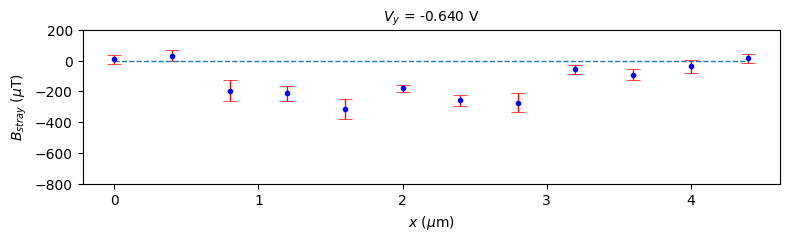

In [113]:
rowidx = 1 # 1D
for j in range(ny):
    for i in range(nx):
        label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
        # freqmin = freq[j,i,np.argmin(dataArr[j,i])]
        # freqmins[j,i] = freqmin
        
        if ifDifferential==0:
            guess = (-1e5, freq[j,i,np.argmin(dataArr[j,i])], 10e6, 1)
            xfit, yfit, popt, perr = dr.fitLor(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=None, upperBounds=None)
            freqmins[j,i] = popt[1]; freqerrs[j,i] = perr[1]
        else:
            if np.abs(freq[j,i][np.argmin(dataArr[j,i])]-2.88e9) < 30e6:
                try:
                    guess = (-1e5, fm, 15e6, -1e5, fp, 15e6, 1)
                    if i==64: guess = (-1e5, 2810e6, 15e6, -1e5, 2950e6, 15e6, 1)
                    xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=None)
                except Exception as e:
                    try:
                        guess = (-1e5, fm, 25e6, -1e5, fp, 25e6, 1)
                        xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds2, upperBounds=upperBounds2)
                    except Exception as e:
                        xfit, yfit, popt, perr = doException()
            else:
                try:
                    guess = (-1e5, fm, 5e6, -1e5, fp, 5e6, 1)
                    xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=None)
                    if np.max((np.abs(popt[1]-2.88e9),np.abs(popt[4]-2.88e9))) > 60e6:
                        try:
                            guess = (-1e5, fm, 25e6, -1e5, fp, 25e6, 1)
                            xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds2, upperBounds=upperBounds2)
                        except Exception as e:
                            xfit, yfit, popt, perr = doException()
                except Exception as e:
                    xfit, yfit, popt, perr = doException()

            err = np.abs(np.sum(perr/popt))
            if err <= errTolerance:
                freqmins[j,i] = np.abs(popt[4]-popt[1]); freqerrs[j,i] = np.sqrt(perr[4]**2 + perr[1]**2)
        

fig, ax = plt.subplots(figsize=(9,2))

if ifDifferential==0:
    #####   Single resonance, f- or f+   #########
    plot = ax.errorbar(x[:,:,0][rowidx]*10, (freqmins[rowidx] - mid)/convfactor, freqerrs[rowidx]/convfactor,
                    fmt='o', color='blue', markersize=3, capsize=5, capthick=0.5, ecolor='red', elinewidth=1);
else:
   #####   Differential, single scan that has both f- and f+   #########
    xplot = x[:,:,0][rowidx]*10
    meanDeltaf = Bext*convfactor
    yplot = (freqmins[rowidx] - meanDeltaf)/convfactor; yerr = (freqerrs[rowidx])/convfactor
    plot = ax.errorbar(xplot, yplot-0*Bext, yerr,
                    fmt='o', color='blue', markersize=3, capsize=5, capthick=0.5, ecolor='red', elinewidth=1);
    # a = 58; b = None
    # plot = ax.errorbar(xplot[a:b], -yplot[a:b]-1*1439, yerr[a:b],
    #                     fmt='o', color='green', markersize=3, capsize=5, capthick=0.5, ecolor='red', elinewidth=1);
    # # plot = ax.errorbar(xplotOld , yplotOld, yerrOld,
    #                     fmt='o', color='blue', markersize=3, capsize=5, capthick=0.5, ecolor='red', elinewidth=1);
    
ax.set_xlabel('$V_x$ (V)'); ax.set_xlabel('$x$ ($\mu$m)')
ax.set_ylabel('$f_{NV}$ (MHz)'); ax.set_ylabel('$B_{stray}$ ($\mu$T)')
ax.set_ylim((-800,200))
ax.hlines(y=0,xmin=min(xplot),xmax=max(xplot),linewidth=1, linestyle='--')
ax.set_title('$V_y$ = %.3f V' % y[:,:,0][rowidx][0], fontsize=10)

plt.tight_layout;

In [ ]:
# fig, ax = plt.subplots(figsize=(4,7)); scaleForShift = 0.01
# for j in range(ny):
#     for i in range(nx):
#         rawplot, = ax.plot(freq[j,i], dataArr[j,i] + scaleForShift*(j*nx+i), '-o',markersize=3, linewidth=0.8, label='x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0]))
#         # guess = (-1e5, freq[j,i,np.argmin(dataArr[j,i])], 5e6, 1); lowerBounds=None; upperBounds=None
#         # xfit, yfit, popt, perr = dr.fitLor(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds)
#         guess = (-1e5, fm, 5e6, -1e5, fp, 5e6, 1); lowerBounds=None; upperBounds=None
#         # xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds)
#         # ax.plot(xfit, yfit + scaleForShift*(j*nx+i), color=rawplot.get_color(),linewidth=2)

# ax.legend(fontsize=6,loc='upper left', bbox_to_anchor=(1, 1));

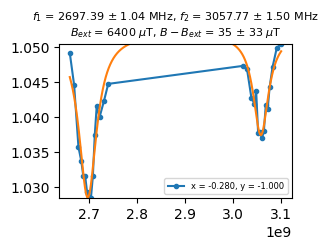

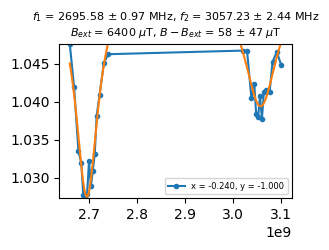

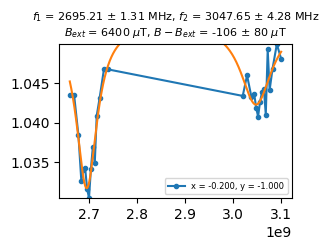

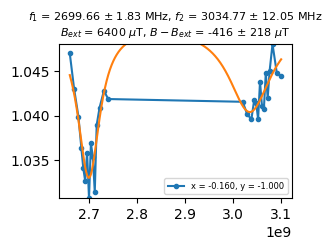

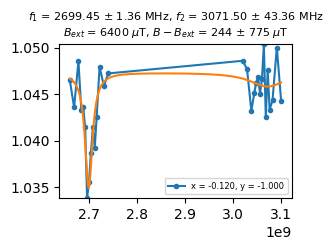

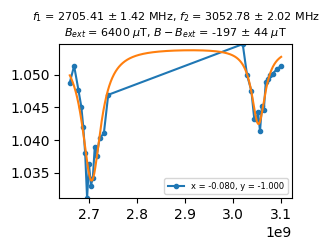

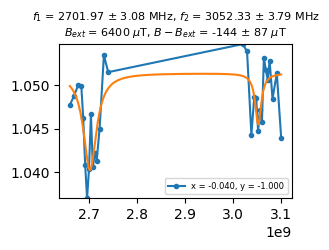

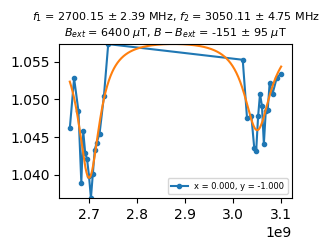

In [569]:
j = 5; i = 7; idxArray = np.linspace(0,i,i+1)
for i in idxArray:
    i = int(i)
    fig, ax = plt.subplots(figsize=(3,2))
    label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
    ax.plot(freq[j,i], dataArr[j,i], 'o-',markersize=3,  label=label)
    ax.legend(fontsize=6)#,loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_ylim(np.min(dataArr[j,i]), np.max(dataArr[j,i]))
    if ifDifferential==0:
        guess = (-1e5, freq[j,i,np.argmin(dataArr[j,i])], 10e6, 1); lowerBounds=None; upperBounds=None
        xfit, yfit, popt, perr = dr.fitLor(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds)
        freqmins[j,i] = popt[1]; freqerrs[j,i] = perr[1]
    else:
        guesses = [
            # np.array((-1e5, 2870e6, 15e6, -1e5, 2890e6, 15e6, 1)),
            # np.array((-1e5, 2780e6, 25e6, -1e5, 2980e6, 25e6, 1)),
            np.array((-1e5, fm, 5e6, -1e5, fp, 5e6, 1)),
            np.array((-1e5, fm, 25e6, -1e5, fp, 25e6, 1))
        ]

        for guess in guesses:
            try:
                xfit, yfit, popt, perr = dr.fitLorTwo(freq[j,i], dataArr[j,i], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds2)
                ax.plot(xfit,yfit)
                break  # Stop if successful
            except Exception as e:
                continue  # Try next guess
            xfit, yfit, popt, perr = doException()    

        err = np.abs(np.sum(perr/popt))
        
    s1 = '$f_1$ = %.2f $\pm$ %.2f MHz, $f_2$ = %.2f $\pm$ %.2f MHz' % (popt[1]/1e6, perr[1]/1e6, popt[4]/1e6, perr[4]/1e6)
    s2 = '$B_{ext}$ = %.0f $\mu$T, $B - B_{ext}$ = %.0f $\pm$ %.0f $\mu$T' % (Bext, np.abs(popt[4]-popt[1])/convfactor-Bext, np.sqrt(perr[1]**2 + perr[4]**2)/convfactor)
    ax.set_title( s1 + '\n' + s2, fontsize=8);

## Temp sweep

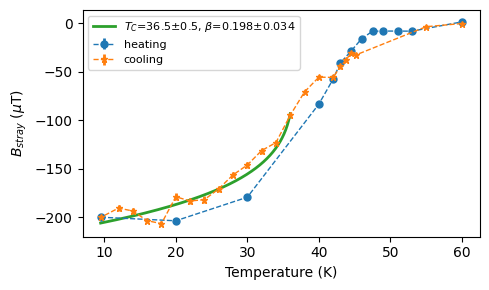

In [76]:
temp = np.array((9.5,  20,   30,   40,  42,  43,  44.5,46,  47.5,49, 51, 53, 60))
B    = np.array((199.8,203.5,179.2,83.2,57.4,40.8,28.6,15.6,8.1, 7.9,7.9,8,  -1.6))*(-1)
BErr = np.array((2.6,  3.1,  3.2,  1.9, 1.6, 1.7, 1.7, 1.9, 1.7, 1.8,1.6,1.8,1.6 ))


temp_down = np.array((60, 55, 45.25,44.5,43.75,43,  42,  40,  38,  36,  34,   32,   30, 28,   26,   24,   22,   20,   18,   16,   14,   12,   9.5))
B_down    = np.array((0.1,3.4,32.3, 30.5,38.1, 44.4,55.7,55.4,70.6,94.7,122.9,131.1,146,156.2,170.6,181.7,183.1,178.7,206.4,203.4,193.4,190.4,200))*(-1)
BErr_down = np.array((1.5,1.7,2.1,  2.1, 2.1,  2.1, 2.4, 2.1, 2.2, 2.6, 2.6,  3.1,  3.1,2.6,  3.2,  3.3,  3.4,  3.4,  2.9,  2.7,  2.6,  2.8,  2.8 ))

x = np.concatenate((temp,temp_down))
y = np.concatenate((B, B_down))
yerr = np.concatenate((BErr,BErr_down))

idx = np.argsort(x)
x = x[idx]; y = y[idx]; yerr = yerr[idx]

fig,ax=plt.subplots(figsize=(5,3))
ax.errorbar(temp,B,BErr,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="heating")
ax.errorbar(temp_down,B_down,BErr_down,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="cooling")
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$B_{stray}$ ($\mu$T)')

if True:
    guess = (-215,  36,  0.18); xfit = np.linspace(x[0],x[-1],1001)
    lowerBounds=np.array((-np.inf,0,0))
    upperBounds=np.array((0,100,5))
    xfit, yfit, popt, perr = dr.fitMvsT(x[0:17], y[0:17], guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds)
    
    s = r'$T_C$=%.1f$\pm$%.1f, $\beta$=%.3f$\pm$%.3f' % (popt[1],perr[1],popt[2],perr[2])
    ax.plot(xfit, yfit, '-', linewidth=2,color='C2',label=s)
    # s = r'$T_C$=%.0f, $\beta$=%.3f' % (guess[1],guess[2])
    # ax.plot(xfit, dr.MvsT(xfit,*guess), '-', linewidth=2,color='C2',label=s)


ax.legend(fontsize=8,loc='upper left')
plt.tight_layout()

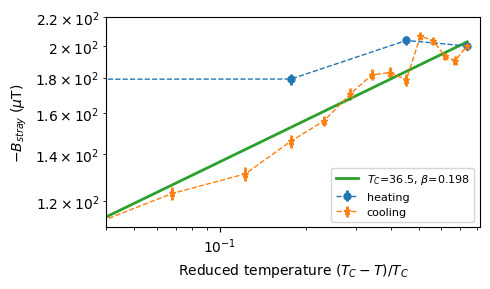

In [80]:
fig,ax=plt.subplots(figsize=(5,3)); Tc=popt[1] #36
eps = (Tc-temp)/Tc; eps_down = (Tc-temp_down)/Tc
ax.errorbar(eps,-B,BErr,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="heating")
ax.errorbar(eps_down,-B_down,BErr_down,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="cooling")
ax.set_xlabel('Reduced temperature $(T_C-T)$/$T_C$')
ax.set_ylabel('$-B_{stray}$ ($\mu$T)')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim((0.04,0.82))
ax.set_ylim((110,220))
if True:
    guess = (-215,  Tc, popt[2]); 
    xfit = np.linspace(x[0],x[-1],1001); epsfit = (Tc-xfit)/Tc
    lowerBounds=np.array((-np.inf,0,0))
    upperBounds=np.array((0,100,5))
    # xfit, yfit, popt, perr = dr.fitMvsT(x, y, guess=guess, lowerBounds=lowerBounds, upperBounds=upperBounds)
    
    # s = '$T_{2E}$=%.0f$\pm$%.0f ns' % (popt[2]*1e3, perr[2]*1e3)
    # ax.plot(xfit, yfit, '-', linewidth=2,color='C1',label=None)
    s = r'$T_C$=%.1f, $\beta$=%.3f' % (Tc,guess[2])
    ax.plot(epsfit, -dr.MvsT(xfit,*guess), '-', linewidth=2,color='C2',label=s)


ax.legend(fontsize=8,loc='lower right')
plt.tight_layout()

# T2E

(1, 51)


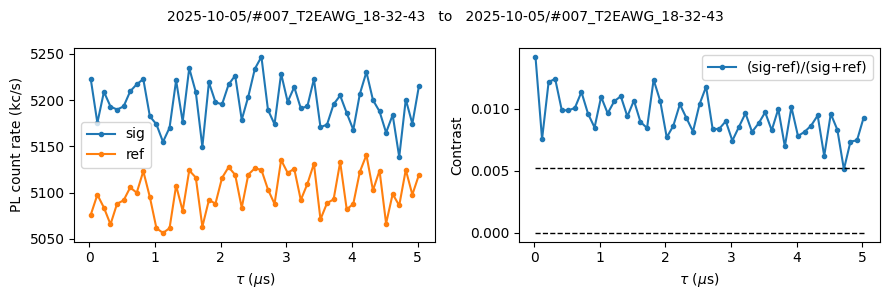

In [540]:
# Multiple
days = np.linspace(1,31,31); count=0; ifLog=0; ifFit=0
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-10-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'T2EAWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = day==3 and idx>=-15 and idx<=19
                batch2 = day==17 and idx>=10 and idx<=17
                batch3 = day==5 and idx==7
                if batch3:
                    datafile = mainFolder + dataFolder +'/T2EAWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = xPlot/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    axs[1].hlines(y=0, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=np.max(y)/np.e, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau$ ($\mu$s)')
    # axs[1].set_xlim((0,10))
    
    s = firstdatafile[31:62] + '   to   ' + datafile[31:62]
    fig.suptitle(s,fontsize=10)

    if ifFit:
        guess = (0.008,  0,  0.08,  1)
        lowerBounds=np.array((0, -1, 0.05, 1))
        # lowerBounds=np.array((0, -1, 50, 0))
        # lowerBounds=None
        xfit, yfit, popt, perr = dr.fitStrDecay(x, y, guess=guess, logx=1,lowerBounds=lowerBounds)
        # print(popt)
        # s = '$T_{2E}$=%.1f$\pm$%.1f $\mu$s' % (popt[2], perr[2])
        s = '$T_{2E}$=%.0f$\pm$%.0f ns' % (popt[2]*1e3, perr[2]*1e3)
        axs[1].plot(xfit, yfit, '-', linewidth=2,color='C1',label=s)
        print(popt[3])
        # guess = (0.015,  0,  5)
        # xfit, yfit, popt, perr = dr.fitDecay(x, y, guess=guess, logx=1)
        # print(popt)
        # s = '$T_{2E}$=%.1f$\pm$%.1f ns' % (popt[2], perr[2])
        # axs[1].plot(xfit, yfit, '-', linewidth=2,color='C0',label=s)

    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    plt.tight_layout()

(6, 13)
1.1971341633722


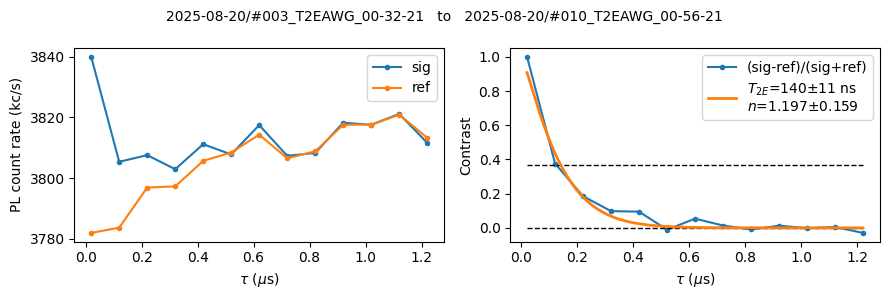

In [ ]:
# Scaled and fit to exp(-t/T2)^n
days = np.linspace(1,31,31); count=0; ifLog=0; ifFit=1
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-08-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'XY8AWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = day==20 and idx>=3 and idx<=10
                batch2 = (day==26 and idx>=37 and idx<=38) or (day==27 and (idx==1 or idx==3))
                batch3 = (day==28 and idx>=12 and idx<=13)
                if batch1:
                    datafile = mainFolder + dataFolder +'/T2EAWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    y = y/ np.max(y)
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = xPlot/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    axs[1].hlines(y=0, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=np.max(y)/np.e, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau$ ($\mu$s)')
    # axs[1].set_xlim((0,10))
    
    s = firstdatafile[31:62] + '   to   ' + datafile[31:62]
    fig.suptitle(s,fontsize=10)

    if ifFit:
        guess = np.array((250, 0.5))
        lowerBounds=None
        upperBounds=None
        xfit, yfit, popt, perr = dr.fitStrDecayNorm(x, y, guess=guess, logx=1,lowerBounds=lowerBounds)
        
        s = '$T_{2E}$=%.0f$\pm$%.0f ns' % (popt[0]*1e3, perr[0]*1e3)
        s1 = '$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])
        axs[1].plot(xfit, yfit, '-', linewidth=2,color='C1',label=s+'\n'+s1)
        print(popt[1])
       

    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    plt.tight_layout()

# Confocal T2E

## Each temperature

In [154]:
dataArr = []; ifSingleGreenRead=1
month = 11; days = np.linspace(1,31,31); count=0; ifYCountDown=0
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-'+str(int(month)).zfill(2)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalT2E'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                if True:
                    batch1a = (day==10 and idx==9)
                    batch1b = (day==10 and idx==12)
                    batch1c = (day==11 and idx>=4 and idx<=5)
                    batch2 = (day==11 and idx==6) # base, big data
                    batch2b = (day==11 and idx==8) # base, off flake
                    batch3 = (day==18 and idx==1) # 20 K
                    batch4 = (day==18 and idx==22) # 30 K
                    batch5 = (day==19 and idx==24) # 40 K
                    #############################################
                    batch6 = (day==20 and idx>=40) # 43 K, start to do 3x3 grid from here
                    batch7 = (day==21 and idx<=17) # 44.5 K
                    batch8 = (day==21 and idx>=34 and idx<=35) # 46 K
                    batch9 = (day==22 and idx<=18) # 47.5 K
                    batch10a = (day==23 and idx<=2) # 49 K
                    batch10b = (day==23 and idx>=4 and idx<=7) # 49 K off flake
                    batch11a = (day==23 and idx>=8 and idx<=222) # 51K
                    batch11b = (day==24 and idx<=5) # 51K off flake
                    batch12 = (day==25 and idx<=3) # 53K on flake
                    batch13 = (day==26 and idx<=12) # 55K on flake
                    batch14 = (day==26 and idx>=13 and idx<=32) #57.5K on flake
                    batch14b = (day==26 and idx>=33 and idx<=332) #57.5K on flake again
                    batch15 = (day==27 and idx==18) # 60 K
                    batch16 = (day==28 and idx==11) # 65 K
                    batch17 = (day==30 and idx<=6) # 120K
                if True:
                    batch18 = (day==30 and idx==20) # 60 K
                    batch18b = (day==31 and idx==8) # 60 K off flake
                    batch19 = (day==31 and idx==19) # 55K
                    batch19b = (day==1 and idx==2) #55K off flake
                    batch20 = (day==1 and idx==19) # 51K
                    batch21 = (day==2 and idx==11) # 48.75K
                    batch22 = (day==2 and idx>=30 and idx<=31) # 46.75K
                    batch23 = (day==3 and idx==24) # 45.25K
                    batch23b = (day==4 and idx<=5) # 45.25K off flake
                    batch24 = (day==5 and idx==1) # 44.5 K
                    batch24b = (day==4 and idx>=17 and idx<=18) # 44.5 K off flake
                    batch25 = (day==5 and idx==15) # 43.75K
                    batch25b = (day==5 and idx>=18) # 43.75 K off flake
                    batch26 = (day==6 and idx<=2) # 43K
                    batch26b = (day==6 and idx>=5 and idx<=6) # 43K off flake
                    batch27 = (day==6 and idx>=7 and idx <=15) # 42.5 K
                    batch28 = (day==6 and idx>=29) # 42 K
                    batch28b = (day==7 and idx<=2) # 42 K off flake
                    batch29 = (day==7 and idx>=15 and idx<=16) # 41.5K
                    batch30 = (day==7 and idx>=32) # 41K
                    batch31 = (day==8 and idx>=13 and idx<=14) # 40 K
                    batch31b = (day==8 and idx>=18 and idx<=19) # 40 K off flake
                    batch32 = (day==8 and idx>=31) #39 K
                    batch33 = (day==9 and idx<=15) #38 K
                    batch34 = (day==9 and idx>=29 and idx<=30) # 37K
                    batch35 = (day==10 and idx<=12) # 36K
                    batch35b = (day==10 and idx==23) # 36K off flake
                    batch36 = (day==11 and idx<=15) # 35K
                    batch37 = (day==11 and idx>=26 and idx<=27) # 34K
                    batch38 = (day==11 and idx>=41 and idx<=42) # 33K
                    batch39 = (day==12 and idx<=2) # 32K
                    batch39b = (day==12 and idx>=3 and idx<=7) # 32K off flake
                    batch40 = (day==12 and idx>=8 and idx<=20) # 31K
                    batch41 = (day==13 and idx<=10) # 30K
                    batch41b = (day==13 and idx>=14 and idx<=15) # 30K off flake
                    batch42 = (day==13 and idx>=16 and idx<=30) # 29K
                    batch43 = (day==14 and idx<=3) # 28K
                    batch44 = (day==14 and idx>=4 and idx<=20) # 27K
                    batch45 = (day==15 and idx<=2) # 26K
                    batch45b = (day==15 and idx>=3 and idx<=7) #26K off flake
                    batch46 = (day==15 and idx>=21 and idx<=22) # 24K off flake
                    batch47 = (day==16 and idx<=2) # 22K on flake
                    batch47b = (day==16 and idx>=6 and idx<=7) # 22K off flake
                    batch48 = (day==16 and idx>=11 and idx<=13) # 20K
                    batch49 = (day==17 and idx>=10 and idx<=11) # 18K
                    batch50 = (day==17 and idx>=21 and idx<=22) # 16K  
                    batch50b = (day==17 and idx==25) # 16K off flake
                    batch51 = (day==17 and idx>=26) # 14 K
                    batch52 = (day==18 and idx<=7) # 12K
                    batch52b = (day==18 and idx>=8) # 12K off flake
                    batch53 = (day==19 and idx<=7) # 9.5 K
                    batch53b = (day==19 and idx>=13) # 9.5 K off flake
                if True:
                    batch54 = (day==22 and idx<=8) # 9.5 K on flake after FC North
                    batch54b = (day==28 and idx<=9) # 9.5K 5 us l2A delay
                    batch54c = (day==29) # 9.5K msmt magnet North
                    batch55 = (day==23 and idx<=7) # 20 K
                    batch55b = (day==24 and idx<=12) # 20 K 5 us l2A delay
                    batch56 = (day==25 and idx<=3) # 25 K
                    batch57 = (day==27) # 30 K
                    batch58 = (day==30) # 39 K
                    batch59 = (day==3) # 40 K
                    batch60 = (day==7 and idx <=9) # 9.5K FC South, msmt magnet North
                    batch61 = (day<=2) # 30K
                    batch62 = (day==3 and idx<=12) # 29K
                    batch63 = (day==3 and idx>=13) # 28 K
                    batch64 = (day==4 and idx<=12) # 27 K
                if batch64:  
                    # print(idx)
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,tau,sig,ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
                    sig = np.array(sig); ref = np.array(ref); contrast = (sig-ref)/(sig+ref)
                    x = np.array(x); y = np.array(y)
                    (ny,nx,ntau) = np.shape(sig)
                    dataArr.append(contrast)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
dataArr = np.array(dataArr); print(np.shape(dataArr))
dataArr = np.average(dataArr, axis=0)
convfactor = 2*0.028*1e6; conv_voltage=10
# dataArr = np.log(-np.log(dataArr))

(6, 3, 3, 47)


0.7232243895664802
-------------------------
0.7464154228618545
-------------------------
0.9483456486223799
-------------------------


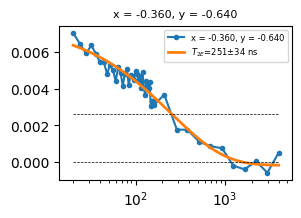

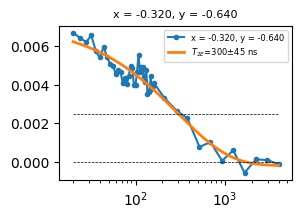

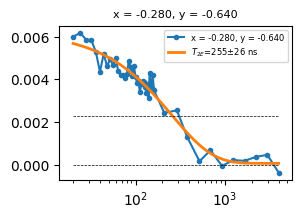

In [156]:
# Plot individual trace
j = 1; i = 2; idxArray = np.linspace(0,i,i+1-0); ifFit=1
for i in idxArray:
    i = int(i)
    fig, ax = plt.subplots(figsize=(3,2))
    label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
    xplot = tau[j,i]; yplot = dataArr[j,i]
    ax.plot(xplot,yplot, 'o-',markersize=3,  label=label)
    # ax.set_ylim((-0.002,0.009))#1.1*np.max(yplot)))
    ax.set_xscale('log')
    ax.set_xlim((14,1.4*np.max(xplot)))
    if ifFit:
        guesses = [
            # np.array((0.01, 0.00, 60, 1)),
            # np.array((0.008, 0.001, 100, 1)),
            # np.array((0.008, 0.001, 150, 1)),
            # np.array((0.008, 0.001, 200, 1)),
            np.array((0.008, 0.001, 250, 1)),
            np.array((0.006, 0.001, 1500, 1)),
            np.array((0.006, 0.001, 2000, 0.8)),
            np.array((0.008, 0.00, 50, 1)),
            np.array((0.008, 0.00, 100, 1)),
            np.array((0.008, 0.00, 150, 1)),
            np.array((0.008, 0.00, 200, 1)),
            np.array((0.008, 0.00, 250, 1)),
            np.array((0.006, 0.00, 1500, 1)),
            np.array((0.006, 0.00, 2000, 0.8)),
            np.array((0.08, 0.00, 100, 0.8)),
        ]
        lowerBounds=np.array((0, -1, 50, 1))
        lowerBounds=np.array((0, -1, 50, 0))
        lowerBounds=None
        # if np.max(xplot) > 5000:
        #     for guess in guesses:
        #         guess[2] = 7000  # override T2 guess if necessary

        for guess in guesses:
            try:
                # ax.plot(xplot, dr.strDecay(xplot,*guess), '-', linewidth=2,color='C2')
                xfit, yfit, popt, perr = dr.fitStrDecay(xplot, yplot, guess=guess, logx=1,lowerBounds=lowerBounds)
                s = '$T_{2E}$=%.0f$\pm$%.0f ns' % (popt[2], perr[2])
                print(popt[3])
                ax.plot(xfit, yfit, '-', linewidth=2, color='C1', label=s)
                ax.hlines(y=0,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
                ax.hlines(y=np.max(yplot)/np.e,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
                break  # Stop if successful
            except Exception as e:
                continue  # Try next guess
        print('-------------------------')
    ax.legend(fontsize=6)
    ax.set_title(label,fontsize=8)

In [12]:
T2EArray = np.ones((ny,nx))*(0); T2EErrArray = np.zeros((ny,nx))
for j in range(ny):
    for i in range(nx):
        try:
            xplot=tau[j,i]; yplot=dataArr[j,i]
            guesses = [
                # np.array((0.01, 0.00, 60, 1)),
                # np.array((0.008, 0.001, 100, 1)),
                # np.array((0.008, 0.001, 150, 1)),
                # np.array((0.008, 0.001, 200, 1)),
                np.array((0.008, 0.001, 250, 1)),
                np.array((0.006, 0.001, 1500, 1)),
                np.array((0.006, 0.001, 2000, 0.8)),
                np.array((0.008, 0.00, 50, 1)),
                np.array((0.008, 0.00, 100, 1)),
                np.array((0.008, 0.00, 150, 1)),
                np.array((0.008, 0.00, 200, 1)),
                np.array((0.008, 0.00, 250, 1)),
                np.array((0.006, 0.00, 1500, 1)),
                np.array((0.006, 0.00, 2000, 0.8)),
                np.array((0.08, 0.00, 100, 0.8)),
            ]
            lowerBounds=np.array((0, -1, 50, 1))
            lowerBounds=np.array((0, -1, 50, 0))
            lowerBounds=None
            # if np.max(xplot) > 5000:
            #     for guess in guesses:
            #         guess[2] = 7000  # override T2 guess if necessary

            for guess in guesses:
                try:
                    xfit, yfit, popt, perr = dr.fitStrDecay(xplot,yplot, guess=guess, lowerBounds=lowerBounds,logx=0)
                    T2EArray[j,i] = popt[2]; T2EErrArray[j,i] = perr[2]
                    break  # Stop if successful
                except Exception as e:
                    continue  # Try next guess
        except:pass

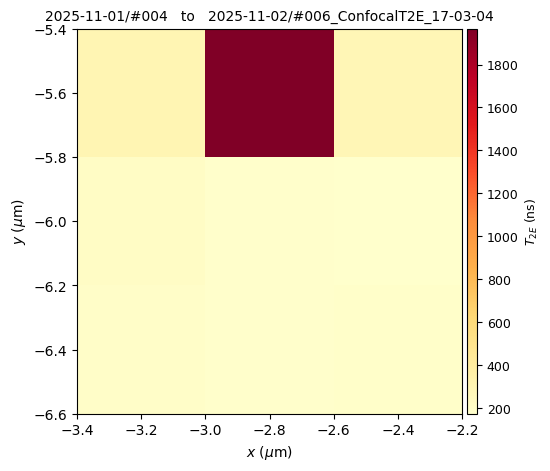

In [13]:
# 2D       
X = x[:,:,0]*conv_voltage; Y = y[:,:,0]*conv_voltage
fig, ax = plt.subplots(figsize=(5,5))

plot = ax.pcolormesh(X,Y, T2EArray, cmap='YlOrRd')
    
ax.set_aspect(1)
# plot = ax.pcolormesh(X,Y, np.min(dataArr,axis=2), cmap='inferno')
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
cbar = fig.colorbar(plot, cax = cax)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$T_{2E}$ (ns)', fontsize=9)
a = 1000
# plot.set_clim(0,a)

ax.set_xlabel('$V_x$ (V)')
ax.set_ylabel('$V_y$ (V)')

ax.set_xlabel('$x$ ($\mu$m)')
ax.set_ylabel('$y$ ($\mu$m)')
sp = 0.04*conv_voltage
for j in range(ny):
    for i in range(nx):
        if T2EArray[j,i]==0:
            ax.add_patch(plt.Rectangle((X[0][i]-sp/2, Y[j][0]-sp/2), sp, sp, color='black'))

s = firstdatafile[31:46] + '   to   ' + datafile[31:67]
ax.set_title(s,fontsize=10)

plt.tight_layout;

In [733]:
# T2EArray    = np.array((232,536,358,155,  233,278,50, 393,50, 183,  324,296,369,348,332,406,  404,239,194,65, 259,407)) # 9.5K
# T2EErrArray = np.array((81, 159,78, 133,  60, 67, 245,142,187,293,  91, 74, 125,65, 68, 76,   189,189,136,391,86, 157)) # 9.5K
# T2EArray = np.array((249)); T2EErrArray = np.array((20)) # 20K
# T2EArray = np.array((338,459,139,465,86,301,221)); T2EErrArray = np.array((95,96,194,87,148,162,40)) # 30K
# T2EArray = np.array((116,53,77,52,50,86)); T2EErrArray = np.array((22,38,45,110,60,39)) # 40K
# T2EArray = np.array((130, 118)); T2EErrArray = np.array((11,9)) # 42K
# nArray = np.array((1.32,1.30)); nErrArray = np.array((0.215, 0.187)) # 42K
# T2EArray = np.array((356,284)); T2EErrArray = np.array((19,28)) # 9.5K
# nArray = np.array((1.034,0.963)); nErrArray = np.array((0.084, 0.139)) # 9.5K

# mask1 = T2EArray > 3000; mask2 = T2EErrArray < 3000; mask = mask1 & mask2 # 9.5 K off flake
# T2EArray = T2EArray[mask]; T2EErrArray = T2EErrArray[mask] # 9.5 K off flake
# mask1 = T2EArray > 3000; mask2 = T2EErrArray < 3000; mask = mask1 & mask2 # 20 K off flake
# T2EArray = T2EArray[mask]; T2EErrArray = T2EErrArray[mask] # 20 K off flake
# mask = T2EArray > 3000; T2EArray = T2EArray[mask]; T2EErrArray = T2EErrArray[mask] # 30 K off flake
# mask = T2EArray > 3000; T2EArray = T2EArray[mask]; T2EErrArray = T2EErrArray[mask] # 40 K off flake
# T2EArray = np.array((3850,4067)); T2EErrArray = np.array((109,99)) # 53K off flake
# T2EArray = np.array((4116,4045,4224,4287)); T2EErrArray = np.array((160,179,221,139)) # 57.5K off flake

# T2EArray = np.array((3626,3569,4361,3941,3775,4430), np.int64); T2EErrArray = np.array((114,121,129,187,223,156), np.int64)
# T2EArray = np.array((4900,4752), np.int64); T2EErrArray = np.array((244,293), np.int64) # 43.75 K off flake
# T2EArray = T2EArray[:,1:]; T2EErrArray = T2EErrArray[:,1:] # 41.5 K on flake
np.shape(T2EArray)

(3, 3)

In [734]:
maskT2 = np.where(T2EErrArray<3)
T2EErrArray[maskT2] = 1000000000
maskT2 = np.where(T2EArray<10)
T2EErrArray[maskT2] = 1000000000

meanT2E = np.mean(T2EArray)
meanT2EErr = np.mean(T2EErrArray)
print('Mean T2E = %.0f ns' % meanT2E)
print('Mean T2E err = %.0f ns' % meanT2EErr)

weights = 1/T2EErrArray**2
meanT2E_weighted = np.sum(T2EArray*weights)/np.sum(weights)
meanT2EErr_weighted = np.sqrt(1/np.sum(weights))
print('Mean T2E weighted = %.0f ns' % meanT2E_weighted)
print('Mean T2E err weighted = %.0f ns' % meanT2EErr_weighted)

weights = 1/nErrArray**2
meann_weighted = np.sum(nArray*weights)/np.sum(weights)
meannErr_weighted = np.sqrt(1/np.sum(weights))
print('Mean n weighted = %.3f' % meann_weighted)
print('Mean n err weighted = %.3f' % meannErr_weighted)

Mean T2E = 608 ns
Mean T2E err = 64 ns
Mean T2E weighted = 559 ns
Mean T2E err weighted = 15 ns
Mean n weighted = 1.015
Mean n err weighted = 0.072


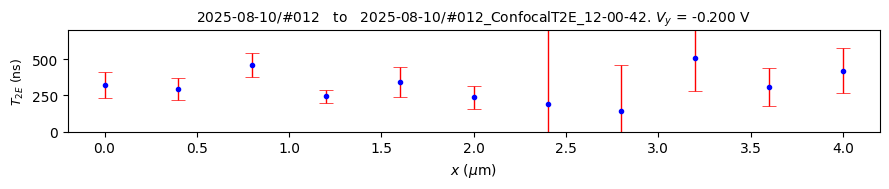

In [1875]:
rowidx=2
if True:
    fig, ax = plt.subplots(figsize=(9,2))

    xplot = x[:,:,0][rowidx]*10

    plot = ax.errorbar(xplot, T2EArray[rowidx], T2EErrArray[rowidx],
                    fmt='o', color='blue', markersize=3, capsize=5, capthick=0.5, ecolor='red', elinewidth=1);

        
    ax.set_xlabel('$x$ ($\mu$m)')
    ax.set_ylabel('$T_{2E}$ (ns)', fontsize=9)
    ax.set_ylim((0,700))

    s = firstdatafile[31:46] + '   to   ' + datafile[31:67]
    ax.set_title(s + '. $V_y$ = %.3f V' % y[:,:,0][rowidx][0], fontsize=10)

    plt.tight_layout()

## Revised fit

### Manually

In [151]:
dataArr = []; ifSingleGreenRead=1; convfactor = 2*0.028*1e6; conv_voltage=10
month = 11; days = np.linspace(1,31,31); count=0; ifYCountDown=1
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-'+str(int(month)).zfill(2)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalT2E'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                if True:
                    batch1a = (day==10 and idx==9)
                    batch1b = (day==10 and idx==12)
                    batch1c = (day==11 and idx>=4 and idx<=5)
                    batch2 = (day==11 and idx==6) # base, big data
                    batch2b = (day==11 and idx==8) # 9.5K, off flake (same as above)
                    batch3 = (day==18 and idx==1) # 20 K
                    batch4 = (day==18 and idx==22) # 30 K
                    batch5 = (day==19 and idx==24) # 40 K
                    #############################################
                    batch6 = (day==20 and idx>=40) # 43 K, start to do 3x3 grid from here
                    batch7 = (day==21 and idx<=17) # 44.5 K
                    batch8 = (day==21 and idx>=34 and idx<=35) # 46 K
                    batch9 = (day==22 and idx<=18) # 47.5 K
                    batch10 = (day==23 and idx<=2) # 49 K
                    batch10b = (day==23 and idx>=4 and idx<=7) # 49 K off flake
                    batch11 = (day==23 and idx>=8 and idx<=222) # 51K
                    batch11b = (day==24 and idx<=5) # 51K off flake
                    batch12 = (day==25 and idx<=3) # 53K on flake
                    batch13 = (day==26 and idx<=12) # 55K on flake
                    batch14 = (day==26 and idx>=13 and idx<=32) #57.5K on flake
                    batch14b = (day==26 and idx>=33 and idx<=332) #57.5K on flake again
                    batch15 = (day==27 and idx==18) # 60 K
                    batch16 = (day==28 and idx==11) # 65 K
                    batch17 = (day==30 and idx<=6) # 120K
                if True:
                    batch18 = (day==30 and idx==20) # 60 K
                    batch18b = (day==31 and idx==8) # 60 K off flake
                    batch19 = (day==31 and idx==19) # 55K
                    batch19b = (day==1 and idx==2) #55K off flake
                    batch20 = (day==1 and idx==19) # 51K
                    batch21 = (day==2 and idx==11) # 48.75K
                    batch22 = (day==2 and idx>=30 and idx<=31) # 46.75K
                    batch23 = (day==3 and idx==24) # 45.25K
                    batch23b = (day==4 and idx<=5) # 45.25K off flake
                    batch24 = (day==5 and idx==1) # 44.5 K
                    batch24b = (day==4 and idx>=17 and idx<=18) # 44.5 K off flake
                    batch25 = (day==5 and idx==15) # 43.75K
                    batch25b = (day==5 and idx>=18) # 43.75 K off flake
                    batch26 = (day==6 and idx<=2) # 43K
                    batch26b = (day==6 and idx>=5 and idx<=6) # 43K off flake
                    batch27 = (day==6 and idx>=7 and idx <=15) # 42.5 K
                    batch28 = (day==6 and idx>=29) # 42 K
                    batch28b = (day==7 and idx<=2) # 42 K off flake
                    batch29 = (day==7 and idx>=15 and idx<=16) # 41.5K
                    batch30 = (day==7 and idx>=32) # 41K
                    batch31 = (day==8 and idx>=13 and idx<=14) # 40 K
                    batch31b = (day==8 and idx>=18 and idx<=19) # 40 K off flake
                    batch32 = (day==8 and idx>=31) #39 K
                    batch33 = (day==9 and idx<=15) #38 K
                    batch34 = (day==9 and idx>=29 and idx<=30) # 37K
                    batch35 = (day==10 and idx<=12) # 36K
                    batch35b = (day==10 and idx==23) # 36K off flake
                    batch36 = (day==11 and idx<=15) # 35K
                    batch37 = (day==11 and idx>=26 and idx<=27) # 34K
                    batch38 = (day==11 and idx>=41 and idx<=42) # 33K
                    batch39 = (day==12 and idx<=2) # 32K
                    batch39b = (day==12 and idx>=3 and idx<=7) # 32K off flake
                    batch40 = (day==12 and idx>=8 and idx<=20) # 31K
                    batch41 = (day==13 and idx<=10) # 30K
                    batch41b = (day==13 and idx>=14 and idx<=15) # 30K off flake
                    batch42 = (day==13 and idx>=16 and idx<=30) # 29K
                    batch43 = (day==14 and idx<=3) # 28K
                    batch44 = (day==14 and idx>=4 and idx<=20) # 27K
                    batch45 = (day==15 and idx<=2) # 26K
                    batch45b = (day==15 and idx>=3 and idx<=7) #26K off flake
                    batch46 = (day==15 and idx>=21 and idx<=22) # 24K 
                    batch47 = (day==16 and idx<=2) # 22K on flake
                    batch47b = (day==16 and idx>=6 and idx<=7) # 22K off flake
                    batch48 = (day==16 and idx>=11 and idx<=13) # 20K
                    batch49 = (day==17 and idx>=10 and idx<=11) # 18K
                    batch50 = (day==17 and idx>=21 and idx<=22) # 16K  
                    batch50b = (day==17 and idx==25) # 16K off flake
                    batch51 = (day==17 and idx>=26) # 14 K
                    batch52 = (day==18 and idx<=7) # 12K
                    batch52b = (day==18 and idx>=8) # 12K off flake
                    batch53 = (day==19 and idx<=7) # 9.5 K
                    batch53b = (day==19 and idx>=13) # 9.5 K off flake
                if True:
                    batch54 = (day==22 and idx<=8) # 9.5 K on flake after FC North
                    batch54b = (day==28 and idx<=9) # 9.5K 5 us l2A delay
                    batch54c = (day==29) # 9.5K msmt magnet North
                    batch55 = (day==23 and idx<=7) # 20 K
                    batch55b = (day==24 and idx<=12) # 20 K 5 us l2A delay
                    batch56 = (day==25 and idx<=3) # 25 K
                    batch57 = (day==27) # 30 K
                    batch58 = (day==30) # 39 K
                    batch59 = (day==3) # 40 K
                    batch60 = (day==7 and idx <= 9) # 9.5K FC South, msmt magnet North
                if True:
                    batch61 = (day<=2) # 30K
                    batch62 = (day==3 and idx<=12) # 29K
                    batch63 = (day==3 and idx>=13) # 28 K
                    batch64 = (day==4 and idx<=12) # 27 K
                if batch64:  
                    # print(idx)
                    if batch1a: ifYCountDown=0
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,tau,sig,ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
                    sig = np.array(sig); ref = np.array(ref); contrast = (sig-ref)/(sig+ref)
                    x = np.array(x); y = np.array(y)
                    (ny,nx,ntau) = np.shape(sig)
                    if batch1c:
                        contrast = np.array(contrast)[0:3,0:2]
                        print(np.shape(contrast))
                        if isinstance(dataArr, list) and len(dataArr) == 0:   # first time
                            dataArr = contrast[np.newaxis, ...]   # shape (1,3,2)
                        else:
                            dataArr = np.concatenate((dataArr, contrast[np.newaxis, ...]), axis=0)
                        print(dataArr.shape)
                    elif batch2:
                        contrast = np.array(contrast)[-3:,0:2]
                        print(np.shape(contrast))
                        if isinstance(dataArr, list) and len(dataArr) == 0:   # first time
                            dataArr = contrast[np.newaxis, ...]   # shape (1,3,2)
                        else:
                            dataArr = np.concatenate((dataArr, contrast[np.newaxis, ...]), axis=0)
                        print(dataArr.shape)
                    else:
                        dataArr.append(contrast)
                

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
dataArr = np.array(dataArr); print(np.shape(dataArr))

# dataArr = np.stack(dataArr, axis=0)
# print(dataArr.shape)


(6, 3, 3, 47)


In [152]:
# Averaging data
if True: # standard
    dataArr = np.average(dataArr, axis=(0,1,2)); print(np.shape(dataArr))

    # Normalization
    # # dataArr = dataArr - np.average(dataArr[-2:])
    dataArr = dataArr/ np.max(dataArr) #dataArr[0]

    # dataArr = linear_map(dataArr,np.max(dataArr),np.min(dataArr),1,0)
if False: # for batch5 40 K
    dataArr = dataArr[0,0,0:3]; print(np.shape(dataArr))
    dataArr2D = dataArr


    # Multiple
    days = np.linspace(1,31,31); count=0; ifLog=0; ifFit=1
    dataArr = []; sigArr = []; refArr = []
    for day in days:
        mainFolder = 'C:/Users/lukin2dmaterials/data/2025-08-' + str(int(day)).zfill(2) + '/'
        try:
            for dataFolder in os.listdir(mainFolder):
                if 'T2EAWG' in dataFolder:
                    idx = int(dataFolder[1:4])
                    batch1 = day==20 and idx>=3 and idx<=10
                    if batch1:
                        datafile = mainFolder + dataFolder +'/T2EAWGObject_sig_set.dat'
                        x_s, sig, ref = dr.readDataNoPlot(datafile)

                        sig = np.array(sig); ref = np.array(ref)
                        contrast = (sig-ref)/(sig+ref)
                        xPlot = x_s; xPlot = np.array(xPlot)

                        sorted_indices = np.argsort(xPlot)
                        xPlot = xPlot[sorted_indices]
                        contrast = contrast[sorted_indices]
                        sig = sig[sorted_indices]
                        ref = ref[sorted_indices]

                        dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                        if count==0: firstdatafile = datafile
                        count+=1
        except:pass

    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    dataArr = np.vstack([dataArr,dataArr2D]); print(np.shape(dataArr))
    dataArr = np.average(dataArr, axis=(0)); print(np.shape(dataArr))
    # dataArr=dataArr2D
    dataArr = dataArr/ np.max(dataArr)

if False: # for batch4 30 K
    dataArr = dataArr[0,0:3,0:2]; print(np.shape(dataArr))
    dataArr2D = dataArr.reshape(6,16); print(np.shape(dataArr2D))


    # Multiple
    days = np.linspace(1,31,31); count=0; ifLog=0; ifFit=1
    dataArr = []; sigArr = []; refArr = []
    for day in days:
        mainFolder = 'C:/Users/lukin2dmaterials/data/2025-08-' + str(int(day)).zfill(2) + '/'
        try:
            for dataFolder in os.listdir(mainFolder):
                if 'T2EAWG' in dataFolder:
                    idx = int(dataFolder[1:4])
                    batch1 = day==18 and idx>=16 and idx<=18
                    if batch1:
                        datafile = mainFolder + dataFolder +'/T2EAWGObject_sig_set.dat'
                        x_s, sig, ref = dr.readDataNoPlot(datafile)

                        sig = np.array(sig); ref = np.array(ref)
                        contrast = (sig-ref)/(sig+ref)
                        xPlot = x_s; xPlot = np.array(xPlot)

                        sorted_indices = np.argsort(xPlot)
                        xPlot = xPlot[sorted_indices]
                        contrast = contrast[sorted_indices]
                        sig = sig[sorted_indices]
                        ref = ref[sorted_indices]

                        dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                        if count==0: firstdatafile = datafile
                        count+=1
        except:pass

    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    dataArr = np.vstack([dataArr,dataArr2D]); print(np.shape(dataArr))
    dataArr = np.average(dataArr, axis=(0)); print(np.shape(dataArr))
    # dataArr=dataArr2D
    dataArr = dataArr/ np.max(dataArr)

if False: # for batch1c and batch2 9.5 K
    dataArr = np.average(dataArr, axis=(0,1,2)); print(np.shape(dataArr))
    dataArr = dataArr/ np.max(dataArr)

if False: # for batch1b 9.5 K
    dataArr = dataArr[0,:,0:2,:]; print(np.shape(dataArr))
    dataArr1b = dataArr
    dataArr = np.average(dataArr, axis=(0,1)); print(np.shape(dataArr))
    dataArr = dataArr/ np.max(dataArr)

if False: # for batch1a 9.5 K
    dataArr = dataArr[0,:,0:2,:]; print(np.shape(dataArr))
    dataArr = np.vstack((dataArr1b, dataArr)); print(np.shape(dataArr))
    dataArr = np.average(dataArr, axis=(0,1)); print(np.shape(dataArr))
    dataArr = dataArr/ np.max(dataArr)

if False: # for batch2b 9.5 K off flake and batch3 20K off flake
    dataArr = dataArr[0]
    T2EArray = np.ones((ny,nx))*(0); T2EErrArray = np.zeros((ny,nx))
    for j in range(ny):
        for i in range(nx):
            try:
                xplot=tau[j,i]; yplot=dataArr[j,i]
                guesses = [
                    np.array((0.01, 0.00, 60, 1)),
                    np.array((0.008, 0.001, 100, 1)),
                    np.array((0.008, 0.001, 150, 1)),
                    np.array((0.008, 0.001, 200, 1)),
                    np.array((0.008, 0.001, 250, 1)),
                    np.array((0.006, 0.001, 1500, 1)),
                    np.array((0.006, 0.001, 2000, 0.8)),
                    np.array((0.008, 0.00, 50, 1)),
                    np.array((0.008, 0.00, 100, 1)),
                    np.array((0.008, 0.00, 150, 1)),
                    np.array((0.008, 0.00, 200, 1)),
                    np.array((0.008, 0.00, 250, 1)),
                    np.array((0.006, 0.00, 1500, 1)),
                    np.array((0.006, 0.00, 2000, 0.8)),
                    np.array((0.08, 0.00, 100, 0.8)),
                ]
                lowerBounds=np.array((0, -1, 50, 1))
                lowerBounds=np.array((0, -1, 50, 0))
                # lowerBounds=None
                if np.max(xplot) > 5000:
                    for guess in guesses:
                        guess[2] = 7000  # override T2 guess if necessary

                for guess in guesses:
                    try:
                        xfit, yfit, popt, perr = dr.fitStrDecay(xplot,yplot, guess=guess, lowerBounds=lowerBounds,logx=0)
                        T2EArray[j,i] = popt[2]; T2EErrArray[j,i] = perr[2]
                        break  # Stop if successful
                    except Exception as e:
                        continue  # Try next guess
            except:pass
    mask1 = T2EArray > 5000; mask2 = T2EErrArray < 2000; mask = mask1 & mask2 # 9.5 K off flake
    mask_expanded = mask[np.newaxis, :, :, np.newaxis]; print(np.shape(mask_expanded))
    
    selected = dataArr[mask, :]   # shape (Nmask, 21), Nmask = number of True in mask
    print(np.shape(selected))

    if selected.shape[0] > 0:
        avg = selected.mean(axis=0)        # (21,)
        avg = avg[np.newaxis, :]           # back to (1,21) if you want to keep batch
    else:
        avg = np.full((1, dataArr.shape[-1]), np.nan)  # or zeros, depending on your needs
    dataArr=avg; print(np.shape(dataArr))

    dataArr = dataArr[0]/ np.max(dataArr) 
    print(np.shape(dataArr))

if False: # for batch4 30 K off flake
    dataArr = dataArr[0]
    T2EArray = np.ones((ny,nx))*(0); T2EErrArray = np.zeros((ny,nx))
    for j in range(ny):
        for i in range(nx):
            try:
                xplot=tau[j,i]; yplot=dataArr[j,i]
                guesses = [
                    np.array((0.01, 0.00, 60, 1)),
                    np.array((0.008, 0.001, 100, 1)),
                    np.array((0.008, 0.001, 150, 1)),
                    np.array((0.008, 0.001, 200, 1)),
                    np.array((0.008, 0.001, 250, 1)),
                    np.array((0.006, 0.001, 1500, 1)),
                    np.array((0.006, 0.001, 2000, 0.8)),
                    np.array((0.008, 0.00, 50, 1)),
                    np.array((0.008, 0.00, 100, 1)),
                    np.array((0.008, 0.00, 150, 1)),
                    np.array((0.008, 0.00, 200, 1)),
                    np.array((0.008, 0.00, 250, 1)),
                    np.array((0.006, 0.00, 1500, 1)),
                    np.array((0.006, 0.00, 2000, 0.8)),
                    np.array((0.08, 0.00, 100, 0.8)),
                ]
                lowerBounds=np.array((0, -1, 50, 1))
                lowerBounds=np.array((0, -1, 50, 0))
                # lowerBounds=None
                if np.max(xplot) > 5000:
                    for guess in guesses:
                        guess[2] = 7000  # override T2 guess if necessary

                for guess in guesses:
                    try:
                        xfit, yfit, popt, perr = dr.fitStrDecay(xplot,yplot, guess=guess, lowerBounds=lowerBounds,logx=0)
                        T2EArray[j,i] = popt[2]; T2EErrArray[j,i] = perr[2]
                        break  # Stop if successful
                    except Exception as e:
                        continue  # Try next guess
            except:pass
    mask1 = T2EArray > 3000; mask2 = T2EErrArray < 2000; mask = mask1 & mask2 # 30 K off flake
    mask_expanded = mask[np.newaxis, :, :, np.newaxis]; print(np.shape(mask_expanded))
    
    selected = dataArr[mask, :]   # shape (Nmask, 21), Nmask = number of True in mask
    print(np.shape(selected))

    if selected.shape[0] > 0:
        avg = selected.mean(axis=0)        # (21,)
        avg = avg[np.newaxis, :]           # back to (1,21) if you want to keep batch
    else:
        avg = np.full((1, dataArr.shape[-1]), np.nan)  # or zeros, depending on your needs
    dataArr=avg; print(np.shape(dataArr))

    dataArr = dataArr[0]/ np.max(dataArr) 
    print(np.shape(dataArr))

if False: # for batch5 40K off flake
    dataArr = dataArr[0]
    T2EArray = np.ones((ny,nx))*(0); T2EErrArray = np.zeros((ny,nx))
    for j in range(ny):
        for i in range(nx):
            try:
                xplot=tau[j,i]; yplot=dataArr[j,i]
                guesses = [
                    np.array((0.01, 0.00, 60, 1)),
                    np.array((0.008, 0.001, 100, 1)),
                    np.array((0.008, 0.001, 150, 1)),
                    np.array((0.008, 0.001, 200, 1)),
                    np.array((0.008, 0.001, 250, 1)),
                    np.array((0.006, 0.001, 1500, 1)),
                    np.array((0.006, 0.001, 2000, 0.8)),
                    np.array((0.008, 0.00, 50, 1)),
                    np.array((0.008, 0.00, 100, 1)),
                    np.array((0.008, 0.00, 150, 1)),
                    np.array((0.008, 0.00, 200, 1)),
                    np.array((0.008, 0.00, 250, 1)),
                    np.array((0.006, 0.00, 1500, 1)),
                    np.array((0.006, 0.00, 2000, 0.8)),
                    np.array((0.08, 0.00, 100, 0.8)),
                ]
                lowerBounds=np.array((0, -1, 50, 1))
                lowerBounds=np.array((0, -1, 50, 0))
                # lowerBounds=None
                if np.max(xplot) > 5000:
                    for guess in guesses:
                        guess[2] = 7000  # override T2 guess if necessary

                for guess in guesses:
                    try:
                        xfit, yfit, popt, perr = dr.fitStrDecay(xplot,yplot, guess=guess, lowerBounds=lowerBounds,logx=0)
                        T2EArray[j,i] = popt[2]; T2EErrArray[j,i] = perr[2]
                        break  # Stop if successful
                    except Exception as e:
                        continue  # Try next guess
            except:pass
    mask1 = T2EArray > 5000; mask2 = T2EErrArray < 2000; mask = mask1 & mask2 # 30 K off flake
    mask_expanded = mask[np.newaxis, :, :, np.newaxis]; print(np.shape(mask_expanded))
    
    selected = dataArr[mask, :]   # shape (Nmask, 21), Nmask = number of True in mask
    print(np.shape(selected))

    if selected.shape[0] > 0:
        avg = selected.mean(axis=0)        # (21,)
        avg = avg[np.newaxis, :]           # back to (1,21) if you want to keep batch
    else:
        avg = np.full((1, dataArr.shape[-1]), np.nan)  # or zeros, depending on your needs
    dataArr=avg; print(np.shape(dataArr))

    dataArr = dataArr[0]/ np.max(dataArr) 
    print(np.shape(dataArr))
# print(-np.log(dataArr))
xplot = tau[0,0]; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr

(47,)


C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22216\4084036537.py:275: RuntimeWarning: invalid value encountered in log
  xplot = tau[0,0]; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22216\4084036537.py:275: RuntimeWarning: divide by zero encountered in log
  xplot = tau[0,0]; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr


[288.99877591   0.91855517]
[8.7920594  0.02830419]
-------------------------


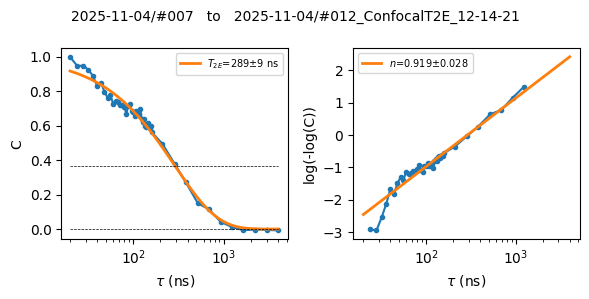

In [153]:
# Plot individual trace
ifFit=1; ifLog=1
fig, axs = plt.subplots(1,2, figsize=(6,3))

axs[0].plot(xplot,yplot0, 'o-',markersize=3,  label=None)
axs[1].plot(xplot,yplot, 'o-',markersize=3,  label=None)
if ifLog==1:
    axs[0].set_xscale('log'); axs[1].set_xscale('log')

if ifFit:
    guesses = [
        # np.array((60, 1)),
        # np.array((100, 1)),
        # np.array((160, 1)),
        # np.array((200, 1)),
        np.array((250, 0.5)),
        np.array((1500, 1)),
        np.array((2000, 0.8)),
        np.array((4000, 0.8)),
    ]
    lowerBounds=np.array((50, 1))
    lowerBounds=np.array((50, 0))
    lowerBounds=np.array((0,  0))
    lowerBounds=None

    upperBounds=None
    
    for guess in guesses:
        try:
            xfit, yfit, popt, perr = dr.fitStrDecayNorm(xplot, dataArr, guess=guess, logx=ifLog,
                                                    lowerBounds=lowerBounds, upperBounds=upperBounds)
            s = '$T_{2E}$=%.0f$\pm$%.0f ns' % (popt[0], perr[0])
            s1 = '$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])
            print(popt)
            print(perr)

            yfitplot = np.log(-np.log(yfit))
            yfitplot0 = yfit

            axs[0].plot(xfit, yfitplot0, '-', linewidth=2, color='C1', label=s)
            axs[0].hlines(y=0,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
            axs[0].hlines(y=np.max(yplot0)/np.e,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
            
            axs[1].plot(xfit, yfitplot, '-', linewidth=2, color='C1', label=s1)
            break  # Stop if successful
        except Exception as e:
            continue  # Try next guess
    print('-------------------------')

axs[0].legend(fontsize=7); axs[1].legend(fontsize=7)

if ifLog==1:
    axs[0].set_xlim(0.8*np.min(xfit),1.3*np.max(xfit))
# axs[1].set_ylim((1.2*np.nanmin(yplot[np.isfinite(yplot)]), 1.5*np.nanmax(yplot[np.isfinite(yplot)])))
axs[0].set_xlabel('$\\tau$ (ns)')
axs[0].set_ylabel('C')
axs[1].set_xlabel('$\\tau$ (ns)')
axs[1].set_ylabel('log(-log(C))')

s = firstdatafile[31:46] + '   to   ' + datafile[31:67]
fig.suptitle(s,fontsize=10)

plt.tight_layout()

In [150]:
weights = 1/T2EErrArray**2
meanT2E_weighted = np.sum(T2EArray*weights)/np.sum(weights)
meanT2EErr_weighted = np.sqrt(1/np.sum(weights))
print('Mean T2E weighted = %.0f ns' % meanT2E_weighted)
print('Mean T2E err weighted = %.0f ns' % meanT2EErr_weighted)

Mean T2E weighted = 197 ns
Mean T2E err weighted = 5 ns


(10, 11, 13)


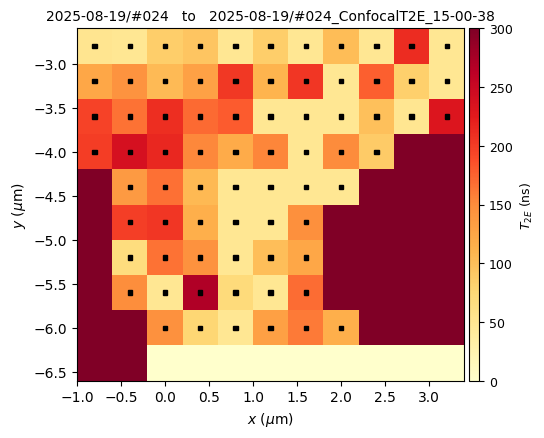

In [426]:
# test batch5
dataArr = dataArr[0]; print(np.shape(dataArr))
mask = np.ones(dataArr.shape[:2], dtype=bool)
mask[-1]=False; mask[-6:,0]=False; mask[-2,1]=False; mask[3,-2:]=False; mask[5:8,7]=False; mask[4:9,8:]=False

T2EArray = np.ones((ny,nx))*(0); T2EErrArray = np.zeros((ny,nx))
for j in range(ny):
    for i in range(nx):
        try:
            xplot=tau[j,i]; yplot=dataArr[j,i]
            guesses = [
                np.array((0.01, 0.00, 60, 1)),
                np.array((0.008, 0.001, 100, 1)),
                np.array((0.008, 0.001, 150, 1)),
                np.array((0.008, 0.001, 200, 1)),
                np.array((0.008, 0.001, 250, 1)),
                np.array((0.006, 0.001, 1500, 1)),
                np.array((0.006, 0.001, 2000, 0.8)),
                np.array((0.008, 0.00, 50, 1)),
                np.array((0.008, 0.00, 100, 1)),
                np.array((0.008, 0.00, 150, 1)),
                np.array((0.008, 0.00, 200, 1)),
                np.array((0.008, 0.00, 250, 1)),
                np.array((0.006, 0.00, 1500, 1)),
                np.array((0.006, 0.00, 2000, 0.8)),
                np.array((0.08, 0.00, 100, 0.8)),
            ]
            lowerBounds=np.array((0, -1, 50, 1))
            lowerBounds=np.array((0, -1, 50, 0))
            # lowerBounds=None
            if np.max(xplot) > 5000:
                for guess in guesses:
                    guess[2] = 7000  # override T2 guess if necessary

            for guess in guesses:
                try:
                    xfit, yfit, popt, perr = dr.fitStrDecay(xplot,yplot, guess=guess, lowerBounds=lowerBounds,logx=0)
                    T2EArray[j,i] = popt[2]; T2EErrArray[j,i] = perr[2]
                    break  # Stop if successful
                except Exception as e:
                    continue  # Try next guess
        except:pass

# 2D       
X = x[:,:,0]*conv_voltage; Y = y[:,:,0]*conv_voltage
fig, ax = plt.subplots(figsize=(5,5))

plot = ax.pcolormesh(X,Y, T2EArray, cmap='YlOrRd')
    
ax.set_aspect(1)
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
cbar = fig.colorbar(plot, cax = cax)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$T_{2E}$ (ns)', fontsize=9)
a = 300
plot.set_clim(0,a)

ax.set_xlabel('$V_x$ (V)')
ax.set_ylabel('$V_y$ (V)')

ax.set_xlabel('$x$ ($\mu$m)')
ax.set_ylabel('$y$ ($\mu$m)')

sp = 0.005*conv_voltage
for (j,i), val in np.ndenumerate(mask):
    if val: 
        ax.add_patch(plt.Rectangle((X[0][i]-sp/2, Y[j][0]-sp/2), sp, sp, color='black'))

s = firstdatafile[31:46] + '   to   ' + datafile[31:67]
ax.set_title(s,fontsize=10)

plt.tight_layout;

### Autofit across different temperatures

In [ ]:
# ---------------------  Cooling ----------------------------
# 1) Batch definitions (month added, temperature T)
# -------------------------------------------------
batches = {
    "batch18":  {"month": 8, "day": 30, "idx": 20, "T": 60, "off_flake": False},
    "batch18b": {"month": 8, "day": 31, "idx": 8,  "T": 60, "off_flake": True},
    "batch19":  {"month": 8, "day": 31, "idx": 19, "T": 55, "off_flake": False},

    "batch19b": {"month": 9, "day": 1,  "idx": 2,  "T": 55, "off_flake": True},
    "batch20":  {"month": 9, "day": 1,  "idx": 19, "T": 51, "off_flake": False},
    "batch21":  {"month": 9, "day": 2,  "idx": 11, "T": 48.75, "off_flake": False},
    "batch22":  {"month": 9, "day": 2,  "idx_range": (30, 31), "T": 46.75, "off_flake": False},
    "batch23":  {"month": 9, "day": 3,  "idx": 24, "T": 45.25, "off_flake": False},
    "batch23b": {"month": 9, "day": 4,  "idx_range": (0, 5), "T": 45.25, "off_flake": True},
    "batch24":  {"month": 9, "day": 5,  "idx": 1,  "T": 44.5, "off_flake": False},
    "batch24b": {"month": 9, "day": 4,  "idx_range": (17, 18), "T": 44.5, "off_flake": True},
    "batch25":  {"month": 9, "day": 5,  "idx": 15, "T": 43.75, "off_flake": False},
    "batch25b": {"month": 9, "day": 5,  "idx_min": 18, "T": 43.75, "off_flake": True},
    "batch26":  {"month": 9, "day": 6,  "idx_range": (0, 2), "T": 43, "off_flake": False},
    "batch26b": {"month": 9, "day": 6,  "idx_range": (5, 6), "T": 43, "off_flake": True},
    "batch27":  {"month": 9, "day": 6,  "idx_range": (7, 15), "T": 42.5, "off_flake": False},
    "batch28":  {"month": 9, "day": 6,  "idx_min": 29, "T": 42, "off_flake": False},
    "batch28b": {"month": 9, "day": 7,  "idx_range": (0, 2), "T": 42, "off_flake": True},
    "batch29":  {"month": 9, "day": 7,  "idx_range": (15, 16), "T": 41.5, "off_flake": False},
    "batch30":  {"month": 9, "day": 7,  "idx_min": 32, "T": 41, "off_flake": False},
    "batch31":  {"month": 9, "day": 8,  "idx_range": (13, 14), "T": 40, "off_flake": False},
    "batch31b": {"month": 9, "day": 8,  "idx_range": (18, 19), "T": 40, "off_flake": True},
    "batch32":  {"month": 9, "day": 8,  "idx_min": 31, "T": 39, "off_flake": False},
    "batch33":  {"month": 9, "day": 9,  "idx_max": 15, "T": 38, "off_flake": False},
    "batch34":  {"month": 9, "day": 9,  "idx_range": (29, 30), "T": 37, "off_flake": False},
    "batch35":  {"month": 9, "day": 10, "idx_max": 12, "T": 36, "off_flake": False},
    "batch35b": {"month": 9, "day": 10, "idx": 23, "T": 36, "off_flake": True},
    "batch36":  {"month": 9, "day": 11, "idx_max": 15, "T": 35, "off_flake": False},
    "batch37":  {"month": 9, "day": 11, "idx_range": (26, 27), "T": 34, "off_flake": False},
    "batch38":  {"month": 9, "day": 11, "idx_range": (41, 42), "T": 33, "off_flake": False},
    "batch39":  {"month": 9, "day": 12, "idx_max": 2, "T": 32, "off_flake": False},
    "batch39b": {"month": 9, "day": 12, "idx_range": (3, 7), "T": 32, "off_flake": True},
    "batch40":  {"month": 9, "day": 12, "idx_range": (8, 20), "T": 31, "off_flake": False},
    "batch41":  {"month": 9, "day": 13, "idx_max": 10, "T": 30, "off_flake": False},
    "batch41b": {"month": 9, "day": 13, "idx_range": (14, 15), "T": 30, "off_flake": True},
    "batch42":  {"month": 9, "day": 13, "idx_range": (16, 30), "T": 29, "off_flake": False},
    "batch43":  {"month": 9, "day": 14, "idx_max": 3, "T": 28, "off_flake": False},
    "batch44":  {"month": 9, "day": 14, "idx_range": (4, 20), "T": 27, "off_flake": False},
    "batch45":  {"month": 9, "day": 15, "idx_max": 2, "T": 26, "off_flake": False},
    "batch45b": {"month": 9, "day": 15, "idx_range": (3, 7), "T": 26, "off_flake": True},
    "batch46":  {"month": 9, "day": 15, "idx_range": (21, 22), "T": 24, "off_flake": False},
    "batch47":  {"month": 9, "day": 16, "idx_max": 2, "T": 22, "off_flake": False},
    "batch47b": {"month": 9, "day": 16, "idx_range": (6, 7), "T": 22, "off_flake": True},
    "batch48":  {"month": 9, "day": 16, "idx_range": (11, 13), "T": 20, "off_flake": False},
    "batch49":  {"month": 9, "day": 17, "idx_range": (10, 11), "T": 18, "off_flake": False},
    "batch50":  {"month": 9, "day": 17, "idx_range": (21, 22), "T": 16, "off_flake": False},
    "batch50b": {"month": 9, "day": 17, "idx": 25, "T": 16, "off_flake": True},
    "batch51":  {"month": 9, "day": 17, "idx_min": 26, "T": 14, "off_flake": False},
    "batch52":  {"month": 9, "day": 18, "idx_max": 7, "T": 12, "off_flake": False},
    "batch52b": {"month": 9, "day": 18, "idx_min": 8, "T": 12, "off_flake": True},
    "batch53":  {"month": 9, "day": 19, "idx_max": 7, "T": 9.5, "off_flake": False},
    "batch53b": {"month": 9, "day": 19, "idx_min": 13, "T": 9.5, "off_flake": True},
}

# -------------------------------
# 2) Helpers
# -------------------------------
def idx_matches(cfg, idx):
    if "idx" in cfg:
        return idx == cfg["idx"]
    if "idx_range" in cfg:
        a, b = cfg["idx_range"]
        return (idx >= a) and (idx <= b)
    if "idx_min" in cfg:
        return idx >= cfg["idx_min"]
    if "idx_max" in cfg:
        return idx <= cfg["idx_max"]
    return False

def load_contrasts_for_batch(base_dir, cfg, ifYCountDown=1):
    """Return list of contrast arrays for all folders matching the batch."""
    month, day = cfg["month"], cfg["day"]
    mainFolder = f"{base_dir}/2025-0{month}-{int(day):02d}/"
    out, firstfile, lastfile, tau_ref = [], None, None, None
    try:
        for dataFolder in os.listdir(mainFolder):
            if "ConfocalT2E" not in dataFolder:
                continue
            idx = int(dataFolder[1:4])
            if not idx_matches(cfg, idx):
                continue
            type_ = "ConfocalT2E"
            datafile = (mainFolder + dataFolder + '/' +
                        f"{type_}Object_y_set_{type_}Object_x_set_{type_}Object_sig_set.dat")
            x, y, tau, sig, ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
            sig = np.array(sig); ref = np.array(ref)
            contrast = (sig - ref) / (sig + ref)
            out.append(contrast)
            tau_ref = tau  # keep the last one (they should be identical)
            if firstfile is None:
                firstfile = datafile
            lastfile = datafile
    except Exception as e:
        pass
    return out, tau_ref, firstfile, lastfile

# -------------------------------
# 3) Iterate batches and plot
# -------------------------------
base_dir = "C:/Users/lukin2dmaterials/data"  # root path up to year
ifSingleGreenRead = 1
ifYCountDown = 1
convfactor = 2*0.028*1e6
conv_voltage = 10
ifFit = 1
ifLog = 0

results = {
    "on": {"temp": [], "n": [], "n_err": [], "t2e": [], "t2e_err": []},
    "off": {"temp": [], "n": [], "n_err": [], "t2e": [], "t2e_err": []},
}


for bname, cfg in batches.items():
    # Collect all files for this batch
    arr_list, tau, firstfile, lastfile = load_contrasts_for_batch(base_dir, cfg, ifYCountDown=ifYCountDown)
    if not arr_list:
        print(f"[{bname}] no matching data found.")
        continue

    # Title includes batch name, temperature, off/on flake, and file span
    tempK = cfg["T"]
    flake_str = "off flake" if cfg.get("off_flake", False) else "on flake"
    key = "off" if flake_str == "off flake" else "on"

    dataArr = np.array(arr_list)
    # Average over pixels and stack dimension
    if (tempK in (42, 43)) and (flake_str == "on flake"):
        dataArr = dataArr[:, :, 1:, :]   # drop column 0 (axis=2 is x)
    dataArr = np.average(dataArr, axis=(0, 1, 2))

    # Normalize
    dataArr = dataArr / np.max(dataArr) #dataArr[0]

    # dataArr = dataArr - np.average(dataArr[-2:])
    # dataArr = dataArr/dataArr[0]
    # dataArr = linear_map(dataArr,np.max(dataArr),np.min(dataArr),1,0)

    # Prepare plot data
    xplot = tau[0, 0]
    yplot0 = dataArr
    yplot = np.log(-np.log(dataArr))

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].plot(xplot, yplot0, 'o-', markersize=3)
    axs[1].plot(xplot, yplot,  'o-', markersize=3)
    axs[0].set_xscale('log'); axs[1].set_xscale('log')

    # Fit (stretched exponential, using your helper)
    if ifFit:
        guesses = [np.array((250, 0.5)),
                   np.array((1500, 1.0)),
                   np.array((2000, 0.8)),
                   np.array((4000, 0.8))]
        lowerBounds = None
        upperBounds = None
        fitted = False
        for guess in guesses:
            try:
                xfit, yfit, popt, perr = dr.fitStrDecayNorm(
                    xplot, dataArr, guess=guess, logx=ifLog,
                    lowerBounds=lowerBounds, upperBounds=upperBounds
                )
                s_T = r'$T_{2E}$=%.0f$\pm$%.0f ns' % (popt[0], perr[0])
                s_n = r'$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])

                yfitplot0 = yfit
                yfitplot = np.log(-np.log(yfit))

                axs[0].plot(xfit, yfitplot0, '-', linewidth=2, color='C1', label=s_T)
                axs[0].hlines(y=0, xmin=min(xfit), xmax=max(xfit),
                              linestyle='--', color='k', linewidth=0.5)
                axs[0].hlines(y=np.max(yplot0)/np.e, xmin=min(xfit), xmax=max(xfit),
                              linestyle='--', color='k', linewidth=0.5)

                axs[1].plot(xfit, yfitplot, '-', linewidth=2, color='C1', label=s_n)
                fitted = True
                break
            except Exception:
                continue

        if fitted:
            axs[0].legend(fontsize=7)
            axs[1].legend(fontsize=7)

    # Labels and title (with temperature)
    axs[0].set_xlabel(r'$\tau$ (ns)'); axs[0].set_ylabel('C')
    axs[1].set_xlabel(r'$\tau$ (ns)'); axs[1].set_ylabel(r'log(-log(C))')

    if fitted:
        axs[0].set_xlim(0.7*np.min(xfit), 1.3*np.max(xfit))

    # Add to result dictionary
    results[key]["temp"].append(tempK)
    results[key]["n"].append(popt[1])
    results[key]["n_err"].append(perr[1])
    results[key]["t2e"].append(popt[0])
    results[key]["t2e_err"].append(perr[0])

    span = ""
    if firstfile and lastfile:
        span = f"{firstfile[31:46]}   to   {lastfile[31:67]}"
    fig.suptitle(f"{bname} — {tempK} K ({flake_str})\n{span}", fontsize=10)

    plt.tight_layout()
    plt.show()

temp_on_down   = np.array(results["on"]["temp"])
n_on_down      = np.array(results["on"]["n"])
n_err_on_down  = np.array(results["on"]["n_err"])
t2e_on_down    = np.array(results["on"]["t2e"])
t2e_err_on_down= np.array(results["on"]["t2e_err"])

temp_off_down   = np.array(results["off"]["temp"])
n_off_down      = np.array(results["off"]["n"])
n_err_off_down  = np.array(results["off"]["n_err"])
t2e_off_down    = np.array(results["off"]["t2e"])
t2e_err_off_down= np.array(results["off"]["t2e_err"])

In [ ]:
# ---------------------  Heating ----------------------------
# 1) Batch definitions (month added, temperature T)
# -------------------------------------------------
batches = {
    "batch6":   {"month": 8, "day": 20, "idx_min": 40, "T": 43, "off_flake": False},
    "batch7":   {"month": 8, "day": 21, "idx_max": 17, "T": 44.5, "off_flake": False},
    "batch8":   {"month": 8, "day": 21, "idx_range": (34, 35), "T": 46, "off_flake": False},
    "batch9":   {"month": 8, "day": 22, "idx_max": 18, "T": 47.5, "off_flake": False},

    "batch10a": {"month": 8, "day": 23, "idx_max": 2, "T": 49, "off_flake": False},
    "batch10b": {"month": 8, "day": 23, "idx_range": (4, 7), "T": 49, "off_flake": True},

    "batch11a": {"month": 8, "day": 23, "idx_range": (8, 222), "T": 51, "off_flake": False},
    "batch11b": {"month": 8, "day": 24, "idx_max": 5, "T": 51, "off_flake": True},

    "batch12":  {"month": 8, "day": 25, "idx_max": 3, "T": 53, "off_flake": False},
    "batch13":  {"month": 8, "day": 26, "idx_max": 12, "T": 55, "off_flake": False},
    "batch14":  {"month": 8, "day": 26, "idx_range": (13, 32), "T": 57.5, "off_flake": False},
    #"batch14b": {"month": 8, "day": 26, "idx_range": (33, 332), "T": 57.5, "off_flake": False},

    "batch15":  {"month": 8, "day": 27, "idx": 18, "T": 60, "off_flake": False},
    "batch16":  {"month": 8, "day": 28, "idx": 11, "T": 65, "off_flake": False},
}


# -------------------------------
# 3) Iterate batches and plot
# -------------------------------
base_dir = "C:/Users/lukin2dmaterials/data"  # root path up to year
ifSingleGreenRead = 1
ifYCountDown = 1
convfactor = 2*0.028*1e6
conv_voltage = 10
ifFit = 1
ifLog = 0

results = {
    "on": {"temp": [], "n": [], "n_err": [], "t2e": [], "t2e_err": []},
    "off": {"temp": [], "n": [], "n_err": [], "t2e": [], "t2e_err": []},
}


for bname, cfg in batches.items():
    # Collect all files for this batch
    arr_list, tau, firstfile, lastfile = load_contrasts_for_batch(base_dir, cfg, ifYCountDown=ifYCountDown)
    if not arr_list:
        print(f"[{bname}] no matching data found.")
        continue

    # Title includes batch name, temperature, off/on flake, and file span
    tempK = cfg["T"]
    flake_str = "off flake" if cfg.get("off_flake", False) else "on flake"
    key = "off" if flake_str == "off flake" else "on"

    dataArr = np.array(arr_list)
    # Average over pixels and stack dimension
    # if (tempK in (42, 43)) and (flake_str == "on flake"):
    #     dataArr = dataArr[:, :, 1:, :]   # drop column 0 (axis=2 is x)
    dataArr = np.average(dataArr, axis=(0, 1, 2))

    # Normalize
    dataArr = dataArr / np.max(dataArr) #dataArr[0]

    # dataArr = dataArr - np.average(dataArr[-2:])
    # dataArr = dataArr/dataArr[0]
    # dataArr = linear_map(dataArr,np.max(dataArr),np.min(dataArr),1,0)

    # Prepare plot data
    xplot = tau[0, 0]
    yplot0 = dataArr
    yplot = np.log(-np.log(dataArr))

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].plot(xplot, yplot0, 'o-', markersize=3)
    axs[1].plot(xplot, yplot,  'o-', markersize=3)
    axs[0].set_xscale('log'); axs[1].set_xscale('log')

    # Fit (stretched exponential, using your helper)
    if ifFit:
        guesses = [np.array((250, 0.5)),
                   np.array((1500, 1.0)),
                   np.array((2000, 0.8)),
                   np.array((4000, 0.8))]
        lowerBounds = None
        upperBounds = None
        fitted = False
        for guess in guesses:
            try:
                xfit, yfit, popt, perr = dr.fitStrDecayNorm(
                    xplot, dataArr, guess=guess, logx=ifLog,
                    lowerBounds=lowerBounds, upperBounds=upperBounds
                )
                s_T = r'$T_{2E}$=%.0f$\pm$%.0f ns' % (popt[0], perr[0])
                s_n = r'$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])

                yfitplot0 = yfit
                yfitplot = np.log(-np.log(yfit))

                axs[0].plot(xfit, yfitplot0, '-', linewidth=2, color='C1', label=s_T)
                axs[0].hlines(y=0, xmin=min(xfit), xmax=max(xfit),
                              linestyle='--', color='k', linewidth=0.5)
                axs[0].hlines(y=np.max(yplot0)/np.e, xmin=min(xfit), xmax=max(xfit),
                              linestyle='--', color='k', linewidth=0.5)

                axs[1].plot(xfit, yfitplot, '-', linewidth=2, color='C1', label=s_n)
                fitted = True
                break
            except Exception:
                continue

        if fitted:
            axs[0].legend(fontsize=7)
            axs[1].legend(fontsize=7)

    # Labels and title (with temperature)
    axs[0].set_xlabel(r'$\tau$ (ns)'); axs[0].set_ylabel('C')
    axs[1].set_xlabel(r'$\tau$ (ns)'); axs[1].set_ylabel(r'log(-log(C))')

    if fitted:
        axs[0].set_xlim(0.7*np.min(xfit), 1.3*np.max(xfit))

    # Add to result dictionary
    results[key]["temp"].append(tempK)
    results[key]["n"].append(popt[1])
    results[key]["n_err"].append(perr[1])
    results[key]["t2e"].append(popt[0])
    results[key]["t2e_err"].append(perr[0])

    span = ""
    if firstfile and lastfile:
        span = f"{firstfile[31:46]}   to   {lastfile[31:67]}"
    fig.suptitle(f"{bname} — {tempK} K ({flake_str})\n{span}", fontsize=10)

    plt.tight_layout()
    plt.show()

temp_on_up   = np.array(results["on"]["temp"])
n_on_up      = np.array(results["on"]["n"])
n_err_on_up  = np.array(results["on"]["n_err"])
t2e_on_up    = np.array(results["on"]["t2e"])
t2e_err_on_up= np.array(results["on"]["t2e_err"])

temp_off_up   = np.array(results["off"]["temp"])
n_off_up      = np.array(results["off"]["n"])
n_err_off_up  = np.array(results["off"]["n_err"])
t2e_off_up    = np.array(results["off"]["t2e"])
t2e_err_off_up= np.array(results["off"]["t2e_err"])

In [521]:
if True:
    temp_on_up_extra    = np.array((9.5,  20,   30,   40,   42)) # 20K from batch 55
    n_on_up_extra       = np.array((1.015,1.134,0.968,1.200,1.309))
    n_err_on_up_extra   = np.array((0.072,0.040,0.102,0.152,0.141))
    t2e_on_up_extra     = np.array((333,  286,  336,  139,  123))
    t2e_err_on_up_extra = np.array((16,   8,    24,   10,   7))
    if True:
        temp_on_up    = np.concatenate((temp_on_up,temp_on_up_extra))
        n_on_up       = np.concatenate((n_on_up,   n_on_up_extra))
        n_err_on_up   = np.concatenate((n_err_on_up, n_err_on_up_extra))
        t2e_on_up     = np.concatenate((t2e_on_up, t2e_on_up_extra))
        t2e_err_on_up = np.concatenate((t2e_err_on_up, t2e_err_on_up_extra))

        order = np.argsort(temp_on_up)
        temp_on_up    = temp_on_up[order]
        n_on_up       = n_on_up[order]
        n_err_on_up   = n_err_on_up[order]
        t2e_on_up     = t2e_on_up[order]
        t2e_err_on_up = t2e_err_on_up[order]

if True:
    temp_off_up_extra    = np.array((40,   30,   20,   9.5,  53,   57.5, 55,   60,   65))
    n_off_up_extra       = np.array((1.058,0.904,0.947,1.389,1.089,1.080,1.051,1.078,1.071))
    n_err_off_up_extra   = np.array((0.045,0.059,0.088,0.098,0.024,0.031,0.030,0.028,0.027))
    t2e_off_up_extra     = np.array((5741, 5995, 7223, 8263, 4084, 4260, 3950, 4120, 3774))
    t2e_err_off_up_extra = np.array((149,  279,  457,  284,  70,   95,   92,   86,   76))
    if True:
        temp_off_up    = np.concatenate((temp_off_up,temp_off_up_extra))
        n_off_up       = np.concatenate((n_off_up,   n_off_up_extra))
        n_err_off_up   = np.concatenate((n_err_off_up, n_err_off_up_extra))
        t2e_off_up     = np.concatenate((t2e_off_up, t2e_off_up_extra))
        t2e_err_off_up = np.concatenate((t2e_err_off_up, t2e_err_off_up_extra))

        order = np.argsort(temp_off_up)
        temp_off_up    = temp_off_up[order]
        n_off_up       = n_off_up[order]
        n_err_off_up   = n_err_off_up[order]
        t2e_off_up     = t2e_off_up[order]
        t2e_err_off_up = t2e_err_off_up[order]

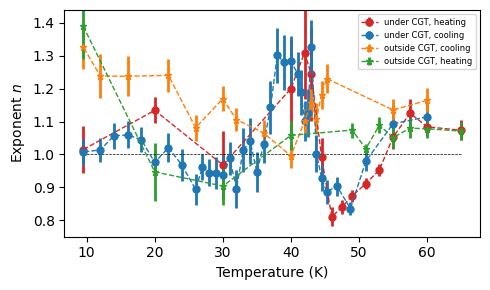

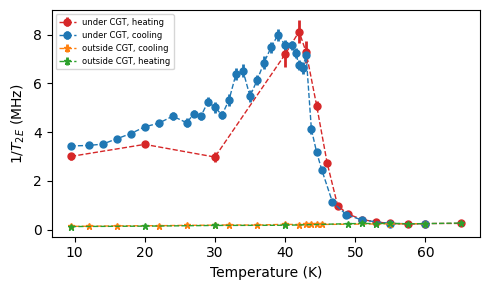

In [523]:
fig,ax=plt.subplots(figsize=(5,3)); factor=1e3
ax.errorbar(temp_on_up, n_on_up, n_err_on_up,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="under CGT, heating")
ax.errorbar(temp_on_down, n_on_down, n_err_on_down,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, cooling")
ax.errorbar(temp_off_down, n_off_down, n_err_off_down,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT, cooling")
ax.errorbar(temp_off_up, n_off_up, n_err_off_up,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="outside CGT, heating")

# xlim1 = ax.get_xlim()
# ylim1 = ax.get_ylim()
ax.set_xlim(xlim1)
ax.set_ylim(ylim1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Exponent $n$')
ax.legend(fontsize=6,loc='upper right')
ax.hlines(y=1,xmin=min(temp_on_down),xmax=max(temp_on_up),linestyle='--',color='k',linewidth=0.5)
plt.tight_layout()

fig,ax=plt.subplots(figsize=(5,3)); factor=1e3

ax.errorbar(temp_on_up,1/t2e_on_up*factor,t2e_err_on_up/t2e_on_up**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="under CGT, heating")
ax.errorbar(temp_on_down,1/t2e_on_down*factor,t2e_err_on_down/t2e_on_down**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, cooling")
ax.errorbar(temp_off_down,1/t2e_off_down*factor,t2e_err_off_down/t2e_off_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT, cooling")
ax.errorbar(temp_off_up,1/t2e_off_up*factor,t2e_err_off_up/t2e_off_up**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="outside CGT, heating")
# ax.set_yscale('log')

# xlim2 = ax.get_xlim()
# ylim2 = ax.get_ylim()
ax.set_xlim(xlim2)
ax.set_ylim(ylim2)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$1/T_{2E}$ (MHz)')
ax.legend(fontsize=6,loc='upper left')
plt.tight_layout()

## Temp sweep

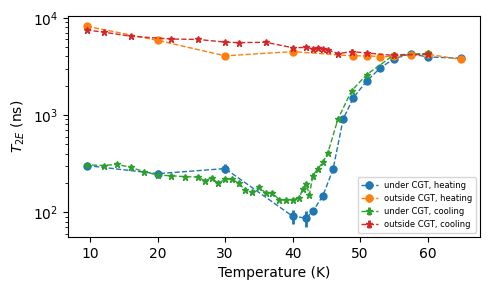

In [137]:
temp_onFlake   = np.array((9.5, 20,  30,  40, 42, 43,  44.5, 46,  47.5, 49,   51,   53,   55,   57.5, 60,   65,))#   120))
T2E_onFlake    = np.array((302, 249, 281, 91, 87, 102, 148,  277, 907,  1503, 2239, 3041, 3784, 4251, 3951, 3830,))# 4028 ))
T2EErr_onFlake = np.array((21,  20,  30,  15, 16, 6,   9,    14,  18,   30,   37,   43,   75,   93,   46,   49,))#   33))
temp_offFlake   = np.array((9.5,  20,   30,   40,   49,   51,   53,   55,   57.5, 60,   65))
T2E_offFlake    = np.array((8163, 5853, 4054, 4483, 4042, 4073, 3969, 4007, 4178, 4216, 3718))
T2EErr_offFlake = np.array((113,  153,  183,  94,   47,   52,   73,   128,  84,   114,  94))

if False:
    temp_on_down   = np.array((60,   55,   51,   48.75, 46.75, 45.25, 44.5, 43.75, 43,  42.5,42, 41.5,41, 40,39,38,37,36, 35, 34,33,32,31, 30, 29, 28, 27, 26, 24, 22, 20, 18, 16, 14, 12, 9.5))
    T2E_on_down    = np.array((4202, 3910, 2198, 1524,  765,   310,   249,  169,   105, 106, 107,102, 101,95,83,95,82,119,104,87,85,94,151,161,144,176,189,171,196,227,239,247,276,282,280,286))
    T2EErr_on_down = np.array((73,   78,   51,   36,    18,    15,    13,   14,    7,   5,   7,  4,   6,  5, 7, 6, 9, 6,  6,  10,11,12,10, 16, 10, 11, 8,  14, 12, 11, 10, 10, 11, 11, 12, 13))
if True:
    # Column 1
    temp1 = np.array([60, 55, 51, 48.75, 46.75, 45.25, 44.5, 43.75, 43, 42.5, 42, 41.5, 41, 40, 39])
    T2E1 = np.array([4286., 4140, 2604, 1776, 918, 411, 326, 280, 238, 152, 195, 173, 141, 135, 133])
    T2EErr1 = np.array([122.0, 166, 69, 54, 31, 16, 13, 17, 18, 6, 9, 7, 5, 4, 5])

    # Column 2
    temp2 = np.array([38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 24, 22])
    T2E2 = np.array([135.0, 158, 158, 181, 160, 168, 198, 220, 218, 198, 226, 210, 230, 232, 237])
    T2EErr2 = np.array([4.000, 7, 5, 8, 7, 8, 10, 8, 10, 7, 7, 6, 9, 9, 8])

    # Column 3
    temp3 = np.array([20, 18, 16, 14, 12, 9.5])
    T2E3 = np.array([241, 261, 289, 311, 302, 307])
    T2EErr3 = np.array([7, 7, 9, 9, 9, 10])

    # Merge into single arrays
    temp_on_down = np.concatenate([temp1, temp2, temp3])
    T2E_on_down = np.concatenate([T2E1, T2E2, T2E3])
    T2EErr_on_down = np.concatenate([T2EErr1, T2EErr2, T2EErr3])

temp_off_down   = np.array((60,   55,   51,   48.75, 46.75, 45.25, 44.5, 43.75, 43,  42,  40,   36,  32,  30,  26,  22,  16,  12,  9.5))
T2E_off_down    = np.array((4221, 4096, 4337, 4477,  4278,  4653,  4780, 4839,  4807,4941,4917, 5592,5538,5613,5975,6038,6451,7110,7461))
T2EErr_off_down = np.array((82,   62,   113,  259,   172,   113,   117,  187,   135, 116, 149,  172, 165, 154, 168, 169, 211, 199, 172))

temp_on_down_n1   = np.array((60,  55,  51,  48.75,46.75,45.25,44.5,43.75,43, 42.5,42, 41.5,41, 40, 39,38, 37, 36,  35,  34,  33,  32, 31, 30, 29, 28, 27, 26, 24, 22, 20, 18, 16, 14, 12, 9.5))
T2E_on_down_n1    = np.array((4199,3910,2229,1533, 800,  356,  281, 204,  117,117, 130,110, 108,105,96,103,113,130, 129, 116, 130, 149,175,165,165,198,192,196,197,224,236,250,276,285,279,288))
T2EErr_on_down_n1 = np.array((73,  78,  52,  37,   18,   12,   10,  10,   7,  4,   5,  4,   5,  4,  5, 5,  6,  5,   4,   6,   7,   8,  7,  9,  7,  8,  6,  9,  9,  9,  8,  9,  11, 11, 12, 13))

if True:
    fig,ax=plt.subplots(figsize=(5,3))
    ax.errorbar(temp_onFlake,T2E_onFlake,T2EErr_onFlake,
                marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, heating")
    ax.errorbar(temp_offFlake,T2E_offFlake,T2EErr_offFlake,
                marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT, heating")
    ax.errorbar(temp_on_down,T2E_on_down,T2EErr_on_down,
                marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="under CGT, cooling")
    ax.errorbar(temp_off_down,T2E_off_down,T2EErr_off_down,
                marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="outside CGT, cooling")
    # ax.errorbar(temp_on_down_n1,T2E_on_down_n1,T2EErr_on_down_n1,
    #             marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C4',label="under CGT, cooling,n=1")
    

    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('$T_{2E}$ (ns)')
    ax.set_yscale('log')
    ax.legend(fontsize=6,loc='lower right')
    plt.tight_layout()

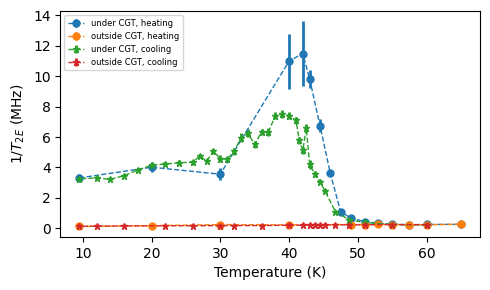

In [138]:
fig,ax=plt.subplots(figsize=(5,3)); factor=1e3
ax.errorbar(temp_onFlake,1/T2E_onFlake*factor,T2EErr_onFlake/T2E_onFlake**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, heating")
ax.errorbar(temp_offFlake,1/T2E_offFlake*factor,T2EErr_offFlake/T2E_offFlake**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT, heating")
ax.errorbar(temp_on_down,1/T2E_on_down*factor,T2EErr_on_down/T2E_on_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="under CGT, cooling")
ax.errorbar(temp_off_down,1/T2E_off_down*factor,T2EErr_off_down/T2E_off_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="outside CGT, cooling")
# ax.errorbar(temp_on_down_n1,1/T2E_on_down_n1*factor,T2EErr_on_down_n1/T2E_on_down_n1**2*factor,
#             marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C4',label="under CGT, cooling, n=1")

T2E_offItp = np.interp(temp_onFlake, temp_offFlake, T2E_offFlake)
T2EErr_offItp = np.interp(temp_onFlake, temp_offFlake, T2EErr_offFlake)
# ax.errorbar(temp_onFlake,(1/T2E_onFlake-1/T2E_offItp)*factor,
#             (T2EErr_offItp/T2E_offItp**2 + T2EErr_onFlake/T2E_onFlake**2)*factor,
#             marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="outside CGT, heating")
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$1/T_{2E}$ (MHz)')
# ax.set_yscale('log')
ax.legend(fontsize=6,loc='upper left')
plt.tight_layout()

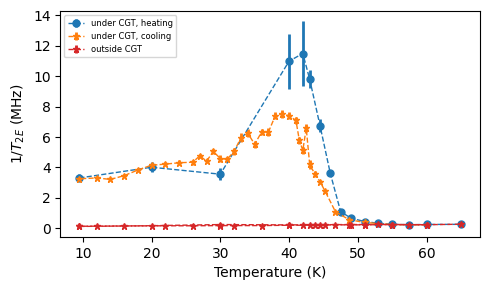

In [140]:
fig,ax=plt.subplots(figsize=(5,3)); factor=1e3
ax.errorbar(temp_onFlake,1/T2E_onFlake*factor,T2EErr_onFlake/T2E_onFlake**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, heating")
# ax.errorbar(temp_on_down_n1,1/T2E_on_down_n1*factor,T2EErr_on_down_n1/T2E_on_down_n1**2*factor,
#             marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="under CGT, cooling")
ax.errorbar(temp_on_down,1/T2E_on_down*factor,T2EErr_on_down/T2E_on_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="under CGT, cooling")

ax.errorbar(temp_offFlake,1/T2E_offFlake*factor,T2EErr_offFlake/T2E_offFlake**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="outside CGT")
ax.errorbar(temp_off_down,1/T2E_off_down*factor,T2EErr_off_down/T2E_off_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label=None)

T2E_offItp = np.interp(temp_onFlake, temp_offFlake, T2E_offFlake)
T2EErr_offItp = np.interp(temp_onFlake, temp_offFlake, T2EErr_offFlake)
# ax.errorbar(temp_onFlake,(1/T2E_onFlake-1/T2E_offItp)*factor,
#             (T2EErr_offItp/T2E_offItp**2 + T2EErr_onFlake/T2E_onFlake**2)*factor,
#             marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="outside CGT, heating")
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$1/T_{2E}$ (MHz)')
# ax.set_yscale('log')
ax.legend(fontsize=6,loc='upper left')
plt.tight_layout()

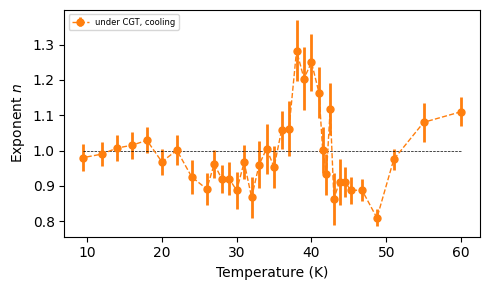

In [136]:
if False:
    temp_n = np.array([
        60, 55, 51, 48.75, 46.75, 45.25, 44.5, 43.75, 43,
        42.5, 42, 41.5, 41, 40, 39,
        38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 24, 22,
        20, 18, 16, 14, 12, 9.5
    ])

    n = np.array([
        1.164, 1.174, 0.908, 0.756, 0.777, 0.660, 0.685, 0.647, 0.396,
        0.745, 0.594, 0.613, 0.799, 0.814, 0.766,
        0.893, 0.664, 0.759, 0.592, 0.609, 0.548, 0.499, 0.694, 0.599, 0.625, 0.731, 0.710, 0.614, 0.734, 0.860,
        0.934, 0.963, 1.062, 1.079, 1.026, 1.023
    ])

    n_err = np.array([
        0.059, 0.082, 0.030, 0.019, 0.024, 0.021, 0.046, 0.054, 0.050,
        0.062, 0.056, 0.047, 0.064, 0.074, 0.069,
        0.084, 0.079, 0.069, 0.048, 0.065, 0.062, 0.076, 0.070, 0.088, 0.067, 0.075, 0.062, 0.087, 0.094, 0.091,
        0.092, 0.084, 0.098, 0.097, 0.091, 0.102
    ])

if True:
    # Column 1
    temp_1 = np.array([60, 55, 51, 48.75, 46.75, 45.25, 44.5, 43.75, 43, 42.5, 42, 41.5, 41, 40, 39])
    n_1    = np.array([1.110, 1.080, 0.975, 0.809, 0.888, 0.887, 0.911, 0.912, 0.863, 1.117, 0.933, 1.001, 1.164, 1.250, 1.204])
    nerr_1 = np.array([0.041, 0.055, 0.030, 0.024, 0.032, 0.038, 0.042, 0.065, 0.073, 0.074, 0.058, 0.066, 0.073, 0.080, 0.089])

    # Column 2
    temp_2 = np.array([38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 24, 22])
    n_2    = np.array([1.283, 1.062, 1.058, 0.953, 1.005, 0.960, 0.867, 0.967, 0.887, 0.920, 0.920, 0.962, 0.891, 0.925, 1.001])
    nerr_2 = np.array([0.086, 0.078, 0.054, 0.060, 0.071, 0.067, 0.057, 0.048, 0.053, 0.047, 0.039, 0.040, 0.046, 0.047, 0.043])

    # Column 3
    temp_3 = np.array([20, 18, 16, 14, 12, 9.5])
    n_3    = np.array([0.968, 1.029, 1.015, 1.007, 0.990, 0.980])
    nerr_3 = np.array([0.036, 0.037, 0.038, 0.036, 0.035, 0.038])

    # Merge into single arrays
    temp_n = np.concatenate([temp_1, temp_2, temp_3])
    n      = np.concatenate([n_1, n_2, n_3])
    n_err  = np.concatenate([nerr_1, nerr_2, nerr_3])


fig,ax=plt.subplots(figsize=(5,3)); factor=1e3
ax.errorbar(temp_n, n, n_err,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="under CGT, cooling")

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Exponent $n$')
ax.legend(fontsize=6,loc='upper left')
ax.hlines(y=1,xmin=min(temp_n),xmax=max(temp_n),linestyle='--',color='k',linewidth=0.5)
plt.tight_layout()

# Confocal T2E just one tau

In [561]:
dataArr = []; ifSingleGreenRead=1
month = 8; days = np.linspace(1,31,31); count=0; ifYCountDown=1
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-0'+str(month)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalT2E'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = (day==20 and idx==27)
                batch2 = (day==24 and idx>=13)
                if batch1:  
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,tau,sig,ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
                    sig = np.array(sig); ref = np.array(ref); contrast = (sig-ref)/(sig+ref)
                    x = np.array(x); y = np.array(y)
                    (ny,nx,ntau) = np.shape(sig)
                    dataArr.append(contrast)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
dataArr = np.array(dataArr); print(np.shape(dataArr))
dataArr = np.average(dataArr, axis=0)
convfactor = 2*0.028*1e6; conv_voltage=10

(1, 21, 14, 1)


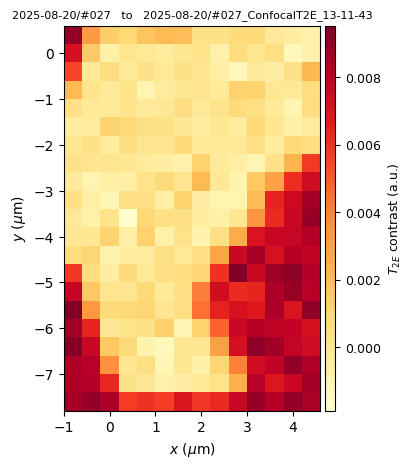

In [562]:
# 2D     
X = x[:,:,0]*conv_voltage; Y = y[:,:,0]*conv_voltage
fig, ax = plt.subplots(figsize=(5,5))

# plot = ax.pcolormesh(X,Y, dataArr[:,:,0], cmap='YlOrRd')
plot = ax.pcolormesh(X,Y, dataArr[:,:,0], cmap='YlOrRd')
    
ax.set_aspect(1)
# plot = ax.pcolormesh(X,Y, np.min(dataArr,axis=2), cmap='inferno')
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
cbar = fig.colorbar(plot, cax = cax)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$T_{2E}$ contrast (a.u.)', fontsize=9)
a = 0.014
# plot.set_clim(-0.002,a)

ax.set_xlabel('$V_x$ (V)')
ax.set_ylabel('$V_y$ (V)')

ax.set_xlabel('$x$ ($\mu$m)')
ax.set_ylabel('$y$ ($\mu$m)')
sp = 0.005*conv_voltage
# for j in range(ny):
#     for i in range(nx):
#         if dataArr[j,i]>=0.005:
#             ax.add_patch(plt.Rectangle((X[0][i]-sp/2, Y[j][0]-sp/2), sp, sp, color='black'))

s = firstdatafile[31:46] + '   to   ' + datafile[31:67]
ax.set_title(s,fontsize=8)

plt.tight_layout;
mask = dataArr[:,:,0]>=0.006
mask = np.flip(mask,axis=0)
# np.shape(mask)
# for (j,i), val in np.ndenumerate(mask):
#     print(j)

In [ ]:
x_1D = np.round(x[0,:,0],2); y_1D = np.round(y[:,0,0],2)
T2EDict = {}
for j in range(ny):
    for i in range(nx):
        T2EDict[(x_1D[i],y_1D[j])] = float(dataArr[j,i])

for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-0'+str(month)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            idx = int(dataFolder[1:4])
            batch1 = (day==20 and idx==27)
            batch2 = (day==24 and idx>=13)
            if batch2:  
                savedDictFile = mainFolder + dataFolder + '/T2EDict_20K.pkl'
    except:pass

# with open(sdumpavedDictFile, 'wb') as f:
#     pickle.(T2EDict, f)


In [96]:
with open(savedDictFile, 'rb') as f:
    loaded_dict = pickle.load(f)
loaded_dict

{(-0.08, 0.04): 0.010007411472651885,
 (-0.04, 0.04): 0.009582332560085966,
 (0.0, 0.04): 0.0066668374427976095,
 (0.04, 0.04): 0.00835933051890394,
 (0.08, 0.04): 0.006926663893090783,
 (0.12, 0.04): 0.0076892100399129585,
 (0.16, 0.04): 0.007320482968321799,
 (0.2, 0.04): 0.008268707779372733,
 (0.24, 0.04): 0.007156568900565959,
 (0.28, 0.04): 0.006494980069645415,
 (0.32, 0.04): 0.0038904663702085604,
 (-0.08, 0.0): 0.008790327448150248,
 (-0.04, 0.0): 0.00782732977150641,
 (0.0, 0.0): 0.008625521198860916,
 (0.04, 0.0): 0.008041859492485207,
 (0.08, 0.0): 0.0076260939002327265,
 (0.12, 0.0): 0.007062282957707402,
 (0.16, 0.0): 0.006873193730453478,
 (0.2, 0.0): 0.005160293104648344,
 (0.24, 0.0): 0.002600449399815903,
 (0.28, 0.0): 0.00045291924330701975,
 (0.32, 0.0): -0.00042638392386690573,
 (-0.08, -0.04): 0.006413152602212065,
 (-0.04, -0.04): 0.0033983839777841345,
 (0.0, -0.04): 0.0016410725532524247,
 (0.04, -0.04): 0.002102680988175805,
 (0.08, -0.04): 0.00281279815181689

# T2R

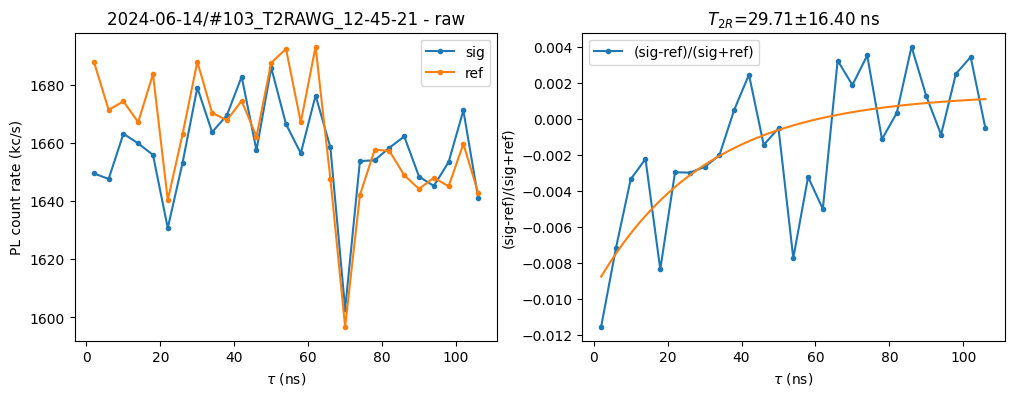

In [40]:
type = 'T2RAWG'
month = 6; days=np.linspace(1,14,14)
month = 7; days=np.linspace(1,1,1)
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2024-0'+str(month)+'-' + str(int(day)).zfill(2) + '/'
    for dataFolder in os.listdir(mainFolder):
        if type in dataFolder:
            idx = int(dataFolder[1:4])
            if day==1 and idx >= 22:
                datafile = mainFolder + dataFolder +'/T2RAWGObject_sig_set.dat'
                guess = (-0.01,17,0.1)
                sig, ref, popt, perr, x_s = dr.readData(datafile, type='T2R', typeNorm=Q_FINAL, ifFit=1, guess=guess)

(0.0, 100.0)

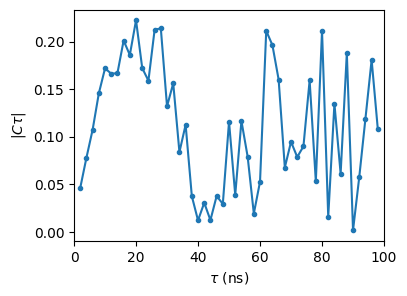

In [48]:
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(x_s, np.abs((sig-ref)/(sig+ref))*x_s,'o-', markersize=3,)
ax.set_ylabel('$|C\\tau|$')
ax.set_xlabel('$\\tau$ (ns)')

ax.set_xlim((0,100))
# ax.set_ylim((0,0.2))

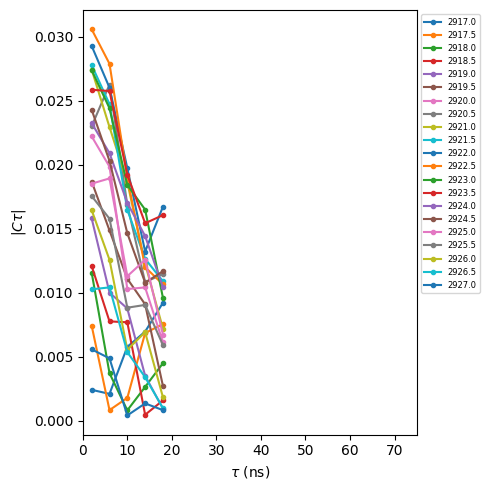

In [110]:
sigs = []; refs= []; xs = []
# freqs = np.linspace(2842e6,2843e6,11)
freqs = np.linspace(2841e6,2844e6,31) #240613 DS51-81
freqs = np.linspace(2839e6, 2849e6, 21) #240614 DS 28-48
freqs = np.linspace(2917e6, 2927e6, 21) #240614 DS 50-70

type = 'T2RAWG'
month = 6; days=np.linspace(1,14,14)
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2024-0'+str(month)+'-' + str(int(day)).zfill(2) + '/'
    for dataFolder in os.listdir(mainFolder):
        if type in dataFolder:
            idx = int(dataFolder[1:4])
            # if day==13 and idx >= 51 and idx <= 81:
            # if day==14 and idx >= 28 and idx <= 48:
            if day==14 and idx >= 72 and idx <= 92:
                datafile = mainFolder + dataFolder +'/T2RAWGObject_sig_set.dat'
                guess = (-0.01,17,0.1)
                sig, ref, popt, perr, x_s = dr.readData(datafile, type='T2R', typeNorm=Q_FINAL, ifPlot=0,ifFit=1, guess=guess)
                sigs.append(sig); refs.append(ref); xs.append(x_s)

fig, ax = plt.subplots(figsize=(5,5))          
for i in range(len(sigs)):    
    ax.plot(xs[i], np.abs((sigs[i]-refs[i])/(sigs[i]+refs[i])),'o-', markersize=3,label=str(freqs[i]/1e6))
ax.set_ylabel('$|C\\tau|$')
ax.set_xlabel('$\\tau$ (ns)')

ax.set_xlim((0,75))
# ax.set_ylim((0.45,0.65))
ax.legend(loc='upper left', bbox_to_anchor=(1, 1),fontsize=6)
plt.subplots_adjust(right=0.75)
plt.tight_layout()


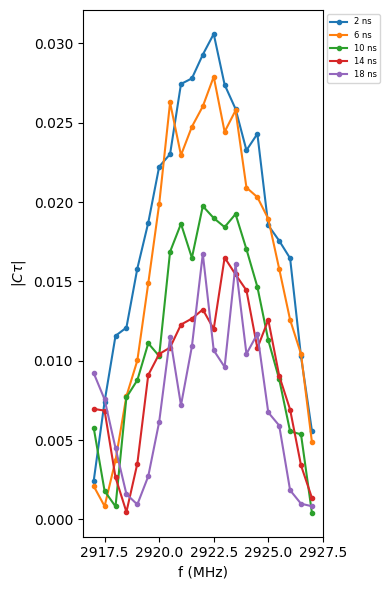

In [114]:
i = 1
sigs = np.array(sigs); refs = np.array(refs); xs = np.array(xs)
fig, ax = plt.subplots(figsize=(4,6))       
for i in range(5):
       
    ax.plot(freqs/1e6, np.abs((sigs[:,i]-refs[:,i])/(sigs[:,i]+refs[:,i])) + 0*i,'o-', markersize=3,label='%.0f ns' %(xs[0,i]))
    ax.set_ylabel('$|C\\tau|$')
    ax.set_xlabel('f (MHz)')

    # ax.set_xlim((0,75))
    # ax.set_ylim((0.45,0.65))
ax.legend(loc='upper left', bbox_to_anchor=(1, 1),fontsize=6)
plt.subplots_adjust(right=0.75)
plt.tight_layout()


array([ 0.14545158,  1.42126683,  1.64565724,  0.27326166,  0.69532761,
       -0.47088415,  0.25295856,  0.78354495, -1.03801558,  0.01000018,
        0.62360239, -2.19617566, -0.36610831])

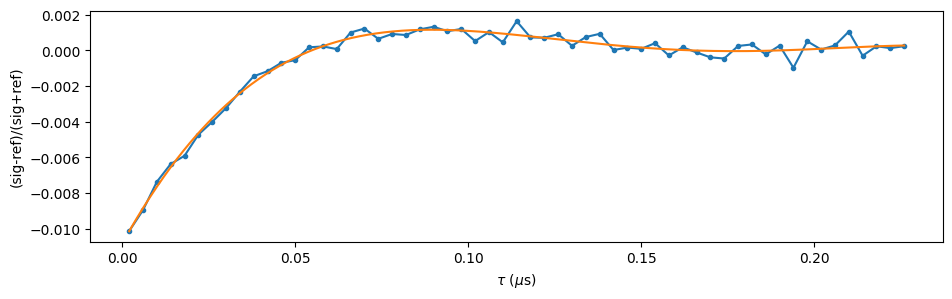

In [233]:
fig, ax = plt.subplots(figsize=(11,3))
x = x_s
y = (sig-ref)/(sig+ref)

ax.plot(x/1e3,y, 'o-', markersize=3,)
ax.set_xlabel(r"$\tau$ ($\mu$s)")
ax.set_ylabel('(sig-ref)/(sig+ref)')
# ax.set_yscale('log')
# ax.set_xscale('log')

guess = (0.05, 1.1494, 0,    0.05, 0.995, 0,    0.05, 3.4483, -pi,   0.05, 3.3483, -pi, 0)
# ax.plot(x/1e3, dr.cosThree(x/1e3, *guess),  'o-', markersize=3,color='C2')
lowerBounds = (0.01,0,-pi,   0.01,0,-pi,   0.01,0,-pi,  0.01,0,-pi, -1)
upperBounds = (1,2, 7*pi,   1,4,6*pi,    1,4, 5*pi,  1,4, 5*pi, 1)
xfit, yfit, popt, perr = dr.fitCosFour(x/1e3, y, guess=guess, lowerBounds=lowerBounds)
ax.plot(xfit, yfit, color='C1')
popt
# ax.set_title(r'$T_{2E}$ = %.2f $\pm$ %.2f $\mu$s; $n$ = %.2f $\pm$ %.2f' % (popt[1], perr[1], popt[2], perr[2]))
# ax.set_xlim((-0.1,10.1))

In [ ]:
fittedPeaks = np.array((np.round(popt[1],4),np.round(popt[4],4),np.round(popt[7],4),np.round(popt[10],4)))
print("Fitted peaks (MHz)", fittedPeaks)

In [ ]:
yfourier = np.fft.fft(y-np.average(y)); yfourier = np.abs(yfourier)
f = np.fft.fftfreq(len(y), 10e-9)/1e6

sorted_indices = np.argsort(f)       # Get the indices that would sort f
f = f[sorted_indices]                # Sort f in ascending order
yfourier = yfourier[sorted_indices]  # Reorder yfourier based on the sorted_indices

# Plot the signal and its Fourier Transform
fig, axs = plt.subplots(2,1, figsize=(12,6))
axs[0].plot(x/1e3,y, 'o-', markersize=3,)
axs[0].set_xlabel(r"$\tau$ ($\mu$s)")
axs[0].set_ylabel('(sig-ref)/(sig+ref)')

axs[1].plot(f, yfourier, linestyle='-', marker='o', markersize=3, color='C1')
axs[1].set_title('')
axs[1].set_xlabel('Frequency (MHz)')
axs[1].set_ylabel('Fourier Transform')
axs[1].set_xlim((-5,5))

def find_peaks(data, threshold=0):
    peaks = []
    for i in range(1, len(data) - 1):
        if data[i] > data[i - 1] and data[i] > data[i + 1] and data[i] > threshold:
            peaks.append(i)
    return peaks

threshold = 11
peaks = find_peaks(yfourier, threshold=threshold)
fpeaks = f[peaks]; fpeaks = fpeaks[int(len(fpeaks)/2):]
print(np.round(fpeaks*1e3,1))

axs[1].hlines(y=threshold, xmin=min(f), xmax=max(f), linestyle='--', linewidth = 1)

plt.tight_layout()
plt.show()

# T2R 4 point

In [170]:
type = 'T2R4point'
month = 8; days=np.linspace(1,31,31); count=0; ifFit=0; ifPlot=0
dataArr = []; sigArr = []; refArr = []; ref2Arr = []; ref3Arr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-0'+str(month)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = day==13 and idx<=13
                if batch1:
                    datafile = mainFolder + dataFolder +'/' + type +'Object_sig_set.dat'
                    guess = (-0.03, 0, 17)
                    # guess = (-0.018, 200, 0, 0, 200); ifFit=2 #(t, A, Tpi, phi,C, T2)
                    sig, ref, ref2,ref3,popt, perr, x_s = dr.readData4point(datafile,  ifPlot=ifPlot,
                                                        type='T2R', typeNorm=Q_FINAL, ifFit=ifFit, guess=guess)
                    # print(popt)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]
                    ref2 = ref2[sorted_indices]
                    ref3 = ref3[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)
                    ref2Arr.append(ref2); ref3Arr.append(ref3)
                    
                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    ref2Arr = np.array(ref2Arr); ref3Arr = np.array(ref3Arr)
    print(np.shape(dataArr))

(3, 50)


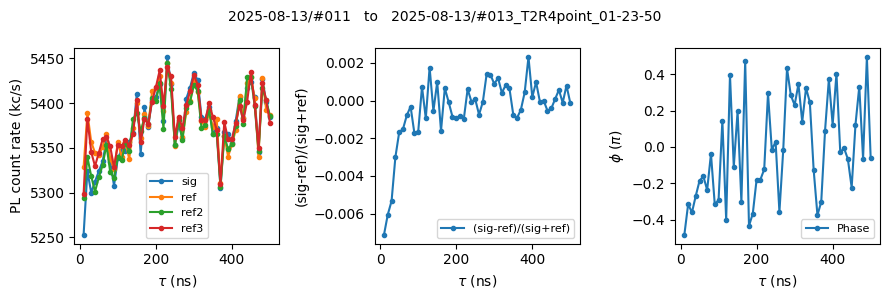

In [173]:
ifFit=1
if True:
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(9,3))
    fontsize=8

    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    yr2 = np.nanmean(ref2Arr[start:end], axis=0)
    yr3 = np.nanmean(ref3Arr[start:end], axis=0)
    
    axs[0].plot(x_s, sig, 'o-', markersize=3, label='sig', color='C0')
    axs[0].plot(x_s, ref, 'o-', markersize=3, label='ref', color='C1')
    axs[0].plot(x_s, ref2, 'o-', markersize=3, label='ref2', color='C2')
    axs[0].plot(x_s, ref3, 'o-', markersize=3, label='ref3', color='C3')
    axs[0].legend(loc='best',fontsize=fontsize)
    axs[0].set_xlabel(r"$\tau$ (ns)")
    axs[0].set_ylabel("PL count rate (kc/s)")
    
    axs[1].plot(x_s, ((sig-ref)/(sig+ref)), 'o-', markersize=3, label='(sig-ref)/(sig+ref)', color='C0')
    axs[1].set_ylabel('(sig-ref)/(sig+ref)')
    axs[1].legend(loc='best',fontsize=fontsize)
    axs[1].set_xlabel(r"$\tau$ (ns)")

    phase = np.arctan((sig-ref)/np.abs(ref2-ref3))/np.pi
    axs[2].plot(x_s, phase, 'o-', markersize=3, label='Phase', color='C0')
    axs[2].set_ylabel('$\phi$ ($\pi$)')
    axs[2].legend(loc='best',fontsize=fontsize)
    axs[2].set_xlabel(r"$\tau$ (ns)")

    s = firstdatafile[31:46] + '   to   ' + datafile[31:65]
    fig.suptitle(s,fontsize=10)
    # fig.suptitle(datafile.split('/')[4] + "/" + datafile.split('/')[5] + " - normalized", fontsize=fontsize+2)

if ifFit==1:
    fitFunc = dr.fitDecay

    y = ((sig-ref)/(sig+ref)); 

    xfit, yfit, popt, perr = fitFunc(x_s, y, guess=guess)
    if ifPlot:
        axs[1].plot(xfit, yfit, color='C1')
        s = "$T_{2R}$=%.2f$\pm$%.2f ns" % (popt[2], perr[2])
        axs[1].set_title(s, fontsize=fontsize+2)    
    
        idxs = np.where(x_s < 2.5*popt[2])[0]
        axs[2].plot(x_s[idxs], phase[idxs], 'o-', markersize=3, label='Phase', color='C0')
        axs[2].set_ylim((-0.55,0))
        # axs[2].set_xlim(/(-1,2.5*popt[2]))
elif ifFit==2:
    fitFunc = fitSinusoidDecay
    # (t, A, Tpi, phi,C, T2)

    y = ((sig-ref)/(sig+ref)); 

    xfit, yfit, popt, perr = fitFunc(x_s, y, guess=guess)
    if ifPlot:
        axs[1].plot(xfit, yfit, color='C1')
        s = "$T_{2R}$=%.2f$\pm$%.2f ns" % (popt[4], perr[4])
        axs[1].set_title(s, fontsize=fontsize+2)    
    
        idxs = np.where(x_s < 2.5*popt[2])[0]
        axs[2].plot(x_s[idxs], phase[idxs], 'o-', markersize=3, label='Phase', color='C0')
        axs[2].set_ylim((-0.55,0))
        # axs[2].set_xlim(/(-1,2.5*popt[2]))

plt.tight_layout()


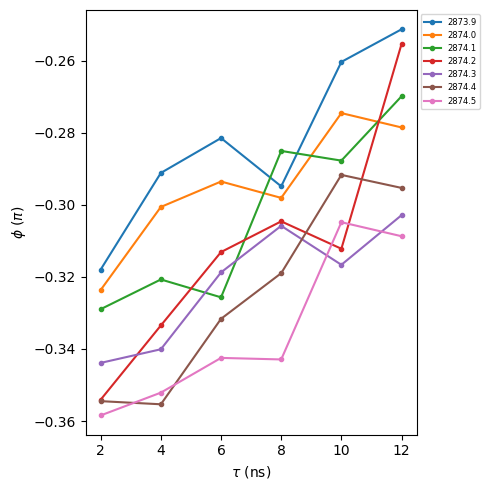

In [26]:
sigs = []; refs= []; xs = []; ref2s = []; ref3s = []
# freqs = np.linspace(2873.3e6, 2873.9e6, 7) #240702 DS 18-24
f = 2874.2e6; freqs = np.linspace(f-3e5, f+3e5, 7)
f = 2874.2e6; freqs = np.linspace(f-3e5, f+3e5, 7)
type = 'T2R4point'
month = 7; days=np.linspace(1,2,2)
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2024-0'+str(month)+'-' + str(int(day)).zfill(2) + '/'
    for dataFolder in os.listdir(mainFolder):
        if type in dataFolder:
            idx = int(dataFolder[1:4])
            if day==2 and idx >= 34 and idx <= 40:
                datafile = mainFolder + dataFolder +'/T2R4pointObject_sig_set.dat'
                guess = (-0.03, 0, 17); ifFit=1
                guess = (-0.018, 200, 0, 0, 200); ifFit=0 #(t, A, Tpi, phi,C, T2)
                sig, ref, ref2, ref3, popt, perr, x_s = dr.readData4point(datafile, ifPlot=0,
                                                       type='T2R', typeNorm=Q_FINAL, ifFit=ifFit, guess=guess)
                sigs.append(sig); refs.append(ref); xs.append(x_s); ref2s.append(ref2); ref3s.append(ref3)

fig, ax = plt.subplots(figsize=(5,5))          
for i in range(len(sigs)):    
    phase = np.arctan((sigs[i]-refs[i])/(ref2s[i]-ref3s[i]))/np.pi
    for j, phi in enumerate(phase):
        if j >=15 and phi < 0:
            phase[j] = phi+1
    ax.plot(xs[i], phase,'o-', markersize=3,label=str(freqs[i]/1e6));
ax.set_ylabel('$\phi$ ($\pi$)')
ax.set_xlabel('$\\tau$ (ns)')

# ax.set_xlim((0,40))
# ax.set_ylim((-0.4,0))
ax.legend(loc='upper left', bbox_to_anchor=(1, 1),fontsize=6)
plt.subplots_adjust(right=0.75)
plt.tight_layout()


# T1

(3, 16)
[-6.98005600e-03  8.34718281e-04  8.04481611e+01  9.44553997e-01]


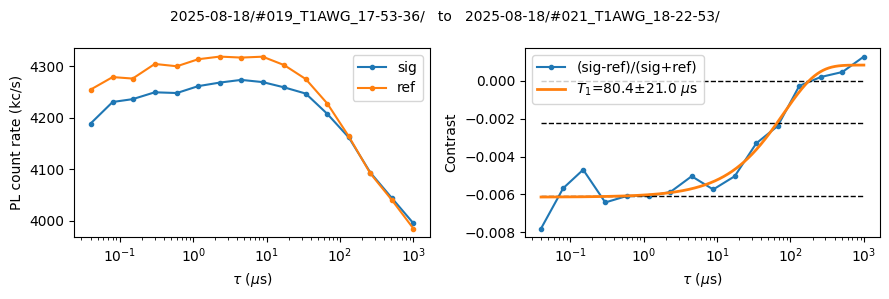

In [235]:
# Multiple, with 1/e marking
days = np.linspace(1,31,31); count=0; ifLog=1; ifFit=1
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-08-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'T1AWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = day==1 and idx<=7
                batch2 = day==18 and idx>=19 and idx<=21
                if batch2:
                    datafile = mainFolder + dataFolder +'/T1AWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = xPlot/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    axs[1].hlines(y=0, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    ymax = np.average(y[0:3])
    axs[1].hlines(y=ymax, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=ymax/np.e, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    # axs[1].vlines(x=4.2e3, ymin=min(y), ymax=max(y), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau$ ($\mu$s)')
    
    s = firstdatafile[31:62] + '   to   ' + datafile[31:62]
    fig.suptitle(s,fontsize=10)

    if ifFit:
        guess = (0.015,  0,  5e2,  1)
        lowerBounds = None# (-np.pi, -1e-7, 0,      0)
        xfit, yfit, popt, perr = dr.fitStrDecay(x, y, guess=guess, logx=1, lowerBounds=lowerBounds)
        print(popt)
        s = '$T_{1}$=%.1f$\pm$%.1f $\mu$s' % (popt[2], perr[2])
        axs[1].plot(xfit, yfit, '-', linewidth=2,color='C1',label=s)

    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    plt.tight_layout()

(1, 16)
[-1.17361082e-02 -3.18470379e-04  1.71566001e+03]


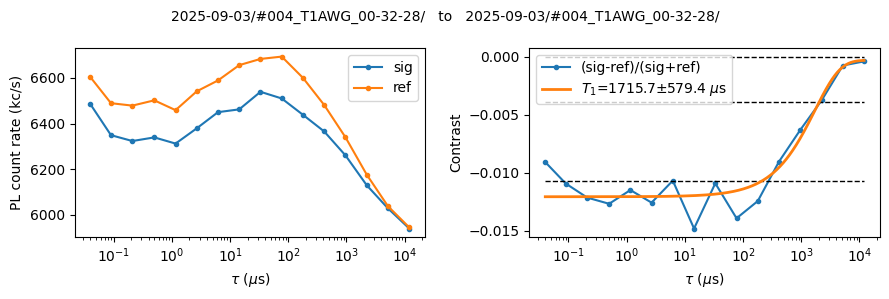

In [4047]:
# Multiple, with 1/e marking
days = np.linspace(1,31,31); count=0; ifLog=1; ifFit=1
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-09-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'T1AWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = day==1 and idx<=7
                batch2 = day==3 and idx>-8 and idx<=234
                if batch2:
                    datafile = mainFolder + dataFolder +'/T1AWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = xPlot/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    axs[1].hlines(y=0, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    ymax = np.average(y[0:3])
    axs[1].hlines(y=ymax, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=ymax/np.e, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    # axs[1].vlines(x=4.2e3, ymin=min(y), ymax=max(y), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau$ ($\mu$s)')
    
    s = firstdatafile[31:62] + '   to   ' + datafile[31:62]
    fig.suptitle(s,fontsize=10)

    if ifFit:
        guess = (0.015,  0,  5e2)
        xfit, yfit, popt, perr = dr.fitDecay(x, y, guess=guess, logx=1)
        print(popt)
        s = '$T_{1}$=%.1f$\pm$%.1f $\mu$s' % (popt[2], perr[2])
        axs[1].plot(xfit, yfit, '-', linewidth=2,color='C1',label=s)

    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    plt.tight_layout()

(3, 16)
0.9401208499543524


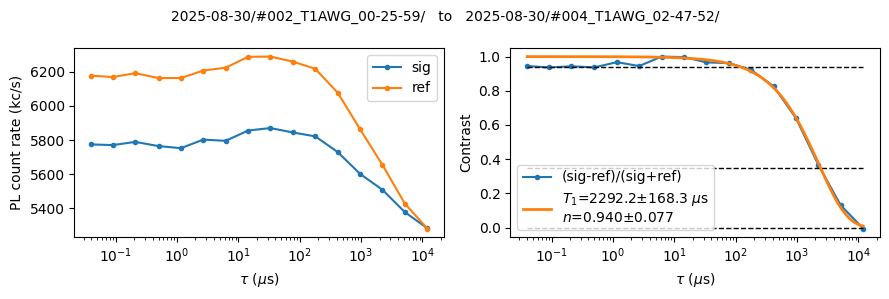

In [279]:
# Multiple, with 1/e marking
days = np.linspace(1,31,31); count=0; ifLog=1; ifFit=1
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-08-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'T1AWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = day==2 and idx==16
                batch2 = day==30 and idx>=2 and idx<=4
                if batch2:
                    datafile = mainFolder + dataFolder +'/T1AWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    y = y/np.min(y)

    # y = y - np.average(y[-2:])
    # y = y/np.average(y[0:3])
    
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = xPlot/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    axs[1].hlines(y=0, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    ymax = np.average(y[0:3])
    axs[1].hlines(y=ymax, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=ymax/np.e, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    # axs[1].vlines(x=4.2e3, ymin=min(y), ymax=max(y), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau$ ($\mu$s)')
    
    s = firstdatafile[31:62] + '   to   ' + datafile[31:62]
    fig.suptitle(s,fontsize=10)

    # if ifFit:
    #     guess = (0.015,  0,  5e2,  1)
    #     lowerBounds = None# (-np.pi, -1e-7, 0,      0)
    #     xfit, yfit, popt, perr = dr.fitStrDecay(x, y, guess=guess, logx=1, lowerBounds=lowerBounds)
    #     print(popt)
    #     s = '$T_{1}$=%.1f$\pm$%.1f $\mu$s' % (popt[2], perr[2])
    #     axs[1].plot(xfit, yfit, '-', linewidth=2,color='C1',label=s)
    
    if ifFit:
        guess = np.array((250, 0.5))
        lowerBounds=None
        upperBounds=None
        xfit, yfit, popt, perr = dr.fitStrDecayNorm(x, y, guess=guess, logx=1,lowerBounds=lowerBounds)
        
        s = '$T_{1}$=%.1f$\pm$%.1f $\mu$s' % (popt[0], perr[0])
        s1 = '$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])
        axs[1].plot(xfit, yfit, '-', linewidth=2,color='C1',label=s+'\n'+s1)
        print(popt[1])

    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    plt.tight_layout()

# Confocal T1

## Each temperature

In [751]:
dataArr = []; ifSingleGreenRead=1
month = 10; days = np.linspace(1,31,31); count=0; ifYCountDown=1
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-'+str(int(month)).zfill(2)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalT1'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                if True:
                    batch1a = (day==13 and idx>=-1) # 9.5K
                    batch1b = (day==15) # 9.5K
                    batch2 = (day==24 and idx<=96) # 51K
                    batch3 = (day==25 and idx<=6) #53 K
                    batch4 = (day==26 and idx<=15) # 55K
                    batch5 = (day==26 and idx>15) # 57.5K
                    batch6a = (day==27 and idx<=24) # 60K
                    batch6b = (day==27 and idx==26) # 60K sweep to 6e6 16 points
                    batch7 = (day==28 and idx<=21) #65K
                    batch8 = (day==28 and idx==47) #75K
                    batch9 = (day==28 and idx==63) #85K
                    batch9b = (day==29 and idx<=6) #85K off flake
                    batch10 = (day==29 and idx==18) #100 K
                    batch11 = (day==29 and idx==34) #120 K
                if True:
                    batch12 = (day==30 and idx==21) or  (day==31 and idx<=5)  #60 K
                    batch13 = (day==31 and idx==20) # 55K
                    batch14 = (day==1 and idx==20) # 51K
                    batch15 = (day==2 and idx<=13) # 48.75K
                    batch16 = (day==2 and idx>=32) # 46.75
                    batch16b = (day==3 and idx<=9) # 46.75 K off flake
                    batch16c = (day==3 and idx>=10 and idx<=11) #46.75 K off flake longer tau
                    batch17 = (day==4 and idx<=3) # 45.25 K
                    batch17b = (day==4 and idx>=6) # 45.25K off flake
                    batch18 = (day==5 and idx<=3) # 44.5 K
                    batch18b = (day==4 and idx==19) # 44.5 off flake
                    batch19 = (day==5 and idx>=16 and idx<=17) # 43.75K
                    batch19b = (day==5 and idx>17) # 43.75K
                    batch20 = (day==6 and idx<=4) # 43K
                    batch20b = (day==6 and idx==7) # 43K off flake
                    batch21 = (day==6 and idx>=16 and idx <=17) # 42.5 K
                    batch22 = (day==6 and idx>=31) # 42K
                    batch22b = (day==7 and idx<=4) # 42K off flake
                    batch23 = (day==7 and idx>=17) # 41.5K
                    batch24 = (day==8 and idx<=3) # 41K
                    batch25 = (day==8 and idx>=15 and idx<=17) # 40K
                    batch25b = (day==8 and idx>=20) # 40 K off flake
                    batch26 = (day==9 and idx<=3) # 39 K
                    batch27 = (day==9 and idx>=16 and idx<=18) # 38 K
                    batch28 = (day==9 and idx>=31 and idx<=33) # 37 K
                    batch29 = (day==10 and idx<=15) # 36 K
                    batch29b = (day==10 and idx==25) # 36 K off flake
                    batch30 = (day==11 and idx<=16) # 35K
                    batch31 = (day==11 and idx>=28 and idx<=29) # 34K
                    batch32 = (day==11 and idx>=43 and idx<=45) # 33K
                    batch33 = (day==12 and idx<=7) # 32K
                    batch34 = (day==12 and idx>=8) # 31K
                    batch35 = (day==13 and idx<=13) # 30K
                    batch35b = (day==13 and idx>=14 and idx<=16) # 30K off flake
                    batch36 = (day==13 and idx >=17) # 29K
                    batch37 = (day==14 and idx<=5) # 28 K
                    batch38 = (day==14 and idx>=19 and idx<=321) # 27K
                    batch39 = (day==15 and idx<=5) # 26K
                    batch39b = (day==15 and idx==8) # 26K off flake
                    batch40 = (day==15 and idx>=9 and idx<=25) # 24 K
                    batch41 = (day==16 and idx<=5) # 22K on flake
                    batch41b = (day==16 and idx==8) # 22K off flake
                    batch42 = (day==16 and idx>=14) # 20 K
                    batch43 = (day==17 and idx<=13) # 18K
                    batch44 = (day==17 and idx>=14 and idx<=24) # 16K
                    batch45 = (day==17 and idx>=25) # 14 K
                    batch46 = (day==18 and idx<=10) # 12 K 
                    batch46b = (day==18 and idx>=11) # 12 K off flake
                    batch47 = (day==20 and idx<=4) # 9.5 K
                    batch47b = (day==19) # 9.5K off flake
                    batch48b = (day==20 and idx>=5) # 18K off flake
                batch49 = (day==22 and idx<=13) # 9.5 K on flake after FC North
                batch50 = (day==23 and idx<=12) # 20 K
                batch51 = (day==25 and idx<=8) # 25 K
                batch52 = (day==27) # 30 K
                batch53 = (day==7) # 9.5 K FC South
                if batch53:  
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,tau,sig,ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
                    sig = np.array(sig); ref = np.array(ref); contrast = (sig-ref)/(sig+ref)
                    x = np.array(x); y = np.array(y)
                    (ny,nx,ntau) = np.shape(sig)
                    dataArr.append(contrast)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
dataArr = np.array(dataArr); print(np.shape(dataArr))
dataArr = np.average(dataArr, axis=0)
convfactor = 2*0.028*1e6; conv_voltage=10

(10, 1, 3, 16)


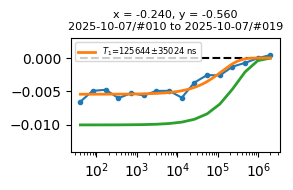

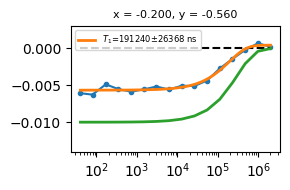

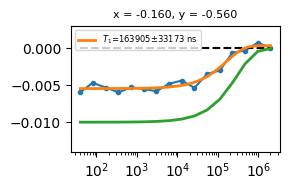

In [752]:
# Plot individual trace
j = 0; i = 2; idxArray = np.linspace(0,i,i+1); ifFit=1
for i in idxArray:
    i = int(i)
    fig, ax = plt.subplots(figsize=(3,2))
    label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
    if i==0:
        s = firstdatafile[31:46] + ' to ' + datafile[31:46]
        label = label + '\n' +s
    xplot = tau[j,i]; yplot = dataArr[j,i]
    ax.plot(xplot,yplot, 'o-',markersize=3)
    ax.set_ylim((-0.014,0.003))
    ax.hlines(y=0,xmin=min(xplot),xmax=max(xplot),linestyle='--',color='k')
    if ifFit:
        guesses = [
            np.array((-0.01,0,3e5,)),
            np.array((-0.01,0,1e6)),
            np.array((-0.01,0,1e4))
        ]

        for guess in guesses:
            try:
                ax.plot(xplot, dr.decay(xplot,*guess), '-', linewidth=2,color='C2')
                lowerBounds = (-np.inf, -1e-7, 0)
                xfit, yfit, popt, perr = dr.fitDecay(xplot, yplot, guess=guess, logx=1,lowerBounds=lowerBounds)
                s = '$T_{1}$=%.0f$\pm$%.0f ns' % (popt[2], perr[2])
                ax.plot(xfit, yfit, '-', linewidth=2, color='C1', label=s)
                
                break  # Stop if successful
            except Exception as e:
                continue  # Try next guess

    ax.legend(fontsize=6)
    ax.set_title(label,fontsize=8)
    ax.set_xscale('log')
    plt.tight_layout()

In [753]:
T1Array = np.ones((ny,nx))*(0); T1ErrArray = np.zeros((ny,nx))
for j in range(ny):
    for i in range(nx):
        try:
            xplot=tau[j,i]; yplot=dataArr[j,i]
            guesses = [
                np.array((-0.01,0,1e5,)),
                np.array((-0.01,0,1e6)),
                np.array((-0.01,0,1e4))
            ]
            for guess in guesses:
                try:
                    xfit, yfit, popt, perr = dr.fitDecay(xplot,yplot, guess=guess, logx=1,lowerBounds=lowerBounds)
                    T1Array[j,i] = popt[2]; T1ErrArray[j,i] = perr[2]
                    break  # Stop if successful
                except Exception as e:
                    continue  # Try next guess
        except:pass

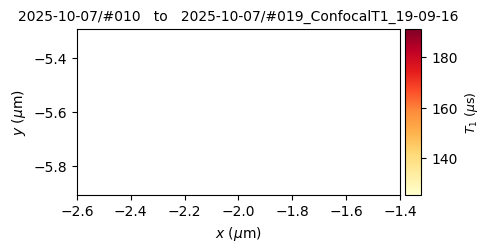

In [754]:
# 2D       
X = x[:,:,0]*conv_voltage; Y = y[:,:,0]*conv_voltage
fig, ax = plt.subplots(figsize=(5,5))

plot = ax.pcolormesh(X,Y, T1Array/1e3, cmap='YlOrRd')
    
ax.set_aspect(1)
divider = make_axes_locatable(ax)
cbar_ax = divider.append_axes("right", size="5%", pad=0.05)
cb1 = fig.colorbar(plot, orientation='vertical', ax=ax,cax=cbar_ax)
cb1.set_label('$T_{1}$ ($\mu$s)', fontsize=9)

a = 2
# plot.set_clim(0,a)

ax.set_xlabel('$V_x$ (V)')
ax.set_ylabel('$V_y$ (V)')

ax.set_xlabel('$x$ ($\mu$m)')
ax.set_ylabel('$y$ ($\mu$m)')
sp = 0.04*conv_voltage
for j in range(ny):
    for i in range(nx):
        if T1Array[j,i]==0:
            ax.add_patch(plt.Rectangle((X[0][i]-sp/2, Y[j][0]-sp/2), sp, sp, color='black'))

s = firstdatafile[31:46] + '   to   ' + datafile[31:66]
ax.set_title(s,fontsize=10)

plt.tight_layout()

### Fix 250828 DS 14-21

(1, 12)
[-8.63896795e-01  8.39343781e-01  4.73326720e+04  9.35726849e-01]


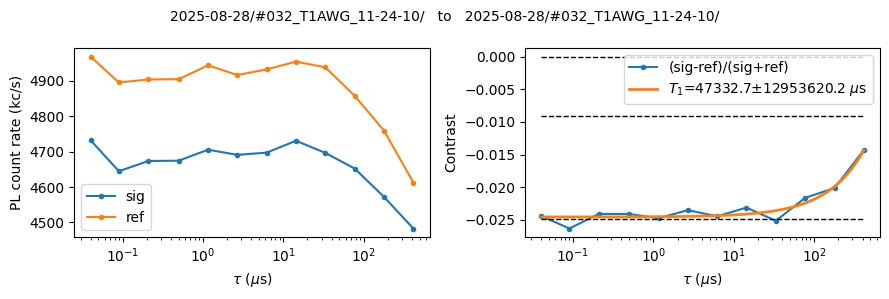

In [2730]:
# Multiple, with 1/e marking
days = np.linspace(1,31,31); count=0; ifLog=1; ifFit=1
dataArrOrg = dataArr; xOrg = x; yOrg = y
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-08-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'T1AWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = day==28 and idx>=24 and idx==26
                batch2 = day==28 and idx>=24 and idx==29
                batch3 = day==28 and idx>=24 and idx==32
                if batch3:
                    datafile = mainFolder + dataFolder +'/T1AWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = (sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = xPlot/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    axs[1].hlines(y=0, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    ymax = np.average(y[0:3])
    axs[1].hlines(y=ymax, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=ymax/np.e, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    # axs[1].vlines(x=4.2e3, ymin=min(y), ymax=max(y), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau$ ($\mu$s)')
    
    s = firstdatafile[31:62] + '   to   ' + datafile[31:62]
    fig.suptitle(s,fontsize=10)

    if ifFit:
        guess = (0.015,  0,  5e2,  1)
        xfit, yfit, popt, perr = dr.fitStrDecay(x, y, guess=guess, logx=1)
        print(popt)
        s = '$T_{1}$=%.1f$\pm$%.1f $\mu$s' % (popt[2], perr[2])
        axs[1].plot(xfit, yfit, '-', linewidth=2,color='C1',label=s)

    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    plt.tight_layout()

In [2731]:
dataArrNew = dataArrOrg
# dataArrNew[:,0,0:10] = dataArr[:,0:10]
# dataArrNew[:,1,0:10] = dataArr[:,0:10]
dataArrNew[:,2,0:10] = dataArr[:,0:10]

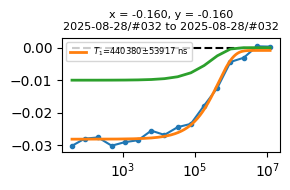

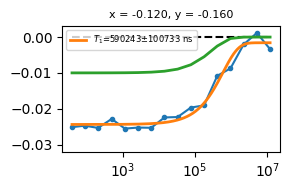

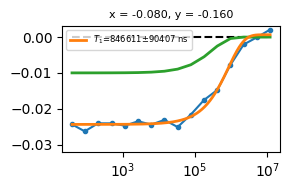

In [2732]:
# Plot individual trace
j = 0; i = 2; idxArray = np.linspace(0,i,i+1); ifFit=1
dataArr = dataArrNew; x = xOrg; y = yOrg
for i in idxArray:
    i = int(i)
    fig, ax = plt.subplots(figsize=(3,2))
    label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
    if i==0:
        s = firstdatafile[31:46] + ' to ' + datafile[31:46]
        label = label + '\n' +s
    xplot = tau[j,i]; yplot = dataArr[j,i]
    ax.plot(xplot,yplot, 'o-',markersize=3)
    ax.set_ylim((-0.032,0.003))
    ax.hlines(y=0,xmin=min(xplot),xmax=max(xplot),linestyle='--',color='k')
    if ifFit:
        guesses = [
            np.array((-0.01,0,3e5,)),
            np.array((-0.01,0,1e6)),
            np.array((-0.01,0,1e4))
        ]

        for guess in guesses:
            try:
                ax.plot(xplot, dr.decay(xplot,*guess), '-', linewidth=2,color='C2')
                xfit, yfit, popt, perr = dr.fitDecay(xplot, yplot, guess=guess, logx=1)
                s = '$T_{1}$=%.0f$\pm$%.0f ns' % (popt[2], perr[2])
                ax.plot(xfit, yfit, '-', linewidth=2, color='C1', label=s)
                
                break  # Stop if successful
            except Exception as e:
                continue  # Try next guess

    ax.legend(fontsize=6)
    ax.set_title(label,fontsize=8)
    ax.set_xscale('log')
    plt.tight_layout()

In [2735]:
T1Array = np.ones((ny,nx))*(0); T1ErrArray = np.zeros((ny,nx))
for j in range(ny):
    for i in range(nx):
        try:
            xplot=tau[j,i]; yplot=dataArr[j,i]
            guesses = [
                np.array((-0.01,0,1e5,)),
                np.array((-0.01,0,1e6)),
                np.array((-0.01,0,1e4))
            ]
            for guess in guesses:
                try:
                    xfit, yfit, popt, perr = dr.fitDecay(xplot,yplot, guess=guess, logx=1)
                    T1Array[j,i] = popt[2]; T1ErrArray[j,i] = perr[2]
                    break  # Stop if successful
                except Exception as e:
                    continue  # Try next guess
        except:pass

### Calculate mean

In [665]:
# T1Array = np.array((208552,70911,203223,97717,203950,137272)) # 9.5K on flake
# T1ErrArray = np.array((118690,40334,137592,66426,198309,87697)) # 9.5K on flake
# T1Array = np.array((67300, 88700)); T1ErrArray = np.array((19800, 11800)) # 40K on flake

# mask1 = T1Array > 2e6; mask2 = T1ErrArray < 2e6; mask = mask1 & mask2 # 9.5 K off flake
# T1Array = T1Array[mask]; T1ErrArray = T1ErrArray[mask] # 9.5 K off flake

# T1Array = np.array((635225,489380,840953,603931,910149,795630,641287,593231,544107),dtype=np.int64) # 60K on flake
# T1ErrArray = np.array((136287,71453,166411,116065,149912,102407,129642,86665,112009),dtype=np.int64) # 60K on flake
# T1Array = np.array((2576947,2868946),dtype=np.int64); T1ErrArray = np.array((850031,610392),dtype=np.int64) # 43.75K off flake
# T1Array = np.array((132966,228385),dtype=np.int64); T1ErrArray = np.array((54932,68694),dtype=np.int64) # 32K on flake

np.shape(T1Array)

(1, 3)

In [666]:
meanT1 = np.mean(T1Array)
meanT1Err = np.mean(T1ErrArray)
print('Mean T1 = %.0f $\mu$s' % (meanT1/1e3))
print('Mean T1 err = %.0f $\mu$s' % (meanT1Err/1e3))

weights = 1/(T1ErrArray**2)
meanT1_weighted = np.sum(T1Array*weights)/np.sum(weights)
meanT1Err_weighted = np.sqrt(1/np.sum(weights))
print('Mean T1 weighted = %.1f $\mu$s' % (meanT1_weighted/1e3))
print('Mean T1 err weighted = %.1f $\mu$s' % (meanT1Err_weighted/1e3))

Mean T1 = 160 $\mu$s
Mean T1 err = 32 $\mu$s
Mean T1 weighted = 166.5 $\mu$s
Mean T1 err weighted = 17.8 $\mu$s


### Dummy

In [947]:
dataArr = []; ifSingleGreenRead=1
month = 9; days = np.linspace(1,31,31); count=0; ifYCountDown=1
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-0'+str(month)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalT1'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                if True:
                    batch1a = (day==13 and idx>=-1) # 9.5K
                    batch1b = (day==15) # 9.5K
                    batch2 = (day==24 and idx<=96) # 51K
                    batch3 = (day==25 and idx<=6) #53 K
                    batch4 = (day==26 and idx<=15) # 55K
                    batch5 = (day==26 and idx>15) # 57.5K
                    batch6a = (day==27 and idx<=24) # 60K
                    batch6b = (day==27 and idx==26) # 60K sweep to 6e6 16 points
                    batch7 = (day==28 and idx<=21) #65K
                    batch8 = (day==28 and idx==47) #75K
                    batch9 = (day==28 and idx==63) #85K
                    batch9b = (day==29 and idx<=6) #85K off flake
                    batch10 = (day==29 and idx==18) #100 K
                    batch11 = (day==29 and idx==34) #120 K
                batch35b = (day==13 and idx>=14 and idx<=16) # 30K off flake
                batch39b = (day==15 and idx==8) # 26K off flake
                batch41b = (day==16 and idx==8) # 22K off flake
                batch43 = (day==17 and idx<=13) # 18K
                if batch43:  
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,tau,sig,ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
                    sig = np.array(sig); ref = np.array(ref); contrast = (sig-ref)/(sig+ref)
                    x = np.array(x); y = np.array(y)
                    (ny,nx,ntau) = np.shape(sig)
                    dataArr.append(contrast)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
dataArr = np.array(dataArr); print(np.shape(dataArr))
dataArr = np.average(dataArr, axis=0)
dataArr = np.average(dataArr, axis=1)
print(np.shape(dataArr))
convfactor = 2*0.028*1e6; conv_voltage=10

(2, 1, 3, 16)
(1, 16)


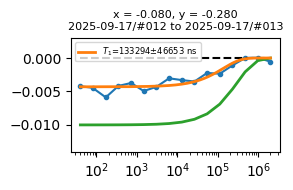

In [948]:
# Plot individual trace
j = 0; i = 0; idxArray = np.linspace(0,i,i+1); ifFit=1
for i in idxArray:
    i = int(i)
    fig, ax = plt.subplots(figsize=(3,2))
    label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
    if i==0:
        s = firstdatafile[31:46] + ' to ' + datafile[31:46]
        label = label + '\n' +s
    xplot = tau[j,i]; yplot = dataArr[0]
    ax.plot(xplot,yplot, 'o-',markersize=3)
    ax.set_ylim((-0.014,0.003))
    ax.hlines(y=0,xmin=min(xplot),xmax=max(xplot),linestyle='--',color='k')
    if ifFit:
        guesses = [
            np.array((-0.01,0,3e5,)),
            np.array((-0.01,0,1e6)),
            np.array((-0.01,0,1e4))
        ]

        for guess in guesses:
            try:
                ax.plot(xplot, dr.decay(xplot,*guess), '-', linewidth=2,color='C2')
                lowerBounds = (-np.inf, -1e-7, 0)
                xfit, yfit, popt, perr = dr.fitDecay(xplot, yplot, guess=guess, logx=1,lowerBounds=lowerBounds)
                s = '$T_{1}$=%.0f$\pm$%.0f ns' % (popt[2], perr[2])
                ax.plot(xfit, yfit, '-', linewidth=2, color='C1', label=s)
                
                break  # Stop if successful
            except Exception as e:
                continue  # Try next guess

    ax.legend(fontsize=6)
    ax.set_title(label,fontsize=8)
    ax.set_xscale('log')
    plt.tight_layout()

## Revised fit

### Manually

In [755]:
dataArr = []; ifSingleGreenRead=1
month = 10; days = np.linspace(1,31,31); count=0; ifYCountDown=1
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-'+str(int(month)).zfill(2)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalT1'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                if True:
                    batch1a = (day==13 and idx>=-1) # 9.5K
                    batch1b = (day==15) # 9.5K
                    batch2 = (day==24 and idx<=96) # 51K
                    batch3 = (day==25 and idx<=6) #53 K
                    batch4 = (day==26 and idx<=15) # 55K
                    batch5 = (day==26 and idx>15) # 57.5K
                    batch6a = (day==27 and idx<=24) # 60K
                    batch6b = (day==27 and idx==26) # 60K sweep to 6e6 16 points
                    batch7 = (day==28 and idx<=21) #65K
                    batch8 = (day==28 and idx==47) #75K
                    batch9 = (day==28 and idx==63) #85K
                    batch9b = (day==29 and idx<=6) #85K off flake
                    batch10 = (day==29 and idx==18) #100 K
                    batch11 = (day==29 and idx==34) #120 K
                if True:
                    batch12 = (day==30 and idx==21) or  (day==31 and idx<=5)  #60 K
                    batch13 = (day==31 and idx==20) # 55K
                    batch14 = (day==1 and idx==20) # 51K
                    batch15 = (day==2 and idx<=13) # 48.75K
                    batch16 = (day==2 and idx>=32) # 46.75
                    batch16b = (day==3 and idx<=9) # 46.75 K off flake
                    batch16c = (day==3 and idx>=10 and idx<=11) #46.75 K off flake longer tau
                    batch17 = (day==4 and idx<=3) # 45.25 K
                    batch17b = (day==4 and idx>=6) # 45.25K off flake
                    batch18 = (day==5 and idx<=3) # 44.5 K
                    batch18b = (day==4 and idx==19) # 44.5 off flake
                    batch19 = (day==5 and idx>=16 and idx<=17) # 43.75K
                    batch19b = (day==5 and idx>17) # 43.75K
                    batch20 = (day==6 and idx<=4) # 43K
                    batch20b = (day==6 and idx==7) # 43K off flake
                    batch21 = (day==6 and idx>=16 and idx <=17) # 42.5 K
                    batch22 = (day==6 and idx>=31) # 42K
                    batch22b = (day==7 and idx<=4) # 42K off flake
                    batch23 = (day==7 and idx>=17) # 41.5K
                    batch24 = (day==8 and idx<=3) # 41K
                    batch25 = (day==8 and idx>=15 and idx<=17) # 40K
                    batch25b = (day==8 and idx>=20) # 40 K off flake
                    batch26 = (day==9 and idx<=3) # 39 K
                    batch27 = (day==9 and idx>=16 and idx<=18) # 38 K
                    batch28 = (day==9 and idx>=31 and idx<=33) # 37 K
                    batch29 = (day==10 and idx<=15) # 36 K
                    batch29b = (day==10 and idx==25) # 36 K off flake
                    batch30 = (day==11 and idx<=16) # 35K
                    batch31 = (day==11 and idx>=28 and idx<=29) # 34K
                    batch32 = (day==11 and idx>=43 and idx<=45) # 33K
                    batch33 = (day==12 and idx<=7) # 32K
                    batch34 = (day==12 and idx>=8) # 31K
                    batch35 = (day==13 and idx<=13) # 30K
                    batch35b = (day==13 and idx>=14 and idx<=16) # 30K off flake
                    batch36 = (day==13 and idx >=17) # 29K
                    batch37 = (day==14 and idx<=5) # 28 K
                    batch38 = (day==14 and idx>=19 and idx<=321) # 27K
                    batch39 = (day==15 and idx<=5) # 26K
                    batch39b = (day==15 and idx==8) # 26K off flake
                    batch40 = (day==15 and idx>=9 and idx<=25) # 24 K
                    batch41 = (day==16 and idx<=5) # 22K on flake
                    batch41b = (day==16 and idx==8) # 22K off flake
                    batch42 = (day==16 and idx>=14) # 20 K
                    batch43 = (day==17 and idx<=13) # 18K
                    batch44 = (day==17 and idx>=14 and idx<=24) # 16K
                    batch45 = (day==17 and idx>=25) # 14 K
                    batch46 = (day==18 and idx<=10) # 12 K 
                    batch46b = (day==18 and idx>=11) # 12 K off flake
                    batch47 = (day==20 and idx<=4) # 9.5 K
                    batch47b = (day==19) # 9.5K off flake
                    batch48b = (day==20 and idx>=5) # 18K off flake
                if True:
                    batch49 = (day==22 and idx<=13) # 9.5 K on flake after FC North
                    batch50 = (day==23 and idx<=12) # 20 K
                    batch51 = (day==25 and idx<=8) # 25 K
                    batch52 = (day==27) # 30 K
                    batch53 = (day==7) # 9.5 K FC South
                if batch53:  
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,tau,sig,ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
                    sig = np.array(sig); ref = np.array(ref); contrast = (sig-ref)/(sig+ref)
                    x = np.array(x); y = np.array(y)
                    (ny,nx,ntau) = np.shape(sig)
                    dataArr.append(contrast)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
dataArr = np.array(dataArr); print(np.shape(dataArr))
convfactor = 2*0.028*1e6; conv_voltage=10

(10, 1, 3, 16)


In [756]:
# Averaging data
if True: # standard
    dataArr = np.average(dataArr, axis=(0,1,2)); print(np.shape(dataArr))

    # Normalization
    # # dataArr = dataArr - np.average(dataArr[-2:])
    dataArr = dataArr/ np.min(dataArr) #dataArr[0]

    # dataArr = linear_map(dataArr,np.max(dataArr),np.min(dataArr),1,0)
if False: #9.5K onflake
    dataArr = dataArr[:,8:,0:2,:]; print(np.shape(dataArr))
    dataArr = np.average(dataArr, axis=(0,1,2)); print(np.shape(dataArr))
    dataArr = dataArr/ np.min(dataArr)

(16,)


C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22856\2916840140.py:4: RuntimeWarning: invalid value encountered in log
  xplot = tau[0,0]; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22856\2916840140.py:4: RuntimeWarning: divide by zero encountered in log
  xplot = tau[0,0]; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr


[1.22023861e+05 6.36192210e-01]
[2.21336377e+04 8.67304009e-02]
-------------------------


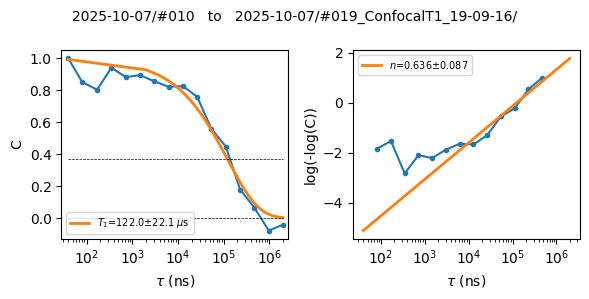

In [757]:
# Plot individual trace
ifFit=1; ifLog=0
fig, axs = plt.subplots(1,2, figsize=(6,3))
xplot = tau[0,0]; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr

axs[0].plot(xplot,yplot0, 'o-',markersize=3,  label=None)
axs[1].plot(xplot,yplot, 'o-',markersize=3,  label=None)
axs[0].set_xscale('log'); axs[1].set_xscale('log')

if ifFit:
    guesses = [
        np.array((250e3, 0.5)),
        np.array((1500e3, 1)),
        np.array((2000e3, 0.8)),
        np.array((4000e3, 0.8)),
    ]
    lowerBounds=np.array((50, 1))
    lowerBounds=np.array((50, 0))
    lowerBounds=np.array((0,  0))
    lowerBounds=None

    upperBounds=None
    
    for guess in guesses:
        try:
            xfit, yfit, popt, perr = dr.fitStrDecayNorm(xplot, dataArr, guess=guess, logx=ifLog,
                                                    lowerBounds=lowerBounds, upperBounds=upperBounds)
            s = '$T_{1}$=%.1f$\pm$%.1f $\mu$s' % (popt[0]/1e3, perr[0]/1e3)
            s1 = '$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])
            print(popt)
            print(perr)

            yfitplot = np.log(-np.log(yfit))
            yfitplot0 = yfit

            axs[0].plot(xfit, yfitplot0, '-', linewidth=2, color='C1', label=s)
            axs[0].hlines(y=0,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
            axs[0].hlines(y=np.max(yplot0)/np.e,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
            
            axs[1].plot(xfit, yfitplot, '-', linewidth=2, color='C1', label=s1)
            break  # Stop if successful
        except Exception as e:
            continue  # Try next guess
    print('-------------------------')

axs[0].legend(fontsize=7); axs[1].legend(fontsize=7)

axs[0].set_xlim(0.7*np.min(xfit),1.3*np.max(xfit))
# axs[1].set_ylim((1.2*np.nanmin(yplot[np.isfinite(yplot)]), 1.5*np.nanmax(yplot[np.isfinite(yplot)])))
axs[0].set_xlabel('$\\tau$ (ns)')
axs[0].set_ylabel('C')
axs[1].set_xlabel('$\\tau$ (ns)')
axs[1].set_ylabel('log(-log(C))')

s = firstdatafile[31:46] + '   to   ' + datafile[31:67]
fig.suptitle(s,fontsize=10)

plt.tight_layout()

### Autofit across different temperatures

In [295]:
# ---------------------  Cooling ----------------------------
# 1) Batch definitions (month added, temperature T)
# -------------------------------------------------
batches = {
    "batch12":  {"month": 8, "day": 31, "idx_max": 5, "T": 60, "off_flake": False},

    "batch13":  {"month": 8, "day": 31, "idx": 20, "T": 55, "off_flake": False},

    "batch14":  {"month": 9, "day": 1, "idx": 20, "T": 51, "off_flake": False},
    "batch15":  {"month": 9, "day": 2, "idx_max": 13, "T": 48.75, "off_flake": False},
    "batch16":  {"month": 9, "day": 2, "idx_min": 32, "T": 46.75, "off_flake": False},
    "batch16b": {"month": 9, "day": 3, "idx_max": 9, "T": 46.75, "off_flake": True},
    "batch16c": {"month": 9, "day": 3, "idx_range": (10, 11), "T": 46.75, "off_flake": True},

    "batch17":  {"month": 9, "day": 4, "idx_max": 3, "T": 45.25, "off_flake": False},
    "batch17b": {"month": 9, "day": 4, "idx_min": 6, "T": 45.25, "off_flake": True},

    "batch18":  {"month": 9, "day": 5, "idx_max": 3, "T": 44.5, "off_flake": False},
    "batch18b": {"month": 9, "day": 4, "idx": 19, "T": 44.5, "off_flake": True},

    "batch19":  {"month": 9, "day": 5, "idx_range": (16, 17), "T": 43.75, "off_flake": False},
    "batch19b": {"month": 9, "day": 5, "idx_min": 18, "T": 43.75, "off_flake": True},

    "batch20":  {"month": 9, "day": 6, "idx_max": 4, "T": 43, "off_flake": False},
    "batch20b": {"month": 9, "day": 6, "idx": 7, "T": 43, "off_flake": True},

    "batch21":  {"month": 9, "day": 6, "idx_range": (16, 17), "T": 42.5, "off_flake": False},
    "batch22":  {"month": 9, "day": 6, "idx_min": 31, "T": 42, "off_flake": False},
    "batch22b": {"month": 9, "day": 7, "idx_max": 4, "T": 42, "off_flake": True},

    "batch23":  {"month": 9, "day": 7, "idx_min": 17, "T": 41.5, "off_flake": False},

    "batch24":  {"month": 9, "day": 8, "idx_max": 3, "T": 41, "off_flake": False},
    "batch25":  {"month": 9, "day": 8, "idx_range": (15, 17), "T": 40, "off_flake": False},
    "batch25b": {"month": 9, "day": 8, "idx_min": 20, "T": 40, "off_flake": True},

    "batch26":  {"month": 9, "day": 9, "idx_max": 3, "T": 39, "off_flake": False},
    "batch27":  {"month": 9, "day": 9, "idx_range": (16, 18), "T": 38, "off_flake": False},
    "batch28":  {"month": 9, "day": 9, "idx_range": (31, 33), "T": 37, "off_flake": False},

    "batch29":  {"month": 9, "day": 10, "idx_max": 15, "T": 36, "off_flake": False},
    "batch29b": {"month": 9, "day": 10, "idx": 25, "T": 36, "off_flake": True},

    "batch30":  {"month": 9, "day": 11, "idx_max": 16, "T": 35, "off_flake": False},
    "batch31":  {"month": 9, "day": 11, "idx_range": (28, 29), "T": 34, "off_flake": False},
    "batch32":  {"month": 9, "day": 11, "idx_range": (43, 45), "T": 33, "off_flake": False},

    "batch33":  {"month": 9, "day": 12, "idx_max": 7, "T": 32, "off_flake": False},
    "batch34":  {"month": 9, "day": 12, "idx_min": 8, "T": 31, "off_flake": False},

    "batch35":  {"month": 9, "day": 13, "idx_max": 13, "T": 30, "off_flake": False},
    "batch35b": {"month": 9, "day": 13, "idx_range": (14, 16), "T": 30, "off_flake": True},
    "batch36":  {"month": 9, "day": 13, "idx_min": 17, "T": 29, "off_flake": False},

    "batch37":  {"month": 9, "day": 14, "idx_max": 5, "T": 28, "off_flake": False},
    "batch38":  {"month": 9, "day": 14, "idx_range": (19, 321), "T": 27, "off_flake": False},

    "batch39":  {"month": 9, "day": 15, "idx_max": 5, "T": 26, "off_flake": False},
    "batch39b": {"month": 9, "day": 15, "idx": 8, "T": 26, "off_flake": True},
    "batch40":  {"month": 9, "day": 15, "idx_range": (9, 25), "T": 24, "off_flake": False},

    "batch41":  {"month": 9, "day": 16, "idx_max": 5, "T": 22, "off_flake": False},
    "batch41b": {"month": 9, "day": 16, "idx": 8, "T": 22, "off_flake": True},
    "batch42":  {"month": 9, "day": 16, "idx_min": 14, "T": 20, "off_flake": False},

    "batch43":  {"month": 9, "day": 17, "idx_max": 13, "T": 18, "off_flake": False},
    "batch44":  {"month": 9, "day": 17, "idx_range": (14, 24), "T": 16, "off_flake": False},
    "batch45":  {"month": 9, "day": 17, "idx_min": 25, "T": 14, "off_flake": False},

    "batch46":  {"month": 9, "day": 18, "idx_max": 10, "T": 12, "off_flake": False},
    "batch46b": {"month": 9, "day": 18, "idx_min": 11, "T": 12, "off_flake": True},

    "batch47":  {"month": 9, "day": 20, "idx_max": 4, "T": 9.5, "off_flake": False},
    "batch47b": {"month": 9, "day": 19, "idx_max": 400, "T": 9.5, "off_flake": True},  # any idx
    "batch48b": {"month": 9, "day": 20, "idx_min": 5, "T": 18, "off_flake": True},
}

# -------------------------------
# 2) Helpers
# -------------------------------
def idx_matches(cfg, idx):
    if "idx" in cfg:
        return idx == cfg["idx"]
    if "idx_range" in cfg:
        a, b = cfg["idx_range"]
        return (idx >= a) and (idx <= b)
    if "idx_min" in cfg:
        return idx >= cfg["idx_min"]
    if "idx_max" in cfg:
        return idx <= cfg["idx_max"]
    return False

def load_contrasts_for_batch(base_dir, cfg, ifYCountDown=1):
    """Return list of contrast arrays for all folders matching the batch."""
    month, day = cfg["month"], cfg["day"]
    mainFolder = f"{base_dir}/2025-0{month}-{int(day):02d}/"
    out, firstfile, lastfile, tau_ref = [], None, None, None
    try:
        for dataFolder in os.listdir(mainFolder):
            if "ConfocalT1" not in dataFolder:
                continue
            idx = int(dataFolder[1:4])
            if not idx_matches(cfg, idx):
                continue
            type_ = "ConfocalT1"
            datafile = (mainFolder + dataFolder + '/' +
                        f"{type_}Object_y_set_{type_}Object_x_set_{type_}Object_sig_set.dat")
            x, y, tau, sig, ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
            sig = np.array(sig); ref = np.array(ref)
            contrast = (sig - ref) / (sig + ref)
            out.append(contrast)
            tau_ref = tau  # keep the last one (they should be identical)
            if firstfile is None:
                firstfile = datafile
            lastfile = datafile
    except Exception as e:
        pass
    return out, tau_ref, firstfile, lastfile

# -------------------------------
# 3) Iterate batches and plot
# -------------------------------
base_dir = "C:/Users/lukin2dmaterials/data"  # root path up to year
ifSingleGreenRead = 1
ifYCountDown = 1
convfactor = 2*0.028*1e6
conv_voltage = 10
ifFit = 1
ifLog = 0

results = {
    "on": {"temp": [], "n": [], "n_err": [], "t1": [], "t1_err": []},
    "off": {"temp": [], "n": [], "n_err": [], "t1": [], "t1_err": []},
}


for bname, cfg in batches.items():
    # Collect all files for this batch
    arr_list, tau, firstfile, lastfile = load_contrasts_for_batch(base_dir, cfg, ifYCountDown=ifYCountDown)
    if not arr_list:
        print(f"[{bname}] no matching data found.")
        continue

    # Title includes batch name, temperature, off/on flake, and file span
    tempK = cfg["T"]
    flake_str = "off flake" if cfg.get("off_flake", False) else "on flake"
    key = "off" if flake_str == "off flake" else "on"

    dataArr = np.array(arr_list)
    # Average over pixels and stack dimension
    # if (tempK in (42, 43)) and (flake_str == "on flake"):
    #     dataArr = dataArr[:, :, 1:, :]   # drop column 0 (axis=2 is x)
    dataArr = np.average(dataArr, axis=(0, 1, 2))

    # Normalize
    dataArr = dataArr / np.min(dataArr) #dataArr[0]

    # dataArr = dataArr - np.average(dataArr[-2:])
    # dataArr = dataArr/dataArr[0]
    # dataArr = linear_map(dataArr,np.max(dataArr),np.min(dataArr),1,0)

    # Prepare plot data
    xplot = tau[0, 0]
    yplot0 = dataArr
    yplot = np.log(-np.log(dataArr))

    # fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    # axs[0].plot(xplot, yplot0, 'o-', markersize=3)
    # axs[1].plot(xplot, yplot,  'o-', markersize=3)
    # axs[0].set_xscale('log'); axs[1].set_xscale('log')

    # Fit (stretched exponential, using your helper)
    if ifFit:
        guesses = [np.array((250, 0.5)),
                   np.array((1500, 1.0)),
                   np.array((2000, 0.8)),
                   np.array((4000, 0.8))]
        lowerBounds = None
        upperBounds = None
        fitted = False
        for guess in guesses:
            try:
                xfit, yfit, popt, perr = dr.fitStrDecayNorm(
                    xplot, dataArr, guess=guess, logx=ifLog,
                    lowerBounds=lowerBounds, upperBounds=upperBounds
                )
                s_T = r'$T_{1}$=%.1f$\pm$%.1f $\mu$s' % (popt[0], perr[0])
                s_n = r'$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])

                yfitplot0 = yfit
                yfitplot = np.log(-np.log(yfit))

                axs[0].plot(xfit, yfitplot0, '-', linewidth=2, color='C1', label=s_T)
                axs[0].hlines(y=0, xmin=min(xfit), xmax=max(xfit),
                              linestyle='--', color='k', linewidth=0.5)
                axs[0].hlines(y=np.max(yplot0)/np.e, xmin=min(xfit), xmax=max(xfit),
                              linestyle='--', color='k', linewidth=0.5)

                axs[1].plot(xfit, yfitplot, '-', linewidth=2, color='C1', label=s_n)
                fitted = True
                break
            except Exception:
                continue

        if fitted:
            axs[0].legend(fontsize=7)
            axs[1].legend(fontsize=7)

    # Labels and title (with temperature)
    # axs[0].set_xlabel(r'$\tau$ (ns)'); axs[0].set_ylabel('C')
    # axs[1].set_xlabel(r'$\tau$ (ns)'); axs[1].set_ylabel(r'log(-log(C))')

    # if fitted:
    #     axs[0].set_xlim(0.7*np.min(xfit), 1.3*np.max(xfit))

    # Add to result dictionary
    results[key]["temp"].append(tempK)
    results[key]["n"].append(popt[1])
    results[key]["n_err"].append(perr[1])
    results[key]["t1"].append(popt[0])
    results[key]["t1_err"].append(perr[0])

    span = ""
    if firstfile and lastfile:
        span = f"{firstfile[31:46]}   to   {lastfile[31:67]}"
    # fig.suptitle(f"{bname} — {tempK} K ({flake_str})\n{span}", fontsize=10)

    # plt.tight_layout()
    # plt.show()

temp_on_down   = np.array(results["on"]["temp"])
n_on_down      = np.array(results["on"]["n"])
n_err_on_down  = np.array(results["on"]["n_err"])
t1_on_down    = np.array(results["on"]["t1"])
t1_err_on_down= np.array(results["on"]["t1_err"])

temp_off_down   = np.array(results["off"]["temp"])
n_off_down      = np.array(results["off"]["n"])
n_err_off_down  = np.array(results["off"]["n_err"])
t1_off_down    = np.array(results["off"]["t1"])
t1_err_off_down= np.array(results["off"]["t1_err"])


C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22856\3338394061.py:165: RuntimeWarning: invalid value encountered in log
  yplot = np.log(-np.log(dataArr))
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22856\3338394061.py:165: RuntimeWarning: divide by zero encountered in log
  yplot = np.log(-np.log(dataArr))


C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22856\3931103346.py:112: RuntimeWarning: invalid value encountered in log
  yplot = np.log(-np.log(dataArr))
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22856\3931103346.py:112: RuntimeWarning: divide by zero encountered in log
  yplot = np.log(-np.log(dataArr))


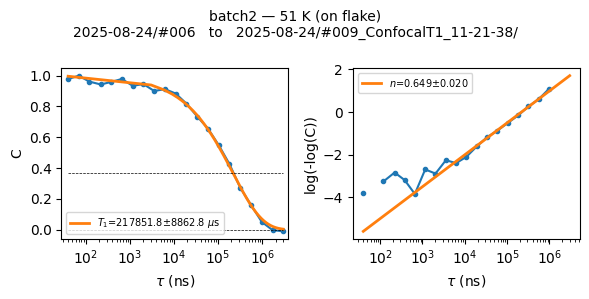

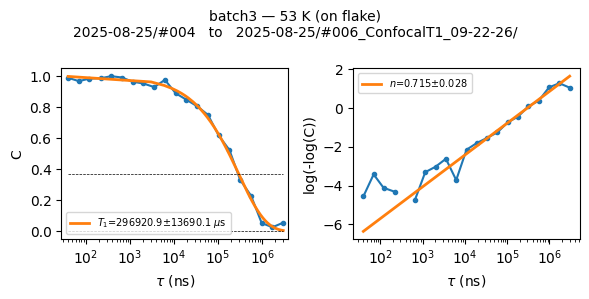

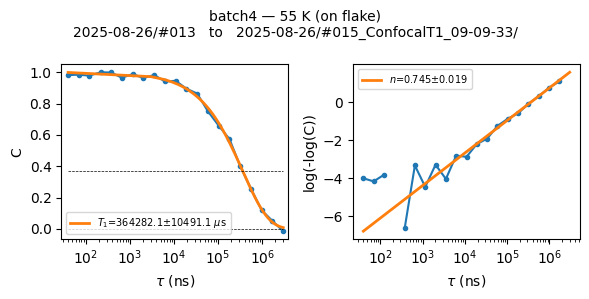

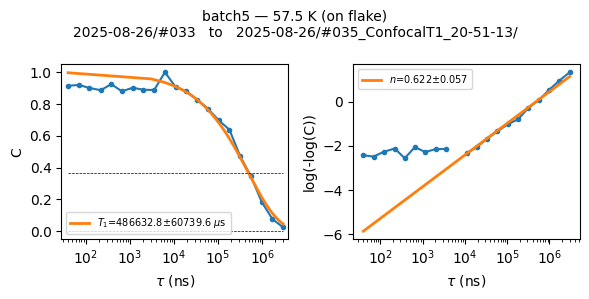

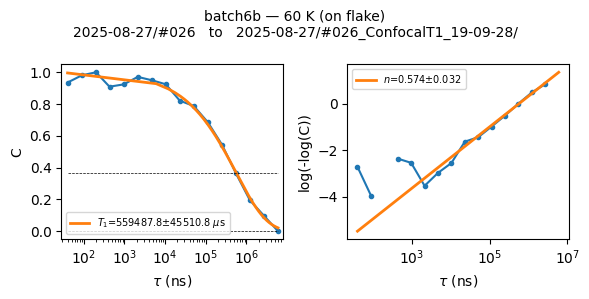

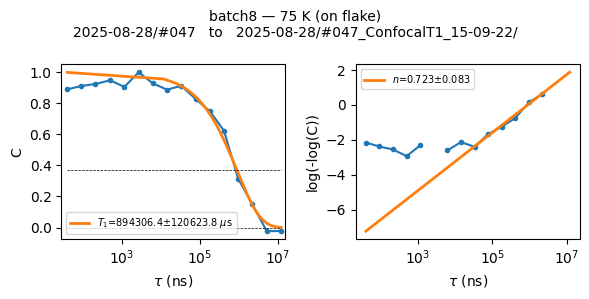

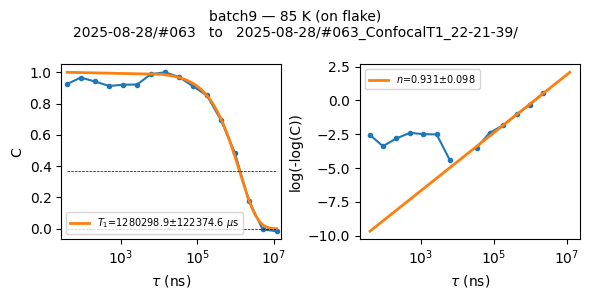

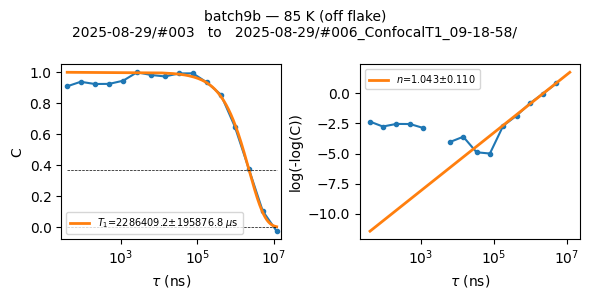

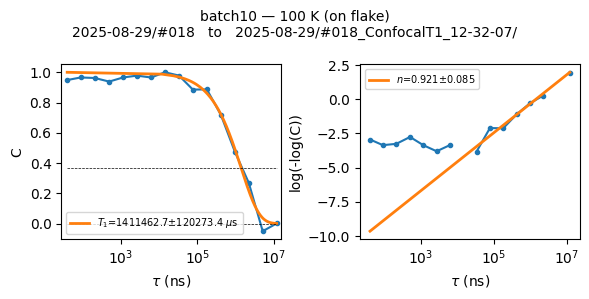

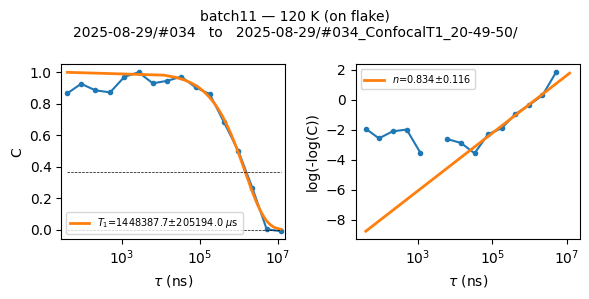

In [296]:
# ---------------------  Heating ----------------------------
# 1) Batch definitions (month added, temperature T)
# -------------------------------------------------
batches = {
    # "batch1a": {"month": 8, "day": 13, "idx_min": -1, "T": 9.5, "off_flake": False},
    # "batch1b": {"month": 8, "day": 15, "idx_min": -1, "T": 9.5, "off_flake": False},  # any idx

    "batch2":  {"month": 8, "day": 24, "idx_max": 96, "T": 51, "off_flake": False},
    "batch3":  {"month": 8, "day": 25, "idx_max": 6,  "T": 53, "off_flake": False},
    "batch4":  {"month": 8, "day": 26, "idx_max": 15, "T": 55, "off_flake": False},
    "batch5":  {"month": 8, "day": 26, "idx_min": 16, "T": 57.5, "off_flake": False},

    # "batch6a": {"month": 8, "day": 27, "idx_max": 24, "T": 60, "off_flake": False},
    "batch6b": {"month": 8, "day": 27, "idx": 26, "T": 60, "off_flake": False},  # sweep to 6e6

    # "batch7":  {"month": 8, "day": 28, "idx_max": 21, "T": 65, "off_flake": False},
    "batch8":  {"month": 8, "day": 28, "idx": 47, "T": 75, "off_flake": False},
    "batch9":  {"month": 8, "day": 28, "idx": 63, "T": 85, "off_flake": False},
    "batch9b": {"month": 8, "day": 29, "idx_max": 6,  "T": 85, "off_flake": True},

    "batch10": {"month": 8, "day": 29, "idx": 18, "T": 100, "off_flake": False},
    "batch11": {"month": 8, "day": 29, "idx": 34, "T": 120, "off_flake": False},
}

# -------------------------------
# 2) Helpers
# -------------------------------
def idx_matches(cfg, idx):
    if "idx" in cfg:
        return idx == cfg["idx"]
    if "idx_range" in cfg:
        a, b = cfg["idx_range"]
        return (idx >= a) and (idx <= b)
    if "idx_min" in cfg:
        return idx >= cfg["idx_min"]
    if "idx_max" in cfg:
        return idx <= cfg["idx_max"]
    return False

def load_contrasts_for_batch(base_dir, cfg, ifYCountDown=1):
    """Return list of contrast arrays for all folders matching the batch."""
    month, day = cfg["month"], cfg["day"]
    mainFolder = f"{base_dir}/2025-0{month}-{int(day):02d}/"
    out, firstfile, lastfile, tau_ref = [], None, None, None
    try:
        for dataFolder in os.listdir(mainFolder):
            if "ConfocalT1" not in dataFolder:
                continue
            idx = int(dataFolder[1:4])
            if not idx_matches(cfg, idx):
                continue
            type_ = "ConfocalT1"
            datafile = (mainFolder + dataFolder + '/' +
                        f"{type_}Object_y_set_{type_}Object_x_set_{type_}Object_sig_set.dat")
            x, y, tau, sig, ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
            sig = np.array(sig); ref = np.array(ref)
            contrast = (sig - ref) / (sig + ref)
            out.append(contrast)
            tau_ref = tau  # keep the last one (they should be identical)
            if firstfile is None:
                firstfile = datafile
            lastfile = datafile
    except Exception as e:
        pass
    return out, tau_ref, firstfile, lastfile

# -------------------------------
# 3) Iterate batches and plot
# -------------------------------
base_dir = "C:/Users/lukin2dmaterials/data"  # root path up to year
ifSingleGreenRead = 1
ifYCountDown = 1
convfactor = 2*0.028*1e6
conv_voltage = 10
ifFit = 1
ifLog = 0

results = {
    "on": {"temp": [], "n": [], "n_err": [], "t1": [], "t1_err": []},
    "off": {"temp": [], "n": [], "n_err": [], "t1": [], "t1_err": []},
}


for bname, cfg in batches.items():
    # Collect all files for this batch
    arr_list, tau, firstfile, lastfile = load_contrasts_for_batch(base_dir, cfg, ifYCountDown=ifYCountDown)
    if not arr_list:
        print(f"[{bname}] no matching data found.")
        continue

    # Title includes batch name, temperature, off/on flake, and file span
    tempK = cfg["T"]
    flake_str = "off flake" if cfg.get("off_flake", False) else "on flake"
    key = "off" if flake_str == "off flake" else "on"

    dataArr = np.array(arr_list)
    # Average over pixels and stack dimension
    # if (tempK in (42, 43)) and (flake_str == "on flake"):
    #     dataArr = dataArr[:, :, 1:, :]   # drop column 0 (axis=2 is x)
    dataArr = np.average(dataArr, axis=(0, 1, 2))

    # Normalize
    dataArr = dataArr / np.min(dataArr) #dataArr[0]

    # dataArr = dataArr - np.average(dataArr[-2:])
    # dataArr = dataArr/dataArr[0]
    # dataArr = linear_map(dataArr,np.max(dataArr),np.min(dataArr),1,0)

    # Prepare plot data
    xplot = tau[0, 0]
    yplot0 = dataArr
    yplot = np.log(-np.log(dataArr))

    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].plot(xplot, yplot0, 'o-', markersize=3)
    axs[1].plot(xplot, yplot,  'o-', markersize=3)
    axs[0].set_xscale('log'); axs[1].set_xscale('log')

    # Fit (stretched exponential, using your helper)
    if ifFit:
        guesses = [np.array((250, 0.5)),
                   np.array((1500, 1.0)),
                   np.array((2000, 0.8)),
                   np.array((4000, 0.8))]
        lowerBounds = None
        upperBounds = None
        fitted = False
        for guess in guesses:
            try:
                xfit, yfit, popt, perr = dr.fitStrDecayNorm(
                    xplot, dataArr, guess=guess, logx=ifLog,
                    lowerBounds=lowerBounds, upperBounds=upperBounds
                )
                s_T = r'$T_{1}$=%.1f$\pm$%.1f $\mu$s' % (popt[0], perr[0])
                s_n = r'$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])

                yfitplot0 = yfit
                yfitplot = np.log(-np.log(yfit))

                axs[0].plot(xfit, yfitplot0, '-', linewidth=2, color='C1', label=s_T)
                axs[0].hlines(y=0, xmin=min(xfit), xmax=max(xfit),
                              linestyle='--', color='k', linewidth=0.5)
                axs[0].hlines(y=np.max(yplot0)/np.e, xmin=min(xfit), xmax=max(xfit),
                              linestyle='--', color='k', linewidth=0.5)

                axs[1].plot(xfit, yfitplot, '-', linewidth=2, color='C1', label=s_n)
                fitted = True
                break
            except Exception:
                continue

        if fitted:
            axs[0].legend(fontsize=7)
            axs[1].legend(fontsize=7)

    # Labels and title (with temperature)
    axs[0].set_xlabel(r'$\tau$ (ns)'); axs[0].set_ylabel('C')
    axs[1].set_xlabel(r'$\tau$ (ns)'); axs[1].set_ylabel(r'log(-log(C))')

    if fitted:
        axs[0].set_xlim(0.7*np.min(xfit), 1.3*np.max(xfit))

    # Add to result dictionary
    results[key]["temp"].append(tempK)
    results[key]["n"].append(popt[1])
    results[key]["n_err"].append(perr[1])
    results[key]["t1"].append(popt[0])
    results[key]["t1_err"].append(perr[0])

    span = ""
    if firstfile and lastfile:
        span = f"{firstfile[31:46]}   to   {lastfile[31:67]}"
    fig.suptitle(f"{bname} — {tempK} K ({flake_str})\n{span}", fontsize=10)

    plt.tight_layout()
    plt.show()

temp_on_up   = np.array(results["on"]["temp"])
n_on_up      = np.array(results["on"]["n"])
n_err_on_up  = np.array(results["on"]["n_err"])
t1_on_up    = np.array(results["on"]["t1"])
t1_err_on_up= np.array(results["on"]["t1_err"])

temp_off_up   = np.array(results["off"]["temp"])
n_off_up      = np.array(results["off"]["n"])
n_err_off_up  = np.array(results["off"]["n_err"])
t1_off_up    = np.array(results["off"]["t1"])
t1_err_off_up= np.array(results["off"]["t1_err"])


In [297]:
if True:
    temp_off_down_extra    = np.array((60,   55,   51,))#   48.75, ))
    n_off_down_extra       = np.array((0.863,0.733, 0.769,))# 1.209))
    n_err_off_down_extra   = np.array((0.125,0.090, 0.114,))# 0.3))
    t1_off_down_extra     = np.array((1761.7,1951.1,1929,))*1e3#  1746.5))*1e3
    t1_err_off_down_extra = np.array((250.8, 277.8, 315.9,))*1e3# 300.9))*1e3

    temp_off_down    = np.concatenate((temp_off_down,temp_off_down_extra))
    n_off_down       = np.concatenate((n_off_down,   n_off_down_extra))
    n_err_off_down   = np.concatenate((n_err_off_down, n_err_off_down_extra))
    t1_off_down     = np.concatenate((t1_off_down, t1_off_down_extra))
    t1_err_off_down = np.concatenate((t1_err_off_down, t1_err_off_down_extra))

    order = np.argsort(temp_off_down)
    temp_off_down    = temp_off_down[order]
    n_off_down       = n_off_down[order]
    n_err_off_down   = n_err_off_down[order]
    t1_off_down     = t1_off_down[order]
    t1_err_off_down = t1_err_off_down[order]

if True:
    temp_on_up_extra    = np.array((9.5,  20,   30,   40,   42,   43,   44.5,  46,   47.5,  49,))#9.5,   20,   30,   40,   42,   43,   
    n_on_up_extra       = np.array((0.609,0.591,0.977,0.703,0.461,0.541,0.712,0.619,0.622,0.640))
    n_err_on_up_extra   = np.array((0.113,0.142,0.195,0.072,0.042,0.062,0.080,0.053,0.046,0.054))
    t1_on_up_extra     = np.array(( 132.4,67.3, 82.6, 110.9,93.1, 71.3, 100.8,103,  138.9,118.3))*1e3
    t1_err_on_up_extra = np.array(( 33.9, 23.1, 14.3, 13.7, 15.2, 12.6, 13.5, 12.1, 14,   13.2))*1e3

    temp_on_up    = np.concatenate((temp_on_up,temp_on_up_extra))
    n_on_up       = np.concatenate((n_on_up,   n_on_up_extra))
    n_err_on_up   = np.concatenate((n_err_on_up, n_err_on_up_extra))
    t1_on_up     = np.concatenate((t1_on_up, t1_on_up_extra))
    t1_err_on_up = np.concatenate((t1_err_on_up, t1_err_on_up_extra))

    order = np.argsort(temp_on_up)
    temp_on_up    = temp_on_up[order]
    n_on_up       = n_on_up[order]
    n_err_on_up   = n_err_on_up[order]
    t1_on_up     = t1_on_up[order]
    t1_err_on_up = t1_err_on_up[order]

if True:
    temp_off_up_extra    = np.array((120,))#9.5,   20,   30,   40,   42,   43,   
    n_off_up_extra       = np.array((0.940,))
    n_err_off_up_extra   = np.array((0.077,))
    t1_off_up_extra     = np.array(( 2292.2,))*1e3
    t1_err_off_up_extra = np.array(( 168.3,))*1e3

    temp_off_up    = np.concatenate((temp_off_up,temp_off_up_extra,temp_off_down))
    n_off_up       = np.concatenate((n_off_up,   n_off_up_extra,n_off_down))
    n_err_off_up   = np.concatenate((n_err_off_up, n_err_off_up_extra,n_err_off_down))
    t1_off_up     = np.concatenate((t1_off_up, t1_off_up_extra,t1_off_down))
    t1_err_off_up = np.concatenate((t1_err_off_up, t1_err_off_up_extra,t1_err_off_down))

    order = np.argsort(temp_off_up)
    temp_off_up    = temp_off_up[order]
    n_off_up       = n_off_up[order]
    n_err_off_up   = n_err_off_up[order]
    t1_off_up     = t1_off_up[order]
    t1_err_off_up = t1_err_off_up[order]

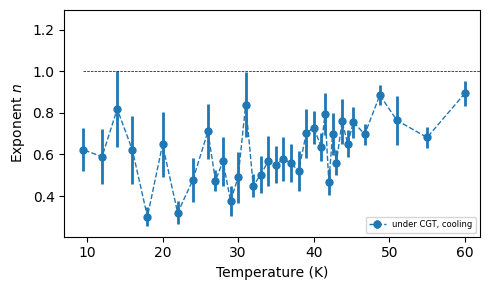

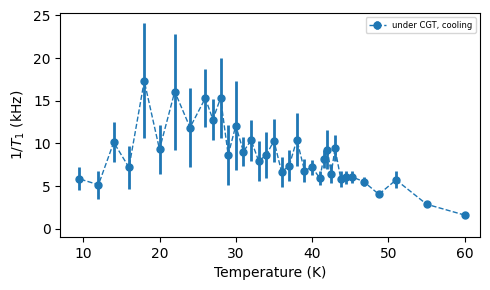

In [307]:
fig,ax=plt.subplots(figsize=(5,3)); factor=1e3
# ax.errorbar(temp_on_up, n_on_up, n_err_on_up,
#             marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="under CGT, heating")
ax.errorbar(temp_on_down, n_on_down, n_err_on_down,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, cooling")
# ax.errorbar(temp_off_down, n_off_down, n_err_off_down,
#             marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT")
# ax.errorbar(temp_off_up, n_off_up, n_err_off_up,
#             marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT")

# xlim1 = ax.get_xlim()
# ylim1 = ax.get_ylim()
ax.set_xlim(xlim1)
ax.set_ylim(ylim1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Exponent $n$')
ax.legend(fontsize=6,loc='lower right')
ax.hlines(y=1,xmin=min(temp_on_down),xmax=max(temp_on_up),linestyle='--',color='k',linewidth=0.5)
ax.set_xlim((7,62))
plt.tight_layout()

fig,ax=plt.subplots(figsize=(5,3)); factor=1e6

# ax.errorbar(temp_on_up,1/t1_on_up*factor,t1_err_on_up/t1_on_up**2*factor,
#             marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="under CGT, heating")
ax.errorbar(temp_on_down,1/t1_on_down*factor,t1_err_on_down/t1_on_down**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, cooling")
# ax.errorbar(temp_off_down,1/t1_off_down*factor,t1_err_off_down/t1_off_down**2*factor,
#             marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT")
# ax.errorbar(temp_off_up,1/t1_off_up*factor,t1_err_off_up/t1_off_up**2*factor,
#             marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT")
# ax.set_yscale('log')

# xlim2 = ax.get_xlim()
# ylim2 = ax.get_ylim()
ax.set_xlim(xlim2)
ax.set_ylim(ylim2)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$1/T_{1}$ (kHz)')
ax.legend(fontsize=6,loc='upper right')
ax.set_xlim((7,62))
plt.tight_layout()

## Temp sweep

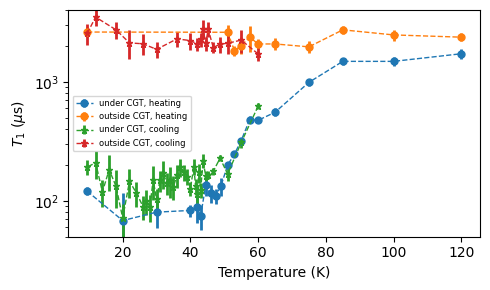

In [2798]:
temp_onFlake  = np.array((9.5,   20,   30,   40,   42,   43,   44.5,  46,   47.5,  49,   51,  53,  55,  57.5, 60,    65,    75,  85,     100,   120))
T1_onFlake    = np.array((120.6, 68.3, 80.4, 83.1, 89,   74.3, 134.6, 116,  109.8, 133.1,200, 247, 321, 480,  474.4, 554.5, 988, 1482.5, 1482,  1717.3))
T1Err_onFlake = np.array((9.6,   48.1, 21,   10.1, 23.3, 17.6, 24.9,  19.3, 15.7,  22.5, 12,  13,  18,  32.5, 25.3,  42.1,  63,  112.5,  132.7, 156))
temp_offFlake  = np.array((9.5,  51,   53,   55,   57.5, 60,   65,   75,   85,   100,  120))
T1_offFlake    = np.array((2613, 2601, 1821, 2012, 2365, 2075, 2075, 1962, 2726, 2471, 2366))
T1Err_offFlake = np.array((241,  400,  162,  295,  588,  193,  241,  218,  207,  261,  190))

temp_on_down  = np.array((60,    55,   51,  48.75, 46.75, 45.25, 44.5,  43.75, 43,   42.5, 42,   41.5,  41,   40,   39,    38,  37,   36,    35,    34,   33,   32,   31,   30,   29,   28,  27,  26,  24,   22,   20,  18,   16,   14,  12,   9.5))
T1_on_down    = np.array((624.3, 309,  168, 228,   177,   165,   162.3, 216.2, 122.5,173.5,114.4,134.1, 194.2,126.7,159.9, 174, 190.7,163.8, 131.8, 148.4,141.2,170.2,148.8,102.7,149.1,89.2,99,  89.5,117.3,145.7,71.8,133.3,182.3,119, 208.7,192.2 ))
T1Err_on_down = np.array((36,    29.8, 19.9,13.8,  11.3,  13.5,  16.1,  29.2,  17.4, 31,   22.3, 17.1,  29.5, 17.8, 24.5,  26.8,33,   35.5,  30.1,  42.5, 29,   43.9, 29.5, 22.6, 47,   22.3,23.3,20.2,27.9, 39.3, 21.6,46.7, 62.2, 29.5,54.7, 28.8))
temp_off_down  = np.array((60,   55,   51,   48.75, 46.75,45.25, 44.5, 43.75,43,  42,  40,  36,  30,  26,  22,  18,  12,  9.5))
T1_off_down    = np.array((1711, 2235, 2104, 2067,  1936, 2754,  2104, 2770, 2272,2079,2216,2286,1869,2082,2118,2730,3486,2545))
T1Err_off_down = np.array((222,  480,  398,  326,   199,  398,   290,  496,  307, 261, 371, 345, 290, 419, 576, 443, 527, 503))

if True:
    fig,ax=plt.subplots(figsize=(5,3))
    ax.errorbar(temp_onFlake,T1_onFlake,T1Err_onFlake,
                marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, heating")
    ax.errorbar(temp_offFlake,T1_offFlake,T1Err_offFlake,
                marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT, heating")
    ax.errorbar(temp_on_down,T1_on_down,T1Err_on_down,
                marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="under CGT, cooling")
    ax.errorbar(temp_off_down,T1_off_down,T1Err_off_down,
                marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="outside CGT, cooling")


    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('$T_{1}$ ($\mu$s)')
    ax.set_yscale('log')
    ax.set_ylim((50,4e3))
    # ax.set_xlim((7,62))
    ax.legend(fontsize=6,loc='center left')
    plt.tight_layout()

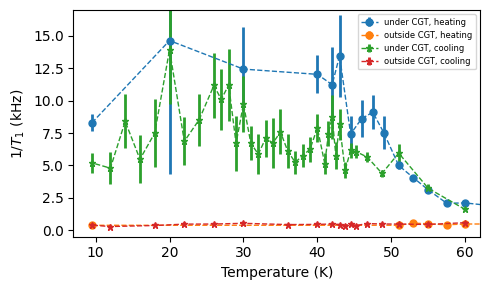

In [2799]:
fig,ax=plt.subplots(figsize=(5,3)); factor=1e3
ax.errorbar(temp_onFlake,1/T1_onFlake*factor,T1Err_onFlake/T1_onFlake**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, heating")
ax.errorbar(temp_offFlake,1/T1_offFlake*factor,T1Err_offFlake/T1_offFlake**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="outside CGT, heating")
ax.errorbar(temp_on_down,1/T1_on_down*factor,T1Err_on_down/T1_on_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="under CGT, cooling")
ax.errorbar(temp_off_down,1/T1_off_down*factor,T1Err_off_down/T1_off_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="outside CGT, cooling")



T1_offItp = np.interp(temp_onFlake, temp_offFlake, T1_offFlake)
T1Err_offItp = np.interp(temp_onFlake, temp_offFlake, T1Err_offFlake)
# ax.errorbar(temp_onFlake,(1/T1_onFlake-1/T1_offItp)*factor,
#             (T1Err_offItp/T1_offItp**2 + T1Err_onFlake/T1_onFlake**2)*factor,
#             marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="outside CGT, heating")
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$1/T_{1}$ (kHz)')
# ax.set_yscale('log')
ax.set_ylim((-0.5,17))
ax.set_xlim((7,62))
ax.legend(fontsize=6,loc='upper right')
plt.tight_layout()

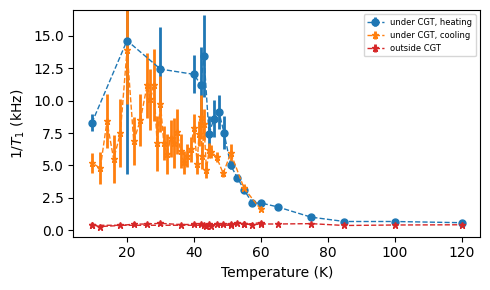

In [2800]:
fig,ax=plt.subplots(figsize=(5,3)); factor=1e3
ax.errorbar(temp_onFlake,1/T1_onFlake*factor,T1Err_onFlake/T1_onFlake**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, heating")
ax.errorbar(temp_on_down,1/T1_on_down*factor,T1Err_on_down/T1_on_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="under CGT, cooling")
ax.errorbar(temp_off_down,1/T1_off_down*factor,T1Err_off_down/T1_off_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="outside CGT")
ax.errorbar(temp_offFlake,1/T1_offFlake*factor,T1Err_offFlake/T1_offFlake**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label=None)



T1_offItp = np.interp(temp_onFlake, temp_offFlake, T1_offFlake)
T1Err_offItp = np.interp(temp_onFlake, temp_offFlake, T1Err_offFlake)
# ax.errorbar(temp_onFlake,(1/T1_onFlake-1/T1_offItp)*factor,
#             (T1Err_offItp/T1_offItp**2 + T1Err_onFlake/T1_onFlake**2)*factor,
#             marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="outside CGT, heating")
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$1/T_{1}$ (kHz)')
# ax.set_yscale('log')
ax.set_ylim((-0.5,17))
# ax.set_xlim((7,62))
ax.legend(fontsize=6,loc='upper right')
plt.tight_layout()

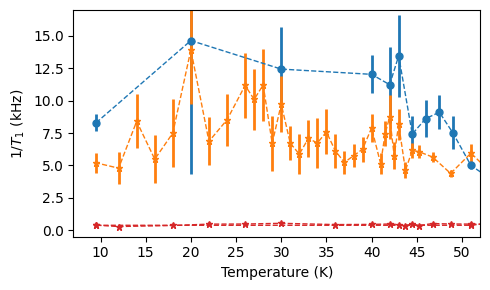

In [2801]:
fig,ax=plt.subplots(figsize=(5,3)); factor=1e3
ax.errorbar(temp_onFlake,1/T1_onFlake*factor,T1Err_onFlake/T1_onFlake**2*factor,
            marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C0',label="under CGT, heating")
ax.errorbar(temp_on_down,1/T1_on_down*factor,T1Err_on_down/T1_on_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C1',label="under CGT, cooling")
ax.errorbar(temp_off_down,1/T1_off_down*factor,T1Err_off_down/T1_off_down**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label="outside CGT")
ax.errorbar(temp_offFlake,1/T1_offFlake*factor,T1Err_offFlake/T1_offFlake**2*factor,
            marker='*', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C3',label=None)



T1_offItp = np.interp(temp_onFlake, temp_offFlake, T1_offFlake)
T1Err_offItp = np.interp(temp_onFlake, temp_offFlake, T1Err_offFlake)
# ax.errorbar(temp_onFlake,(1/T1_onFlake-1/T1_offItp)*factor,
#             (T1Err_offItp/T1_offItp**2 + T1Err_onFlake/T1_onFlake**2)*factor,
#             marker='o', linestyle='--', linewidth=1, markersize=5, elinewidth=2, color='C2',label="outside CGT, heating")
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$1/T_{1}$ (kHz)')
# ax.set_yscale('log')
ax.set_ylim((-0.5,17))
ax.set_xlim((7,52))
# ax.legend(fontsize=6,loc='upper right')
plt.tight_layout()

# XY8

## No std

(2, 11)


C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_84912\3631023453.py:96: RuntimeWarning: divide by zero encountered in divide
  return 1 / (2*x/8/NXY8)


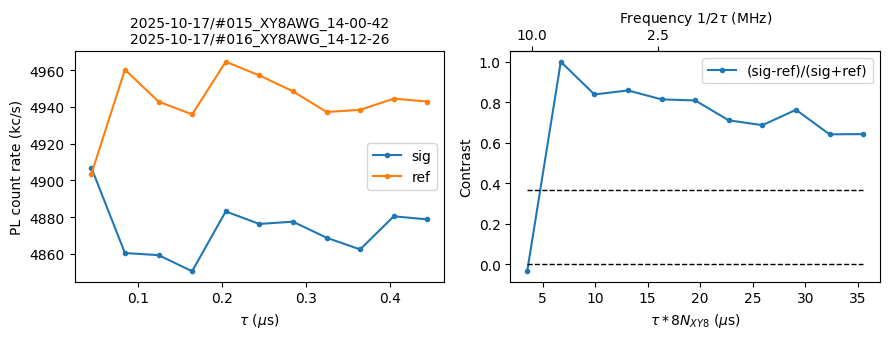

In [32]:
# Sweep tau
days = np.linspace(1,31,31); count=0; ifLog=0; ifFit=0; NXY8=10; pitime=24
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-10-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'XY8AWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch0 = (day==8 and idx<9)
                batch1 = day==8 and idx>=9 and idx<=43 # 9.5K off flake
                batch2 = (day==8 and idx>=44) or (day==9) # 9.5K on flake, N=4
                batch3 = (day==10 and idx<=436) # 9.5K on flake, N=4
                batch4 = (day==14) or (day==15 and idx<=48) #9.5K on flake, N=15
                batch5 = (day==15 and idx>=49) or (day==16) or (day==17 and idx<=13) # 9.5K off flake, N=10
                batch6 = (day==17 and idx>=15 and idx<=16) # 9.5K off flake, N=10
                batch7 = (day==20 and idx>=57) or (day==21) or (day==22) or (day==23 and idx<=21) # 30K on flake, N=4
                batch8 = (day==23 and idx>=22 and idx<=83) # 30K on flake, N=10
                batch9 = (day==23 and idx>=84) or (day==24) or (day==25) # 30K on flake, N=10
                batch10 = (day==26) or (day==27) or (day==28 and idx<=68) # 30K on flake, N=7
                if batch6:
                    datafile = mainFolder + dataFolder +'/XY8AWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile, ifStd=0)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = -(sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    err_y = np.std(dataArr[start:end], axis=0)
    
    err_y = err_y/ np.max(y)/np.sqrt(4e5)
    y = y/ np.max(y)
    
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = (xPlot+pitime)/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3.5))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    axs[1].plot(x*8*NXY8,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    # axs[1].errorbar(x*8*NXY8, y, err_y,
                    # fmt='o-', color='C0', markersize=3, capsize=5, capthick=0.5, ecolor='C0', elinewidth=1);
    axs[1].hlines(y=0, xmin=min(x*8*NXY8), xmax=max(x*8*NXY8), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=np.max(y)/np.e, xmin=min(x*8*NXY8), xmax=max(x*8*NXY8), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau*8N_{XY8}$ ($\mu$s)')
    # axs[1].set_xlim((0.00001, 1.03*np.max(x)))
    
    s = firstdatafile[31:62] + '\n' + datafile[31:62]
    # fig.suptitle(s,fontsize=10)
    axs[0].set_title(s,fontsize=10)

    if ifFit:
        guess = np.array((250, 0.5))
        lowerBounds=None
        upperBounds=None
        xfit, yfit, popt, perr = dr.fitStrDecayNorm(x, y, guess=guess, logx=1,lowerBounds=lowerBounds)
        
        s = '$T_{2,XY8}$=%.2f$\pm$%.2f $\mu$s' % (popt[0]*8*NXY8, perr[0]*8*NXY8)
        s1 = '$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])
        axs[1].plot(xfit*8*NXY8, yfit, '-', linewidth=2,color='C1',label=s+'\n'+s1)
        # print(popt[1])
       
    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    
    # Define forward (x → 1/x) and inverse (1/x → x) transforms
    def forward(x):
        return 1 / (2*x/8/NXY8)

    def inverse(x):
        return 1 / (2*x/8/NXY8)

    # Create secondary x-axis
    ax2 = axs[1].secondary_xaxis('top', functions=(forward, inverse))
    # Optional: limit ticks to a reasonable number
    ax2.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax2.set_xlabel(f'Frequency 1/2$\\tau$ (MHz)')

    # Manually set tick locations
    tau_ticks = np.array([0.02,0.05, 0.2, 0.5, 1.0, 2.0])*8*NXY8  # µs
    ax2.set_xticks(forward(tau_ticks))
    ax2.set_xticklabels([f"{forward(t):.1f}" for t in tau_ticks])
    
    ax2.invert_xaxis()

    

    plt.tight_layout()

(260, 31)


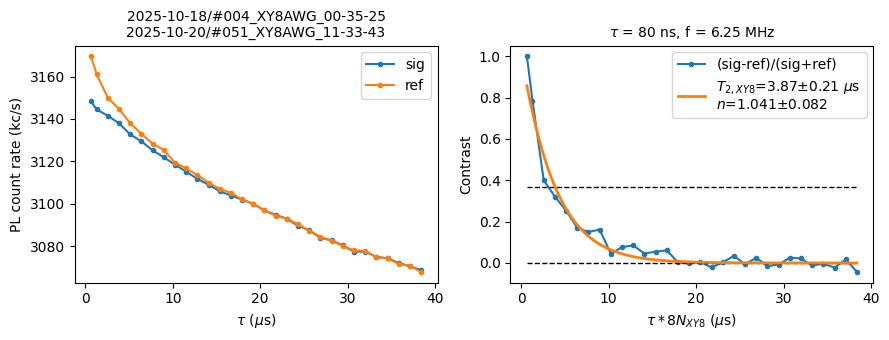

In [63]:
# Sweep N
days = np.linspace(1,31,31); count=0; ifLog=0; ifFit=1; tau=80
dataArr = []; sigArr = []; refArr = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-10-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'XY8AWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1b = (day==17 and idx>=20 and idx<=224)
                batch2b = (day>=18)
                if batch2b:
                    datafile = mainFolder + dataFolder +'/XY8AWGObject_sig_set.dat'
                    x_s, sig, ref = dr.readDataNoPlot(datafile)

                    sig = np.array(sig); ref = np.array(ref)
                    contrast = -(sig-ref)/(sig+ref)
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]

                    dataArr.append(contrast); sigArr.append(sig); refArr.append(ref)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); sigArr = np.array(sigArr); refArr = np.array(refArr)
    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None
    y = np.average(dataArr[start:end], axis=0)
    y = y/ np.max(y)
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = xPlot*8*tau/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3.5))
    axs[0].plot(x,ys, 'o-', markersize=3, label="sig")
    axs[0].plot(x,yr, 'o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    axs[1].plot(x,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    axs[1].hlines(y=0, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=np.max(y)/np.e, xmin=min(x), xmax=max(x), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau*8N_{XY8}$ ($\mu$s)')
    # axs[1].set_xlim((0.00001, 1.03*np.max(x)))
    
    s = firstdatafile[31:62] + '\n' + datafile[31:62]
    # fig.suptitle(s,fontsize=10)
    axs[0].set_title(s,fontsize=10)
    axs[1].set_title('$\\tau$ = %.0f ns, f = %.2f MHz' % (tau, 1/(2*tau/1e3)),fontsize=10)

    if ifFit:
        guess = np.array((250, 0.5))
        lowerBounds=None
        upperBounds=None
        xfit, yfit, popt, perr = dr.fitStrDecayNorm(x, y, guess=guess, logx=1,lowerBounds=lowerBounds)
        
        s = '$T_{2,XY8}$=%.2f$\pm$%.2f $\mu$s' % (popt[0], perr[0])
        s1 = '$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])
        axs[1].plot(xfit, yfit, '-', linewidth=2,color='C1',label=s+'\n'+s1)
        # print(popt[1])
       
    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    
    plt.tight_layout()

## With std

(275, 61)


C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_22216\930982586.py:112: RuntimeWarning: divide by zero encountered in divide
  return 1 / (2*x/8/NXY8)


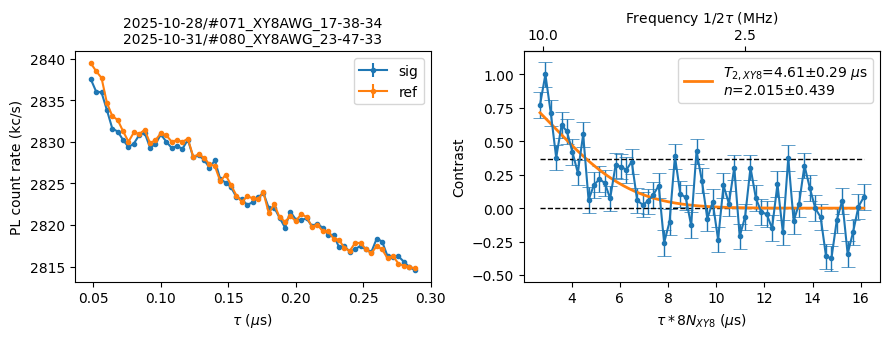

In [78]:
# Sweep tau
days = np.linspace(1,31,31); count=0; ifLog=0; ifFit=1; NXY8=7; pitime=28
dataArr = []; dataArrErr = []; sigArr = []; refArr = []; sigArrErr=[]; refArrErr=[]
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-10-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            if 'XY8AWG' in dataFolder:
                idx = int(dataFolder[1:4])
                batch1 = (day==28 and idx>=71) or (day==29) or (day==30) or (day==31)
                if batch1:
                    datafile = mainFolder + dataFolder +'/XY8AWGObject_sig_set.dat'
                    x_s, sig, ref, sig_std, ref_std = dr.readDataNoPlot(datafile, ifStd=1)

                    sig = np.array(sig); ref = np.array(ref)
                    sig_std = np.array(sig_std); ref_std = np.array(ref_std)
                    contrast = -(sig-ref)/(sig+ref)
                    err_contrast = np.sqrt(sig_std**2 + ref_std**2)*2*sig / (sig+ref)**2
                    # err_contrast = (sig*ref_std -ref*sig_std)*2 / (sig+ref)**2
                    xPlot = x_s; xPlot = np.array(xPlot)

                    sorted_indices = np.argsort(xPlot)
                    xPlot = xPlot[sorted_indices]
                    contrast = contrast[sorted_indices]
                    err_contrast = err_contrast[sorted_indices]
                    sig = sig[sorted_indices]
                    ref = ref[sorted_indices]
                    sig_std = sig_std[sorted_indices]
                    ref_std = ref_std[sorted_indices]

                    dataArr.append(contrast); dataArrErr.append(err_contrast)
                    sigArr.append(sig); refArr.append(ref)
                    sigArrErr.append(sig_std); refArrErr.append(ref_std)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass

if True:
    dataArr = np.array(dataArr); dataArrErr = np.array(dataArrErr)
    sigArr = np.array(sigArr); refArr = np.array(refArr)
    sigArrErr = np.array(sigArrErr); refArrErr = np.array(refArrErr)

    print(np.shape(dataArr))
    xPlot = np.array(xPlot); start=0; end=None

    weights = 1/sigArrErr[start:end]**2
    sig = np.sum(sigArr[start:end]*weights, axis=0)/np.sum(weights, axis=0)
    sig_err = np.sqrt(1/np.sum(weights, axis=0))/1e3
    weights = 1/refArrErr[start:end]**2
    ref = np.sum(refArr[start:end]*weights, axis=0)/np.sum(weights, axis=0)
    ref_err = np.sqrt(1/np.sum(weights, axis=0))/1e3

    weights = 1/dataArrErr[start:end]**2
    y = np.sum(dataArr[start:end]*weights, axis=0)/np.sum(weights, axis=0)
    err_y = np.sqrt(1/np.sum(weights, axis=0))
    err_y = err_y / np.max(y) /1e3
    y     = y     / np.max(y)

    

    # y = np.average(dataArr[start:end], axis=0)
    # err_y = np.std(dataArr[start:end], axis=0)
    # err_y = err_y/ np.max(y)/np.sqrt(4e5)
    # y = y/ np.max(y)
    
    ys = np.nanmean(sigArr[start:end], axis=0)
    yr = np.nanmean(refArr[start:end], axis=0)
    x = (xPlot+pitime)/1e3

    fig,axs=plt.subplots(1,2,figsize=(9, 3.5))
    axs[0].errorbar(x,sig, sig_err,fmt='o-', markersize=3, label="sig")
    axs[0].errorbar(x,ref, ref_err,fmt='o-', markersize=3, label="ref")
    axs[0].legend()
    axs[0].set_ylabel('PL count rate (kc/s)')
    axs[0].set_xlabel('$\\tau$ ($\mu$s)')

    # axs[1].plot(x*8*NXY8,y, 'o-',markersize=3,  label='(sig-ref)/(sig+ref)',)
    axs[1].errorbar(x*8*NXY8, y, err_y,
                    fmt='o-', color='C0', markersize=3, capsize=5, capthick=0.5, ecolor='C0', elinewidth=1);
    axs[1].hlines(y=0, xmin=min(x*8*NXY8), xmax=max(x*8*NXY8), linestyle='--', linewidth = 1,color='k')
    axs[1].hlines(y=np.max(y)/np.e, xmin=min(x*8*NXY8), xmax=max(x*8*NXY8), linestyle='--', linewidth = 1,color='k')
    axs[1].set_ylabel('Contrast')
    axs[1].set_xlabel('$\\tau*8N_{XY8}$ ($\mu$s)')
    # axs[1].set_xlim((0.00001, 1.03*np.max(x)))
    
    s = firstdatafile[31:62] + '\n' + datafile[31:62]
    # fig.suptitle(s,fontsize=10)
    axs[0].set_title(s,fontsize=10)

    if ifFit:
        guess = np.array((250, 0.5))
        lowerBounds=None
        upperBounds=None
        xfit, yfit, popt, perr = dr.fitStrDecayNorm(x, y, guess=guess, logx=1,lowerBounds=lowerBounds)
        
        s = '$T_{2,XY8}$=%.2f$\pm$%.2f $\mu$s' % (popt[0]*8*NXY8, perr[0]*8*NXY8)
        s1 = '$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])
        axs[1].plot(xfit*8*NXY8, yfit, '-', linewidth=2,color='C1',label=s+'\n'+s1)
        # print(popt[1])
       
    axs[1].legend()
    if ifLog:
        axs[0].set_xscale('log')
        axs[1].set_xscale('log')
    
    # Define forward (x → 1/x) and inverse (1/x → x) transforms
    def forward(x):
        return 1 / (2*x/8/NXY8)

    def inverse(x):
        return 1 / (2*x/8/NXY8)

    # Create secondary x-axis
    ax2 = axs[1].secondary_xaxis('top', functions=(forward, inverse))
    # Optional: limit ticks to a reasonable number
    ax2.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax2.set_xlabel(f'Frequency 1/2$\\tau$ (MHz)')

    # Manually set tick locations
    tau_ticks = np.array([0.02,0.05, 0.2, 0.5, 1.0, 2.0])*8*NXY8  # µs
    ax2.set_xticks(forward(tau_ticks))
    ax2.set_xticklabels([f"{forward(t):.1f}" for t in tau_ticks])
    
    ax2.invert_xaxis()

    

    plt.tight_layout()

# Confocal XY8

## Each temperature

In [6]:
dataArr = []; ifSingleGreenRead=1
month = 10; days = np.linspace(1,31,31); count=0; ifYCountDown=0; NXY8=10
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-'+str(int(month)).zfill(2)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalXY8'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                if True:
                    batch1 = (day>=10 and day<=14) # 9.5K FC South, msmt magnet North
                if batch1:  
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,tau,sig,ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
                    sig = np.array(sig); ref = np.array(ref); contrast = -(sig-ref)/(sig+ref)
                    x = np.array(x); y = np.array(y)
                    (ny,nx,ntau) = np.shape(sig)
                    dataArr.append(contrast)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
dataArr = np.array(dataArr); print(np.shape(dataArr))
dataArr = np.average(dataArr, axis=0)
convfactor = 2*0.028*1e6; conv_voltage=10

(72, 3, 3, 26)


3.8786344658506566
-------------------------
2.0455996271857715
-------------------------
2.180542288061923
-------------------------


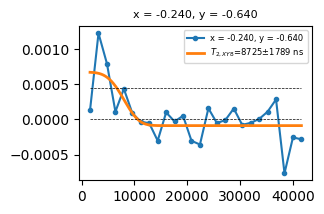

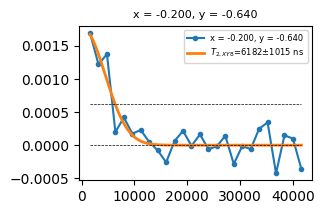

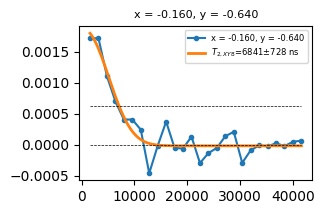

In [9]:
# Plot individual trace
j = 2; i = 2; idxArray = np.linspace(0,i,i+1-0); ifFit=1
for i in idxArray:
    i = int(i)
    fig, ax = plt.subplots(figsize=(3,2))
    label = 'x = %.3f, y = %.3f' % (x[j,i,0], y[j,i,0])
    xplot = tau[j,i]*8*NXY8; yplot = dataArr[j,i]
    ax.plot(xplot,yplot, 'o-',markersize=3,  label=label)
    # ax.set_ylim((-0.002,0.009))#1.1*np.max(yplot)))
    # ax.set_xscale('log')
    # ax.set_xlim((14,1.4*np.max(xplot)))
    if ifFit:
        guesses = [
            # np.array((0.01, 0.00, 60*8*NXY8, 1)),
            # np.array((0.008, 0.001, 100*8*NXY8, 1)),
            # np.array((0.008, 0.001, 150*8*NXY8, 1)),
            # np.array((0.008, 0.001, 200*8*NXY8, 1)),
            np.array((0.008, 0.001, 250*8*NXY8, 1)),
            np.array((0.006, 0.001, 1500*8*NXY8, 1)),
            np.array((0.006, 0.001, 2000*8*NXY8, 0.8)),
            np.array((0.008, 0.00, 50*8*NXY8, 1)),
            np.array((0.008, 0.00, 100*8*NXY8, 1)),
            np.array((0.008, 0.00, 150*8*NXY8, 1)),
            np.array((0.008, 0.00, 200*8*NXY8, 1)),
            np.array((0.008, 0.00, 250*8*NXY8, 1)),
            np.array((0.006, 0.00, 1500*8*NXY8, 1)),
            np.array((0.006, 0.00, 2000*8*NXY8, 0.8)),
            np.array((0.08, 0.00, 100*8*NXY8, 0.8)),
        ]
        lowerBounds=np.array((0, -1, 50*8*NXY8, 1))
        lowerBounds=np.array((0, -1, 50*8*NXY8, 0))
        lowerBounds=None
        # if np.max(xplot) > 5000:
        #     for guess in guesses:
        #         guess[2] = 7000  # override T2 guess if necessary

        for guess in guesses:
            try:
                # ax.plot(xplot, dr.strDecay(xplot,*guess), '-', linewidth=2,color='C2')
                xfit, yfit, popt, perr = dr.fitStrDecay(xplot, yplot, guess=guess, logx=1,lowerBounds=lowerBounds)
                s = '$T_{2,XY8}$=%.0f$\pm$%.0f ns' % (popt[2], perr[2])
                print(popt[3])
                ax.plot(xfit, yfit, '-', linewidth=2, color='C1', label=s)
                ax.hlines(y=0,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
                ax.hlines(y=np.max(yplot)/np.e,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
                break  # Stop if successful
            except Exception as e:
                continue  # Try next guess
        print('-------------------------')
    ax.legend(fontsize=6)
    ax.set_title(label,fontsize=8)

In [845]:
XY8Array = np.ones((ny,nx))*(0); XY8ErrArray = np.zeros((ny,nx)); nArray=np.zeros((ny,nx)); nErrArray=np.zeros((ny,nx))
for j in range(ny):
    for i in range(nx):
        try:
            xplot=tau[j,i]*8*NXY8; yplot=dataArr[j,i]
            guesses = [
                # np.array((0.01, 0.00, 60*8*NXY8, 1)),
                # np.array((0.008, 0.001, 100*8*NXY8, 1)),
                # np.array((0.008, 0.001, 150*8*NXY8, 1)),
                # np.array((0.008, 0.001, 200*8*NXY8, 1)),
                np.array((0.008, 0.001, 250*8*NXY8, 1)),
                np.array((0.006, 0.001, 1500*8*NXY8, 1)),
                np.array((0.006, 0.001, 2000*8*NXY8, 0.8)),
                np.array((0.008, 0.00, 50*8*NXY8, 1)),
                np.array((0.008, 0.00, 100*8*NXY8, 1)),
                np.array((0.008, 0.00, 150*8*NXY8, 1)),
                np.array((0.008, 0.00, 200*8*NXY8, 1)),
                np.array((0.008, 0.00, 250*8*NXY8, 1)),
                np.array((0.006, 0.00, 1500*8*NXY8, 1)),
                np.array((0.006, 0.00, 2000*8*NXY8, 0.8)),
                np.array((0.08, 0.00, 100*8*NXY8, 0.8)),
            ]
            lowerBounds=np.array((0, -1, 50*8*NXY8, 1))
            lowerBounds=np.array((0, -1, 50*8*NXY8, 0))
            lowerBounds=None
            # if np.max(xplot) > 5000:
            #     for guess in guesses:
            #         guess[2] = 7000  # override T2 guess if necessary

            for guess in guesses:
                try:
                    xfit, yfit, popt, perr = dr.fitStrDecay(xplot,yplot, guess=guess, lowerBounds=lowerBounds,logx=0)
                    XY8Array[j,i] = popt[2]; XY8ErrArray[j,i] = perr[2]
                    nArray[j,i] = popt[3]; nErrArray[j,i] = perr[3]
                    break  # Stop if successful
                except Exception as e:
                    continue  # Try next guess
        except:pass


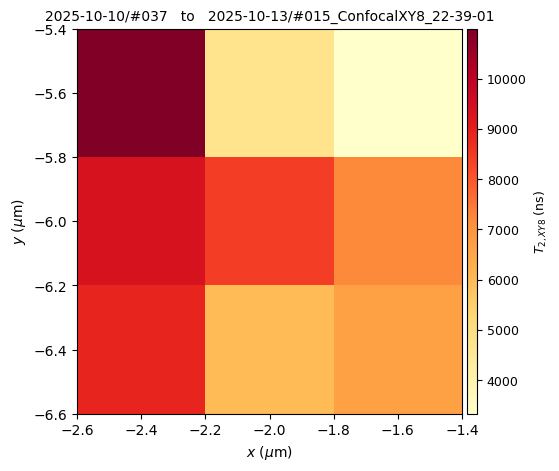

In [846]:
# 2D       
X = x[:,:,0]*conv_voltage; Y = y[:,:,0]*conv_voltage
fig, ax = plt.subplots(figsize=(5,5))

plot = ax.pcolormesh(X,Y, XY8Array, cmap='YlOrRd')
    
ax.set_aspect(1)
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
cbar = fig.colorbar(plot, cax = cax)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$T_{2,XY8}$ (ns)', fontsize=9)
a = 1000
# plot.set_clim(0,a)

ax.set_xlabel('$V_x$ (V)')
ax.set_ylabel('$V_y$ (V)')

ax.set_xlabel('$x$ ($\mu$m)')
ax.set_ylabel('$y$ ($\mu$m)')
sp = 0.04*conv_voltage
for j in range(ny):
    for i in range(nx):
        if XY8Array[j,i]==0:
            ax.add_patch(plt.Rectangle((X[0][i]-sp/2, Y[j][0]-sp/2), sp, sp, color='black'))

s = firstdatafile[31:46] + '   to   ' + datafile[31:67]
ax.set_title(s,fontsize=10)

plt.tight_layout;

In [847]:
# maskT2 = np.where(T2EErrArray<3)
# T2EErrArray[maskT2] = 1000000000
# maskT2 = np.where(T2EArray<10)
# T2EErrArray[maskT2] = 1000000000

meanT2XY8 = np.mean(XY8Array)
meanT2XY8Err = np.mean(XY8ErrArray)
print('Mean T2,XY8 = %.0f ns' % meanT2XY8)
print('Mean T2,XY8 err = %.0f ns' % meanT2XY8Err)

weights = 1/XY8ErrArray**2
meanT2XY8_weighted = np.sum(XY8Array*weights)/np.sum(weights)
meanT2XY8Err_weighted = np.sqrt(1/np.sum(weights))
print('Mean T2,XY8 weighted = %.0f ns' % meanT2XY8_weighted)
print('Mean T2,XY8 err weighted = %.0f ns' % meanT2XY8Err_weighted)

weights = 1/nErrArray**2
meann_weighted = np.sum(nArray*weights)/np.sum(weights)
meannErr_weighted = np.sqrt(1/np.sum(weights))
print('Mean n weighted = %.3f' % meann_weighted)
print('Mean n err weighted = %.3f' % meannErr_weighted)

Mean T2,XY8 = 7283 ns
Mean T2,XY8 err = 1444 ns
Mean T2,XY8 weighted = 6785 ns
Mean T2,XY8 err weighted = 321 ns
Mean n weighted = 1.499
Mean n err weighted = 0.291


## Revised fit

### Manually

In [3]:
dataArr = []; ifSingleGreenRead=1
month = 10; days = np.linspace(1,31,31); count=0; ifYCountDown=0; NXY8=10
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2025-'+str(int(month)).zfill(2)+'-' + str(int(day)).zfill(2) + '/'
    try:
        for dataFolder in os.listdir(mainFolder):
            type = 'ConfocalXY8'
            if type in dataFolder:
                idx = int(dataFolder[1:4])
                if True:
                    batch1 = (day>=10 and day<=14) # 9.5K FC South, msmt magnet North
                if batch1:  
                    # print(idx)
                    datafile = mainFolder + dataFolder + '/' + type + 'Object_y_set_'+type+'Object_x_set_'+type+'Object_sig_set.dat'
                    x,y,tau,sig,ref = dr.readDataConfocalODMR(datafile, ifYCountDown=ifYCountDown)
                    sig = np.array(sig); ref = np.array(ref); contrast = -(sig-ref)/(sig+ref)
                    x = np.array(x); y = np.array(y)
                    (ny,nx,ntau) = np.shape(sig)
                    dataArr.append(contrast)

                    if count==0: firstdatafile = datafile
                    count+=1
    except:pass
dataArr = np.array(dataArr); print(np.shape(dataArr))


(72, 3, 3, 26)


In [4]:
# Averaging data
if True: # standard
    dataArr = np.average(dataArr, axis=(0,1,2)); print(np.shape(dataArr))

    # Normalization
    # # dataArr = dataArr - np.average(dataArr[-2:])
    dataArr = dataArr/ np.max(dataArr) #dataArr[0]

    # dataArr = linear_map(dataArr,np.max(dataArr),np.min(dataArr),1,0)
xplot = tau[0,0]*8*NXY8/1e3; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr

(26,)


C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_16348\2742133809.py:10: RuntimeWarning: invalid value encountered in log
  xplot = tau[0,0]*8*NXY8/1e3; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr
C:\Users\lukin2dmaterials\AppData\Local\Temp\ipykernel_16348\2742133809.py:10: RuntimeWarning: divide by zero encountered in log
  xplot = tau[0,0]*8*NXY8/1e3; yplot = np.log(-np.log(dataArr)); yplot0 = dataArr


[7.29914369 2.24652038]
[0.41175402 0.40096853]
-------------------------


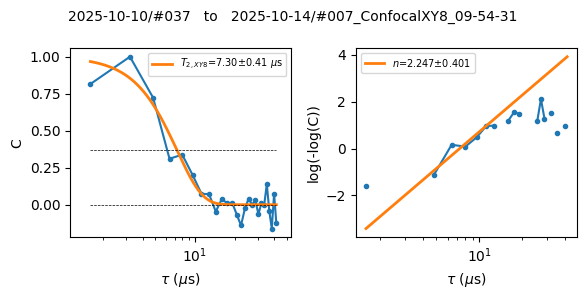

In [5]:
# Plot individual trace
ifFit=1; ifLog=0
fig, axs = plt.subplots(1,2, figsize=(6,3))

axs[0].plot(xplot,yplot0, 'o-',markersize=3,  label=None)
axs[1].plot(xplot,yplot, 'o-',markersize=3,  label=None)
axs[0].set_xscale('log'); axs[1].set_xscale('log')

if ifFit:
    guesses = [
        # np.array((60, 1)),
        # np.array((100, 1)),
        # np.array((160, 1)),
        # np.array((200, 1)),
        np.array((250*8*NXY8, 0.5)),
        np.array((1500*8*NXY8, 1)),
        np.array((2000*8*NXY8, 0.8)),
        np.array((4000*8*NXY8, 0.8)),
    ]
    lowerBounds=np.array((50*8*NXY8, 1))
    lowerBounds=np.array((50*8*NXY8, 0))
    lowerBounds=np.array((0,  0))
    lowerBounds=None

    upperBounds=None
    
    for guess in guesses:
        try:
            xfit, yfit, popt, perr = dr.fitStrDecayNorm(xplot, dataArr, guess=guess, logx=ifLog,
                                                    lowerBounds=lowerBounds, upperBounds=upperBounds)
            s = '$T_{2,XY8}$=%.2f$\pm$%.2f $\mu$s' % (popt[0], perr[0])
            s1 = '$n$=%.3f$\pm$%.3f' % (popt[1], perr[1])
            print(popt)
            print(perr)

            yfitplot = np.log(-np.log(yfit))
            yfitplot0 = yfit

            axs[0].plot(xfit, yfitplot0, '-', linewidth=2, color='C1', label=s)
            axs[0].hlines(y=0,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
            axs[0].hlines(y=np.max(yplot0)/np.e,xmin=min(xfit),xmax=max(xfit),linestyle='--',color='k',linewidth=0.5)
            
            axs[1].plot(xfit, yfitplot, '-', linewidth=2, color='C1', label=s1)
            break  # Stop if successful
        except Exception as e:
            continue  # Try next guess
    print('-------------------------')

axs[0].legend(fontsize=7); axs[1].legend(fontsize=7)

axs[0].set_xlim(0.7*np.min(xfit),1.3*np.max(xfit))
# axs[1].set_ylim((1.2*np.nanmin(yplot[np.isfinite(yplot)]), 1.5*np.nanmax(yplot[np.isfinite(yplot)])))
axs[0].set_xlabel('$\\tau$ ($\mu$s)')
axs[0].set_ylabel('C')
axs[1].set_xlabel('$\\tau$ ($\mu$s)')
axs[1].set_ylabel('log(-log(C))')

s = firstdatafile[31:46] + '   to   ' + datafile[31:67]
fig.suptitle(s,fontsize=10)

plt.tight_layout()

# Sat curve

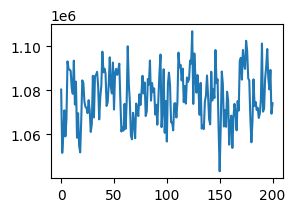

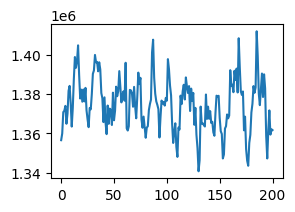

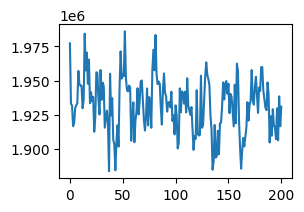

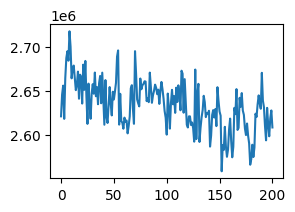

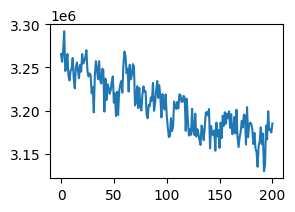

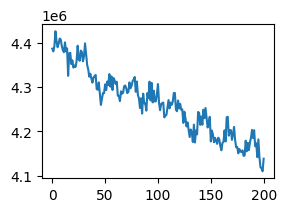

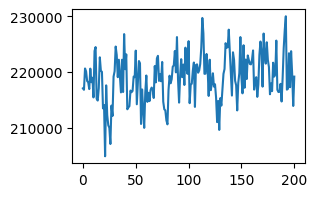

In [324]:
# Saturation rate
days = np.linspace(1,16,16)
dataArr = []; dataArrDark = []
for day in days:
    mainFolder = 'C:/Users/lukin2dmaterials/data/2024-05-' + str(int(day)).zfill(2) + '/'
    for dataFolder in os.listdir(mainFolder):
        # print(dataFolder)
        if 'counter' in dataFolder:
            idx = int(dataFolder[1:4])
            if (day==16 and idx >= 42 and idx <= 48):
                datafile = mainFolder + dataFolder +'/time_s_set.dat'
                x_s, sig = dr.readDataNoRef(datafile)
                sig = np.array(sig[0:])
                n = len(x_s)
                # print("n = " + str(n) + "; Avg count rate = " + str(np.round(np.average(sig))))
                fig,ax = plt.subplots(figsize=(3,2))
                ax.plot(x_s,sig)
                if idx <= 1060: dataArr.append(np.round(np.average(sig)))
                else: dataArrDark.append(np.round(np.average(sig)))

[-1.34756742e+05  2.88091291e+09  1.60281900e+07 -1.13348058e+05
  2.94178268e+09  1.10266240e+07  1.12214583e+00]


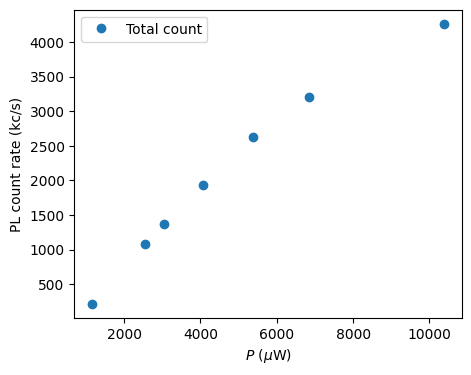

In [321]:
fig, ax = plt.subplots(figsize=(5,4))

# x = np.array((3000,4080,5250,6650,7800, 8750,10400))
# x = np.array((2340,1520,1270,805,243,0,2850, 3000,4080,5250,6650,7800, 8750,10400))
x = np.array((540,820,1190,1860,3160,4950,5600,7200,10650,0))
x = np.array((3070,2770,2200,1900,1250,800,670,500,310,190,70,0.02,1670,4130,5010,5730,6360,7070,10600))
x = np.array((3040,2470,2000,1610,1330,1140,740,400,160,0,3460,3960,4570,5430,5700,6600,6900,7670,8430,
              9080,970,10600))
x = np.array((3130,2720,2060,1340,82,330,720,10700,9820,9000,8370,7570,6750,6000,5400,4860,4040))
x = np.array((1520, 1150, 910, 720, 490, 310, 185, 55, 5250, 2020, 2520, 3000, 3630))*2
x = np.array((383, 1190, 750, 2400, 3150, 4960, 7090, 10450))
x = np.array((4930,3920,2910,2230,1600,730,140,5570,6910,10450))
x = np.array((2550,3050,4070,5390,6840,10390,1160))
y = np.array(dataArr)

# xd = np.array((2670,1070,480,0))
# yd = np.array(dataArrDark)

x = np.sort(x); y = np.sort(y/1000);# xd = np.sort(xd); yd = np.sort(yd/1000)
# popt, pcov = curve_fit(dr.linear, xd, yd)
# perr = np.sqrt(np.diag(pcov))
# xdfit = np.linspace(xd, xd[-1], 1001)
# ydfit = dr.linear(xdfit, *popt)

# yfit_few = dr.linear(x,*popt)
# y_subtr = y-yfit_few

# xfit, yfit, popt, perr = dr.fitSaturation(x, y_subtr, guess=None)

plot1 = ax.plot(x,y,'o',color='C0', label="Total count")
# plot2 = ax.plot(xd,yd, 'o', color='C1', label="Dark count")
# plot3 = ax.plot(xdfit, ydfit,color='C1')
# plot4 = ax.plot(x,y_subtr, 'o', color='C2', label="BG subtracted count")
# plot5 = ax.plot(xfit, yfit, color='C2')
ax.set_xlabel(r"$P$ ($\mu$W)")
ax.set_ylabel(r"PL count rate (kc/s)")
# ax.set_title("$I_{sat}$ = %.1f kc/s, $P_{sat}$ = %.3f mW" % (popt[0], popt[1]/1e3))
ax.legend()
# ax.set_yscale('log')
# ax.set_xscale('log')
print(popt)